**Libraries**

In [1]:
from singleCAM_IROS._pipeline_support import _handle_dirpaths

from pathlib import Path

import numpy as np
from numpy.typing import NDArray
import pandas as pd

from bloodmoon.io import simulation_files
from bloodmoon.mask import CodedMaskCamera
from bloodmoon.mask import codedmask, count
from bloodmoon.mask import variance, snratio

import darksun as ds
from darksun.types import Tag
from darksun.data import Log, DataLoader, CatalogueLoader
from darksun.benchmarking import dict2df
from darksun.utils import savefile_to

ds.show.set_figures_darkbkg()

**Analysis Methods**

In [2]:
def extract_catalogue_angular_coords(
    log: Log,
    catalogue: CatalogueLoader,
    sdl: DataLoader,
    camera: CodedMaskCamera,
) -> pd.DataFrame:
    """
    Extracts the catalogue sources angular coords.
    """
    angles_x, angles_y = [], []
    for sourceID in log.log['ID']:
        anglex, angley = (
            ds.source_angular_coords(sourceID, catalogue, sdl, camera)
            if sourceID in catalogue.DLdata['ID']
            else (np.nan, np.nan)
        )
        angles_x.append(anglex)
        angles_y.append(angley)
        
    df = pd.DataFrame(
        {'ID': log.log['ID'], 'angle_x': angles_x, 'angle_y': angles_y}
    )
    return df


def get_angularcoords_residues(
    log: Log,
    catalogue: CatalogueLoader,
    sdl: DataLoader,
    camera: CodedMaskCamera,
) -> tuple[NDArray, NDArray]:
    """
    Computes the angular coords residues between the IROS
    sources and the catalogue sources in [arcmin].
    """
    angular_coords = extract_catalogue_angular_coords(log, catalogue, sdl, camera)
    angles_x, angles_y = map(
        np.array, (angular_coords['angle_x'], angular_coords['angle_y']),
    )
    res_x, res_y = (
        60 * np.abs(np.array(log.log['angle_x']) - angles_x),
        60 * np.abs(np.array(log.log['angle_y']) - angles_y),
    )
    return res_x, res_y


def extract_catalogue_fluences(
    log: Log,
    catalogue: CatalogueLoader,
    sdl: DataLoader,
    camera: CodedMaskCamera,
    verbose: bool = True,
) -> pd.DataFrame:
    """
    Extracts the catalogue sources fluences.
    """
    fluences = []
    for sourceID in log.log['ID']:
        fluence = (
            ds.source_fluence(sourceID, catalogue, sdl, camera, verbose)
            if sourceID in catalogue.DLdata['ID']
            else np.nan
        )
        fluences.append(fluence)
        
    df = pd.DataFrame(
        {'ID': log.log['ID'], 'fluence': fluences}
    )
    return df


def get_fluence_residues(
    log: Log,
    catalogue: CatalogueLoader,
    sdl: DataLoader,
    camera: CodedMaskCamera,
    verbose: bool = True,
) -> NDArray:
    """
    Computes the percentage fluence residues between the IROS
    and the catalogue sources.
    """
    df = extract_catalogue_fluences(log, catalogue, sdl, camera, verbose)
    fluences = np.array(df['fluence'])
    res = np.array(log.log['fluence']) - fluences
    return res * 100 / fluences


def reconstruction_data(
    log: Log,
    catalogue: CatalogueLoader,
    sdl: DataLoader,
    camera: CodedMaskCamera,
    save_to: str | Path | None = None,
    verbose: bool = False,
) -> pd.DataFrame:
    """
    Generates a Dataframe with output data from IROS.
    """
    ds.pixels_angular_resolution(camera)
    theta_res_x, theta_res_y = get_angularcoords_residues(
        log, catalogue, sdl, camera,
    )
    fluence_res = get_fluence_residues(
        log, catalogue, sdl, camera, verbose,
    )
    dmap = {
        log.name: {
            'ID': log.log['ID'],
            'Brightest': log.log['id_brightest'],
            'SNR': log.log['snr'],
            'DthetaX [arcmin]': theta_res_x,
            'DthetaY [arcmin]': theta_res_y,
            'Dfluence [%]': fluence_res,
        }
    }
    df = dict2df(dmap)

    if save_to is not None:
        df.to_csv(path_or_buf=save_to, index=False)

    return df

**Mask and Data Specifics**

In [3]:
MASK_FITS: str = "wfm_mask_NTHT_20250725.fits"

#SKYFIELD: str = "GalacticCentre"
SKYFIELD: str = "IROSDummy"
#DATA_FITS: str = "galctr_rxte-sax_mask_050_1040x17_2-50keV_1ks"
#DATA_FITS: str = "galctr_rxte-sax_mask_050_1040x17_fmin0.0945_2-50keV_1ks"
DATA_FITS: str = "iros_benchmark_2-50keV_mask_050_1040x17_1ks"

ANALYSIS_ID: str = "singleCAM_iros_upx2y1_benchmark_fitwsigmaInv"

ID_CAMERA_A: str = "cam1a"
ID_CAMERA_B: str = "cam1b"
DATASET: str = "reconstructed"

E_min, E_max = 2.0, 10.0  # [keV]

UPS_X: int = 2
UPS_Y: int = 1

VIGNETTING: bool = True
PSFY: bool = True

**Notebook's General Variables**

In [4]:
# save plot and images
base_path: str = "/mnt/dbb8f47e-da06-47bf-8ef5-038092af70f7/Edos_Magnificent_Manor/PhD_AASS/Coding/IROS_Data/Outputs/OutIROSDummy/iros_benchmark_2-50keV_mask_050_1040x17_1ks"
#base_path: str = "/mnt/d/PhD_AASS/Coding/Images_fits"

#SAVE_TO: str | Path = '/home/edoardo/Desktop/detector_smoothing/smoothing'
SAVE_TO: str | Path = f'{base_path}/IROS_benchmark_results_upx2y1_2-10keV/{DATASET}/sources_profiles_{ID_CAMERA_B.upper()}'
SAVE_THINGS: bool = False

SOURCES_PROFILING: bool = True

ANALYSIS_CAM1A: bool = True
ANALYSIS_CAM1B: bool = False

**Load Mask and Data**

In [5]:
# load filepaths
mask_path, simul_data, save_path = _handle_dirpaths(
    mask=MASK_FITS,
    skyfield=SKYFIELD,
    simul=DATA_FITS,
    run_name=ANALYSIS_ID,
)

wfm: CodedMaskCamera = codedmask(mask_path, UPS_X, UPS_Y)

filepaths: dict[str, dict[str, Path]] = simulation_files(simul_data)

## USING BULK MASK with 1.5 mm cover ##


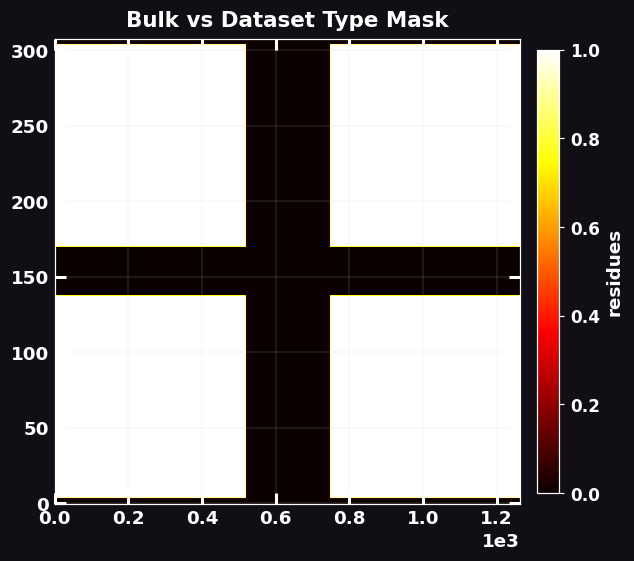

In [6]:
ds.image_plot(
    ds.map4image(
        img=wfm.bulk,
        title='Bulk vs Dataset Type Mask',
        cbarlabel='residues',
        img_kwargs={
            'aspect': wfm.shape_detector[1] / wfm.shape_detector[0],
            'cmap': 'hot',
        },
    )
)

In [7]:
# data from camera A
sdlA = ds.get_data(filepaths[ID_CAMERA_A][DATASET], E_min=E_min, E_max=E_max)
catalogueA = ds.get_catalogue(filepaths[ID_CAMERA_A]['sources'])
true_sky_camA, _ = ds.load_sky(save_path + f"sky_SIMUL_CAM1A_TEST_{ANALYSIS_ID}.fits")
res_sky_camA, _ = ds.load_sky(save_path + f"skyRES_IROS_CAM1A_TEST_{ANALYSIS_ID}.fits")

# Loading data...
# Loading completed!
# Loading data...
# Loading completed!


In [8]:
# data from camera B
sdlB = ds.get_data(filepaths[ID_CAMERA_B][DATASET], E_min=E_min, E_max=E_max)
catalogueB = ds.get_catalogue(filepaths[ID_CAMERA_B]['sources'])
true_sky_camB, _ = ds.load_sky(save_path + f"sky_SIMUL_CAM1B_TEST_{ANALYSIS_ID}.fits")
res_sky_camB, _ = ds.load_sky(save_path + f"skyRES_IROS_CAM1B_TEST_{ANALYSIS_ID}.fits")

# Loading data...
# Loading completed!
# Loading data...
# Loading completed!


In [9]:
log_camA, log_camB = ds.load_database(save_path + f"IROS_sources_database_TEST_{ANALYSIS_ID}.fits")

# Loading data...
# Loading completed!


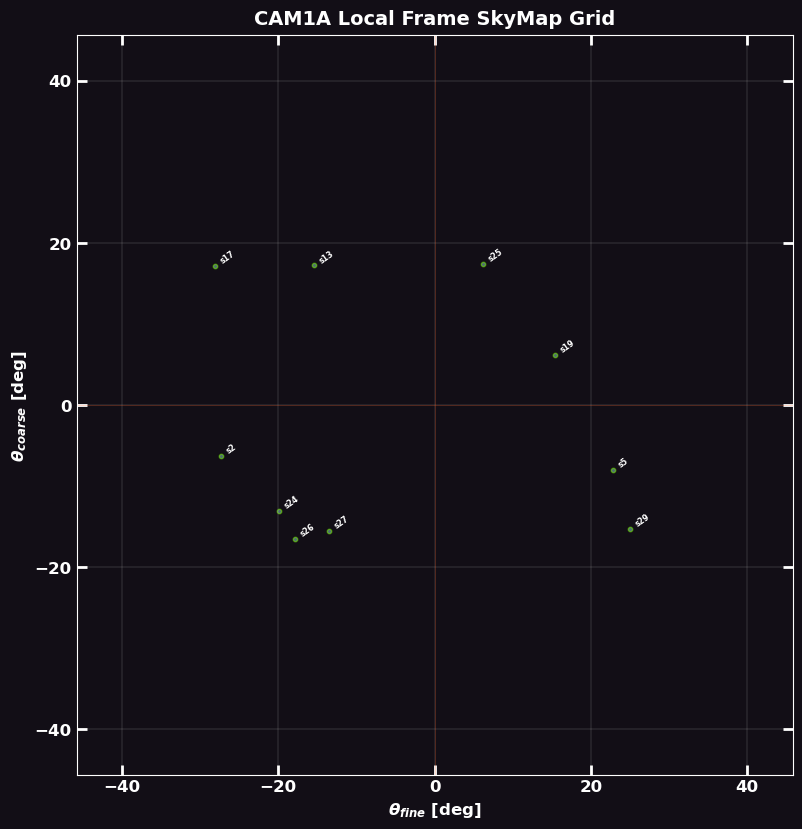


Pixel angular resolution at upscaling (x, y): (2, 1)
  - fine direction: 2.1163 arcmin
  - coarse direction: 8.4653 arcmin



CAM1A                                                                     
     ID Brightest         SNR DthetaX [arcmin] DthetaY [arcmin] Dfluence [%]
0   s17       s17  619.798852         0.299168         0.183764    15.866545
1   s29       s29  113.368380         0.212423         6.331541    15.579800
2   s25       s25   76.679619         0.929750         6.635860    -2.255478
3    s2        s2   84.930685         0.315144         4.187418    13.415407
4   s24       s24   67.476530         0.299192         4.490351    10.280821
5   s13       s13   64.270527         0.388917         5.246423    19.974972
6   s19       s19   58.697356         0.325455         0.544936    22.490557
7   s27       s27   55.661966         0.274116         0.305515    20.963958
8   s26       s26   56.616526         0.317650         1.386069     7.710376
9    s5        s5   61.739985         0.386810         0.656128     9.282786

In [10]:
# sources data + angular coords residues plot
ds.skyfield_map(
    log=log_camA,
    camera=wfm,
    save_to=(
        savefile_to(SAVE_TO, f'reconstructed_skymap_{ID_CAMERA_A.upper()}_{ANALYSIS_ID}')
        if SAVE_THINGS else None
    ),
)
reconstruction_data(
    log=log_camA,
    catalogue=catalogueA,
    sdl=sdlA,
    camera=wfm,
    save_to=(
        savefile_to(SAVE_TO, f'reconstruction_data_{ID_CAMERA_A.upper()}_{ANALYSIS_ID}', 'csv')
        if SAVE_THINGS else None
    ),
)

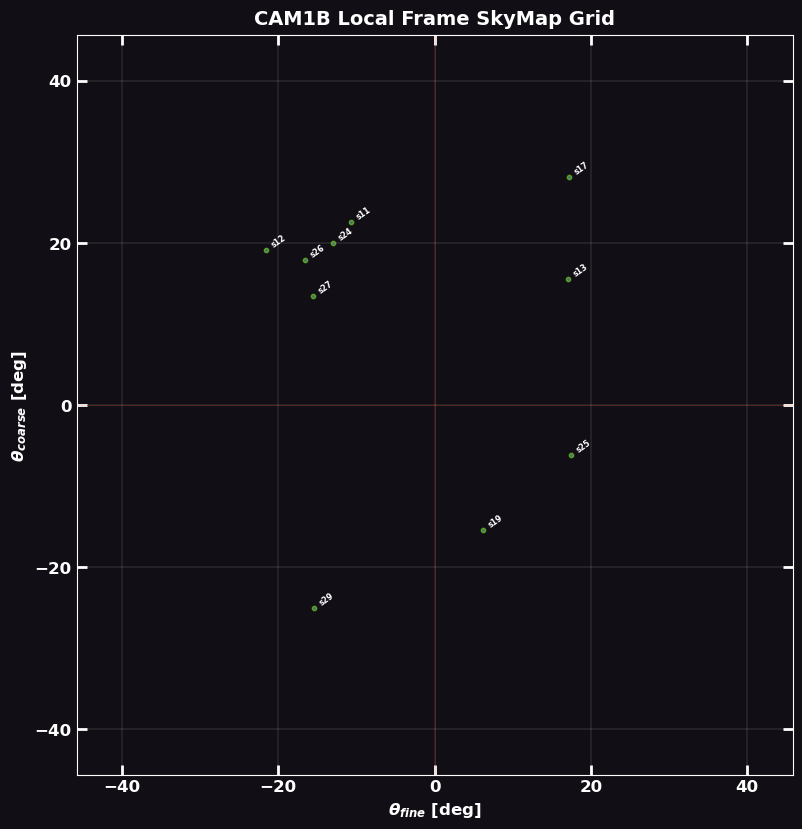


Pixel angular resolution at upscaling (x, y): (2, 1)
  - fine direction: 2.1163 arcmin
  - coarse direction: 8.4653 arcmin



CAM1B                                                                     
     ID Brightest         SNR DthetaX [arcmin] DthetaY [arcmin] Dfluence [%]
0   s17       s17  660.430972         0.227189         1.716451    18.666307
1   s29       s29  150.952518         0.289806         0.553319    16.906554
2   s25       s25   97.685500         0.335593         0.270563    10.258730
3   s19       s19   69.147879         0.828631         2.960567     7.820713
4   s11       s11   69.382535         0.179787         0.002602    20.370712
5   s26       s26   62.404167         0.070269         0.941351    10.487359
6   s24       s24   59.148198         0.218924         1.454451    16.674275
7   s13       s13   54.882234         0.272409         1.099623    21.636210
8   s27       s27   45.719598         0.202914         5.373956    21.147425
9   s12       s12   51.968711         0.358661         0.733782    18.806425

In [11]:
# sources data + angular coords residues plot
ds.skyfield_map(
    log=log_camB,
    camera=wfm,
    save_to=(
        savefile_to(SAVE_TO, f'reconstructed_skymap_{ID_CAMERA_B.upper()}_{ANALYSIS_ID}')
        if SAVE_THINGS else None
    ),
)
reconstruction_data(
    log=log_camB,
    catalogue=catalogueB,
    sdl=sdlB,
    camera=wfm,
    save_to=(
        savefile_to(SAVE_TO, f'reconstruction_data_{ID_CAMERA_B.upper()}_{ANALYSIS_ID}', 'csv')
        if SAVE_THINGS else None
    ),
)

In [12]:
assert SOURCES_PROFILING

**Analysis for LEM-X Camera A**

In [13]:
assert ANALYSIS_CAM1A

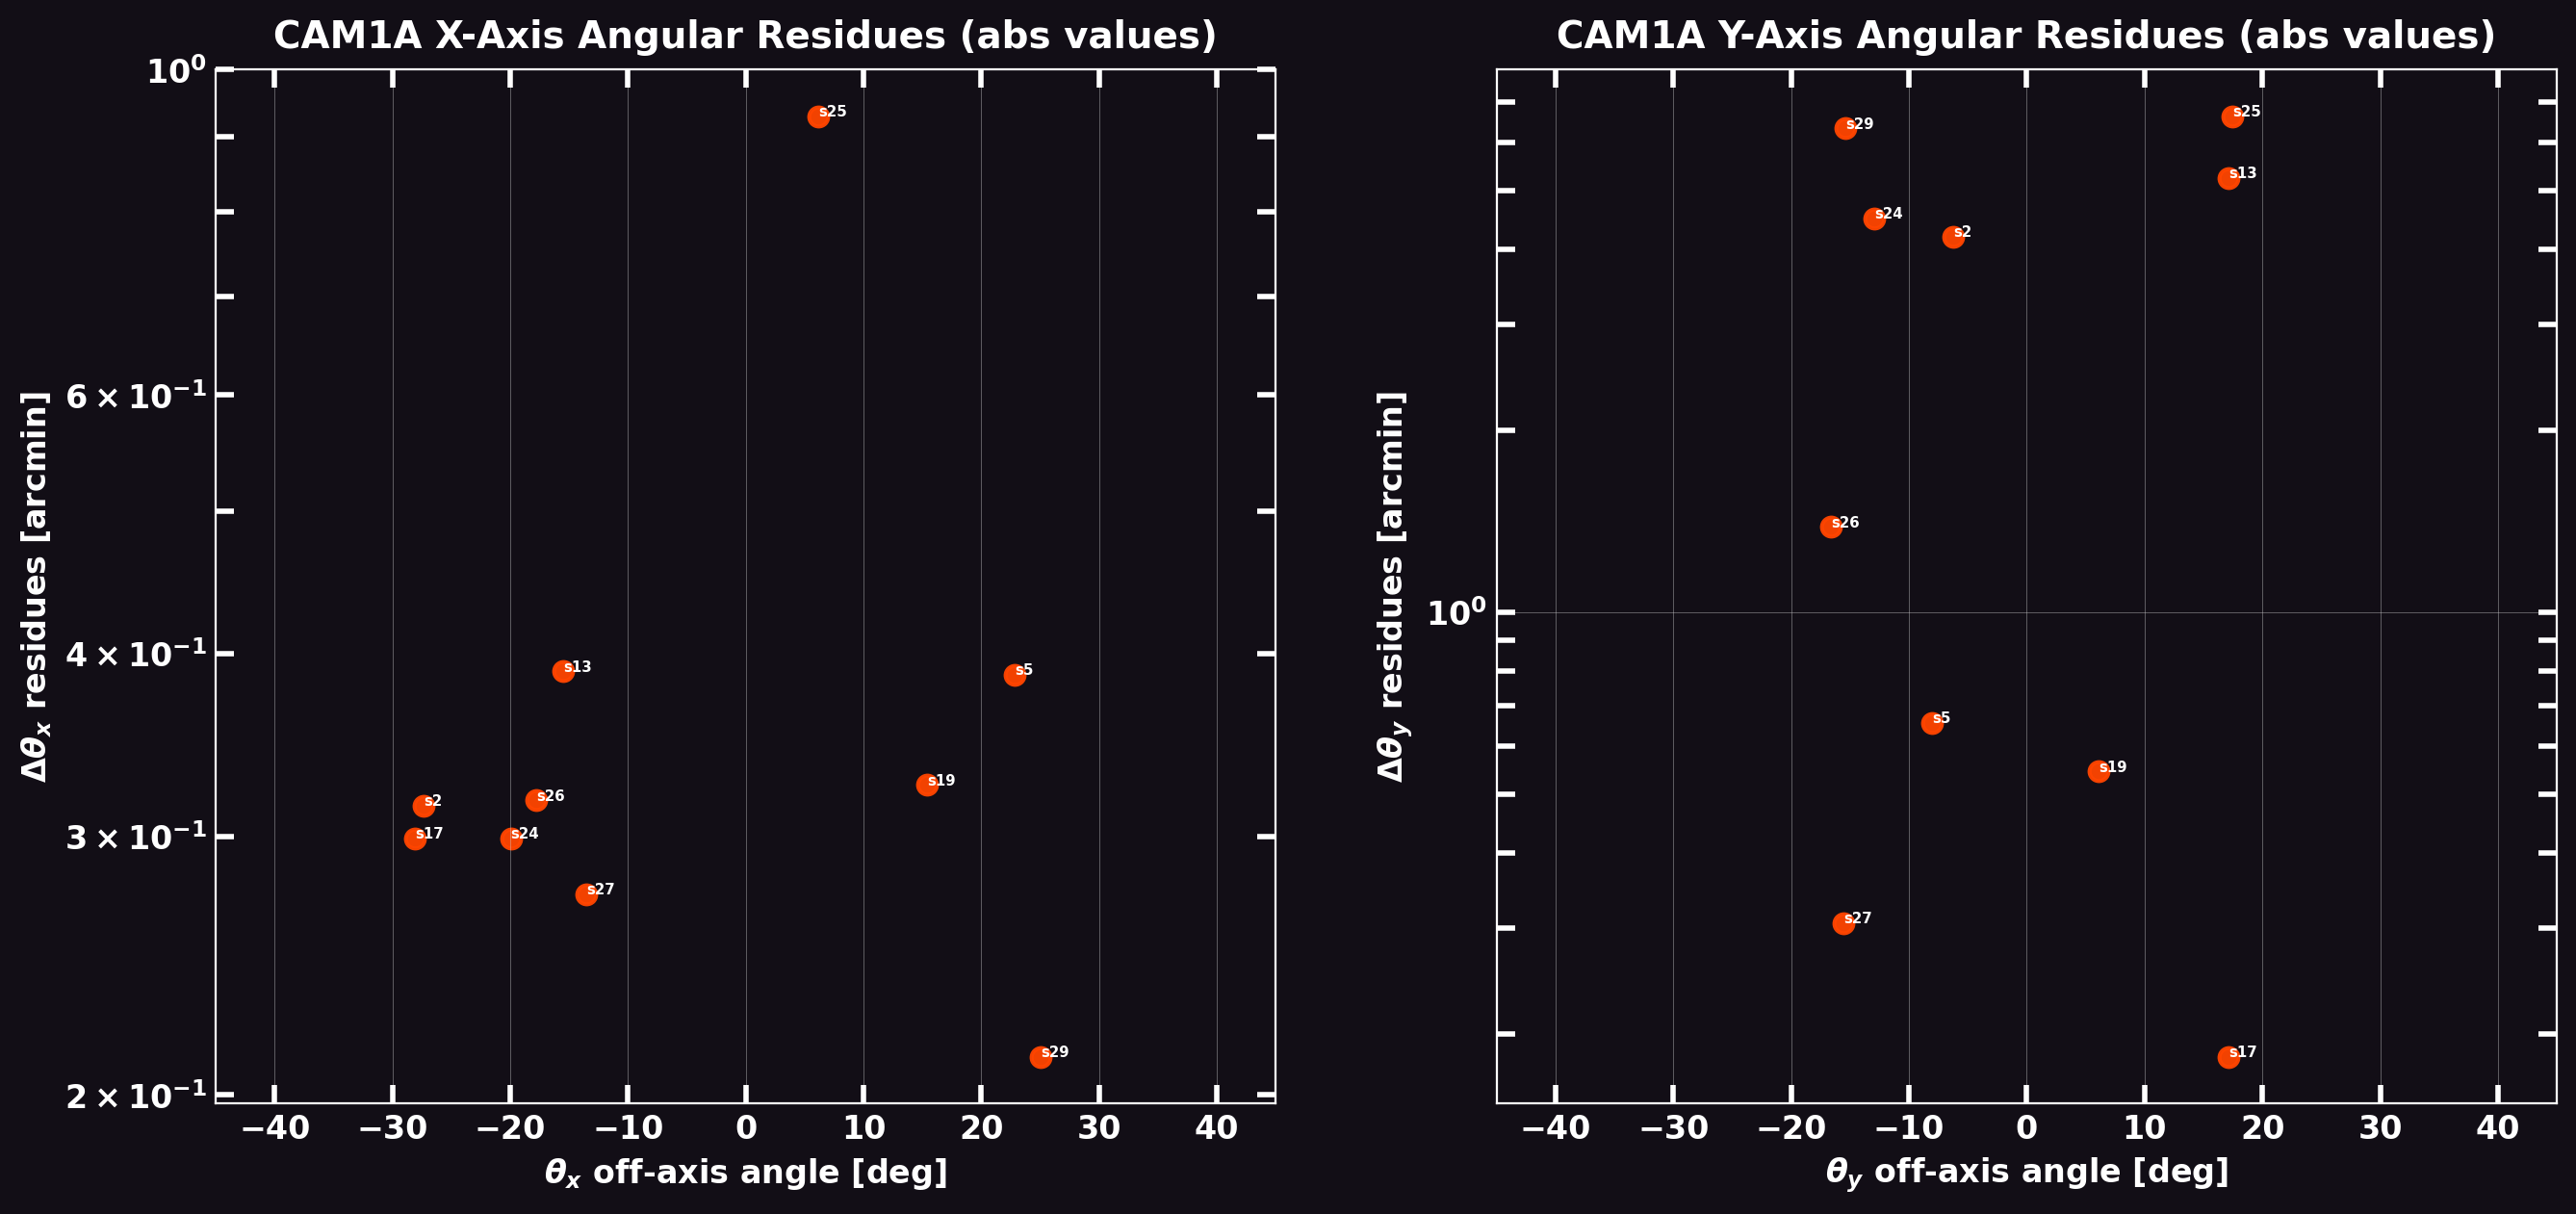

In [14]:
angular_coords = extract_catalogue_angular_coords(log_camA, catalogueA, sdlA, wfm)
cat_theta_x, cat_theta_y = map(
    np.array, (angular_coords['angle_x'], angular_coords['angle_y']),
)

theta_res_x, theta_res_y = get_angularcoords_residues(
    log=log_camA,
    catalogue=catalogueA,
    sdl=sdlA,
    camera=wfm,
)

tags_x = tuple(
    Tag(name, res, theta) for name, res, theta in zip(
        log_camA.log['ID'], theta_res_x, cat_theta_x,
    )
)
tags_y = tuple(
    Tag(name, res, theta) for name, res, theta in zip(
        log_camA.log['ID'], theta_res_y, cat_theta_y,
    )
)
dmapx = ds.map4plot(
    arrs=theta_res_x,
    title=f'{log_camA.name} X-Axis Angular Residues (abs values)',
    xlabel='$\\theta_{{x}}$ off-axis angle [deg]',
    ylabel='$\\Delta\\theta_{{x}}$ residues [arcmin]',
    x=cat_theta_x,
    style='scatter',
    color='OrangeRed',
    xlim=(-45, 45),
    yscale='log',
    tags=tags_x,
)
dmapy = ds.map4plot(
    arrs=theta_res_y,
    title=f'{log_camA.name} Y-Axis Angular Residues (abs values)',
    xlabel='$\\theta_{{y}}$ off-axis angle [deg]',
    ylabel='$\\Delta\\theta_{{y}}$ residues [arcmin]',
    x=cat_theta_y,
    style='scatter',
    color='OrangeRed',
    xlim=(-45, 45),
    yscale='log',
    tags=tags_y,
)

ds.plot(
    (dmapx, dmapy),
    ncols=2,
    save_to=(
        savefile_to(SAVE_TO, f'angularRes_{ID_CAMERA_A.upper()}')
        if SAVE_THINGS else None
    ),
)

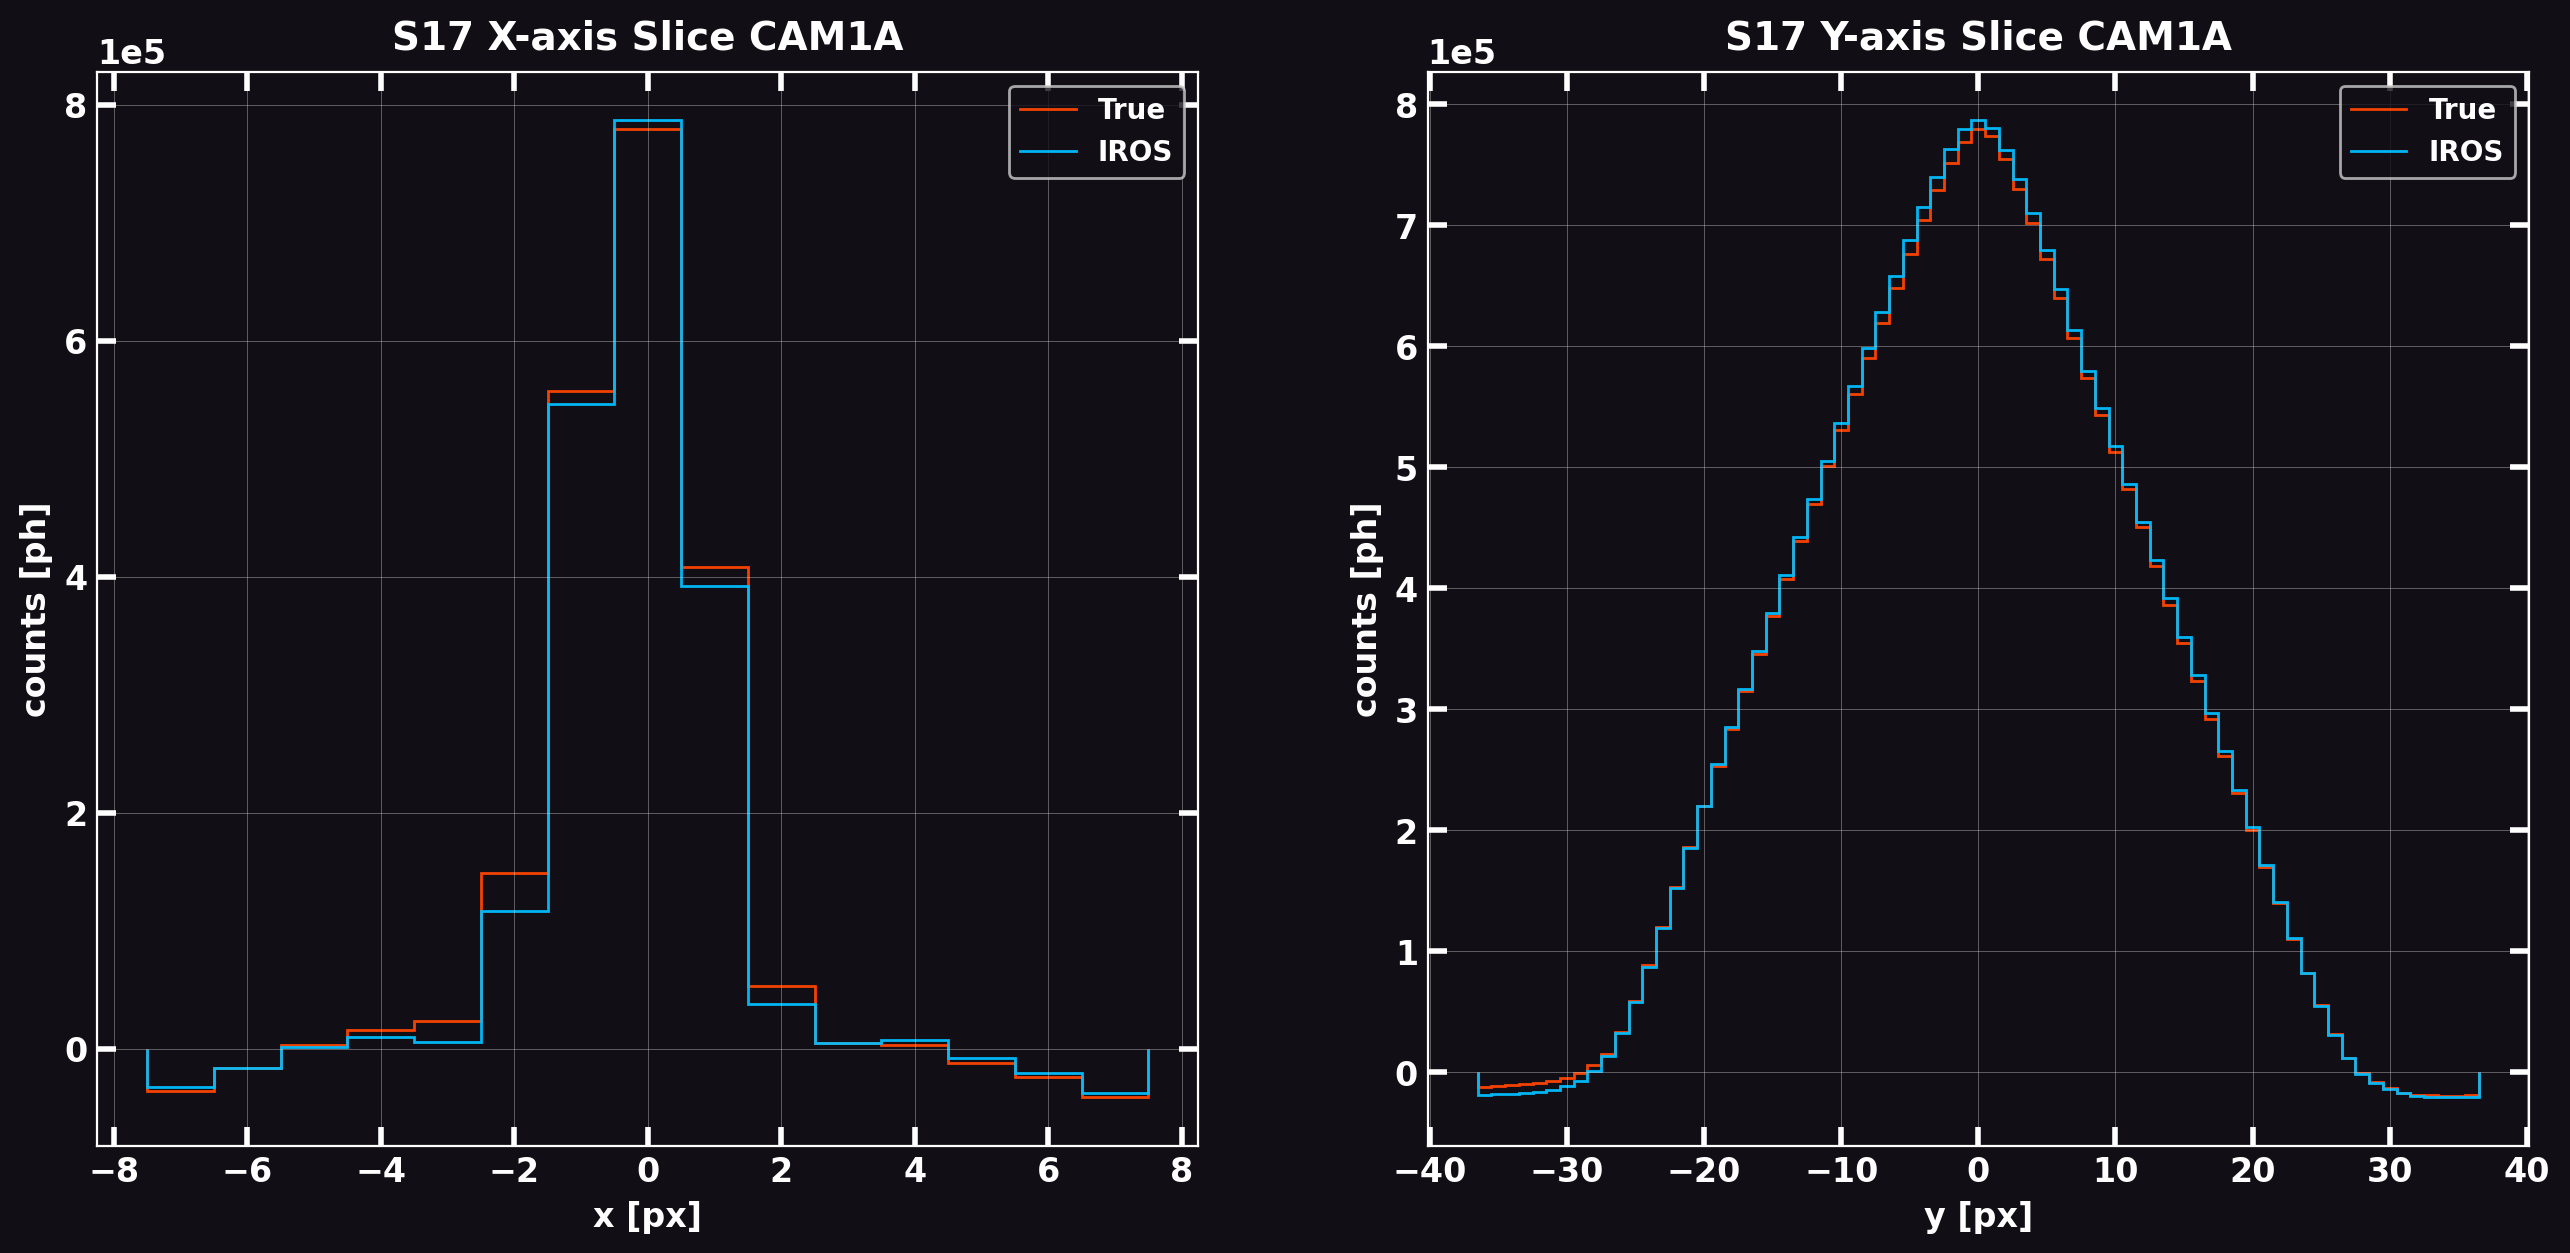

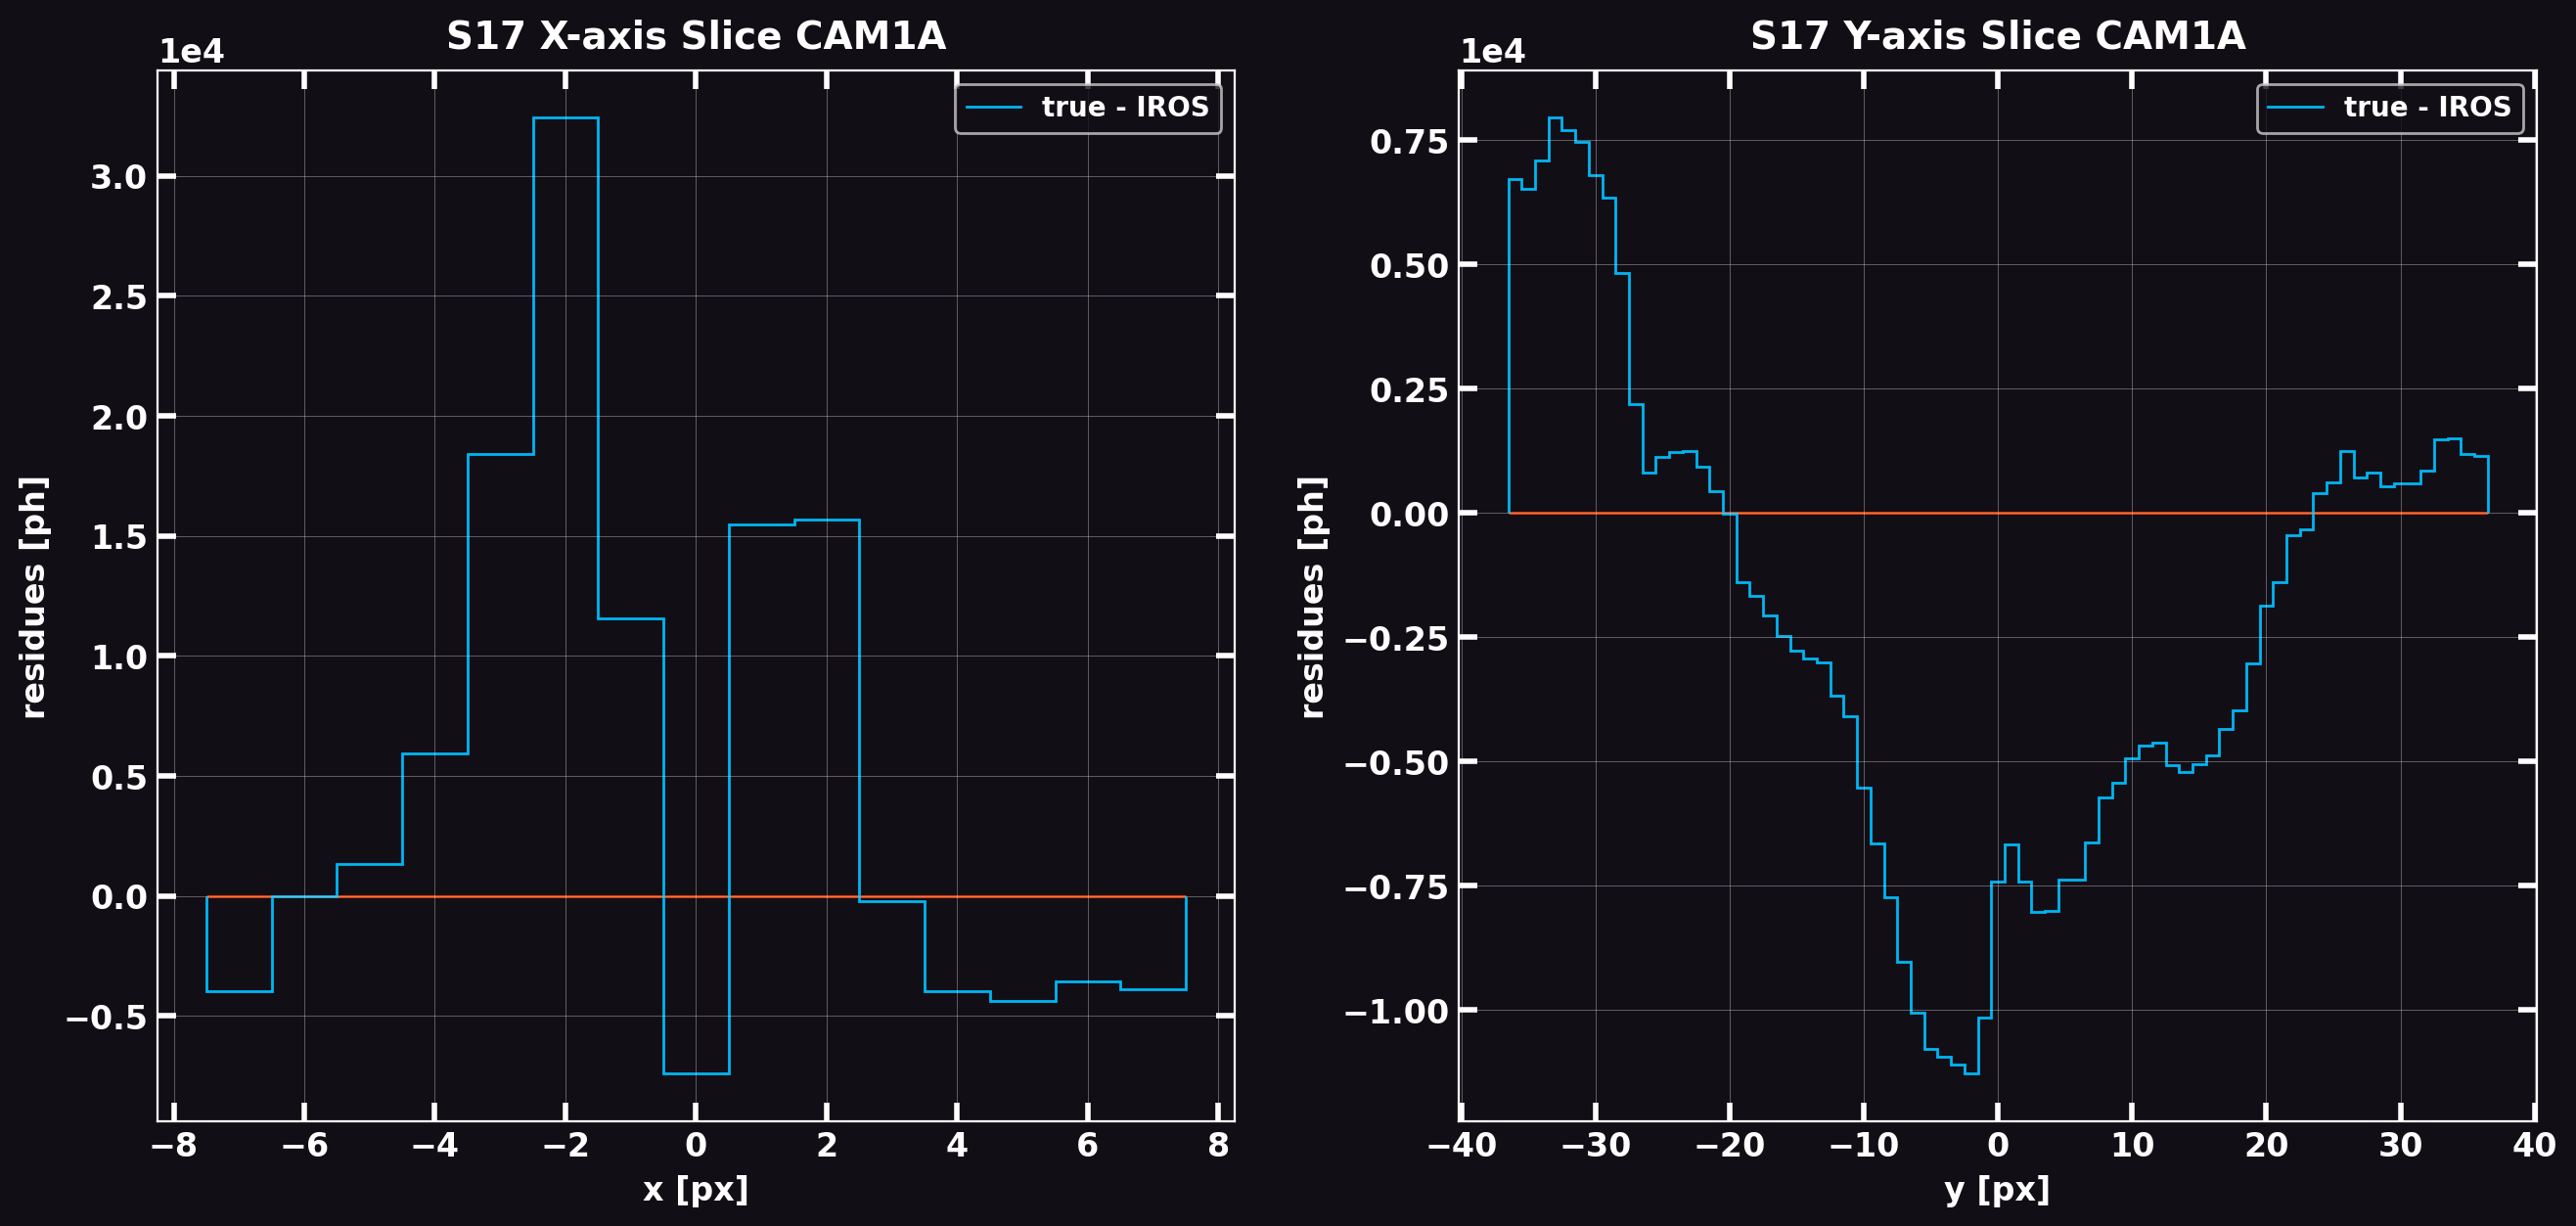

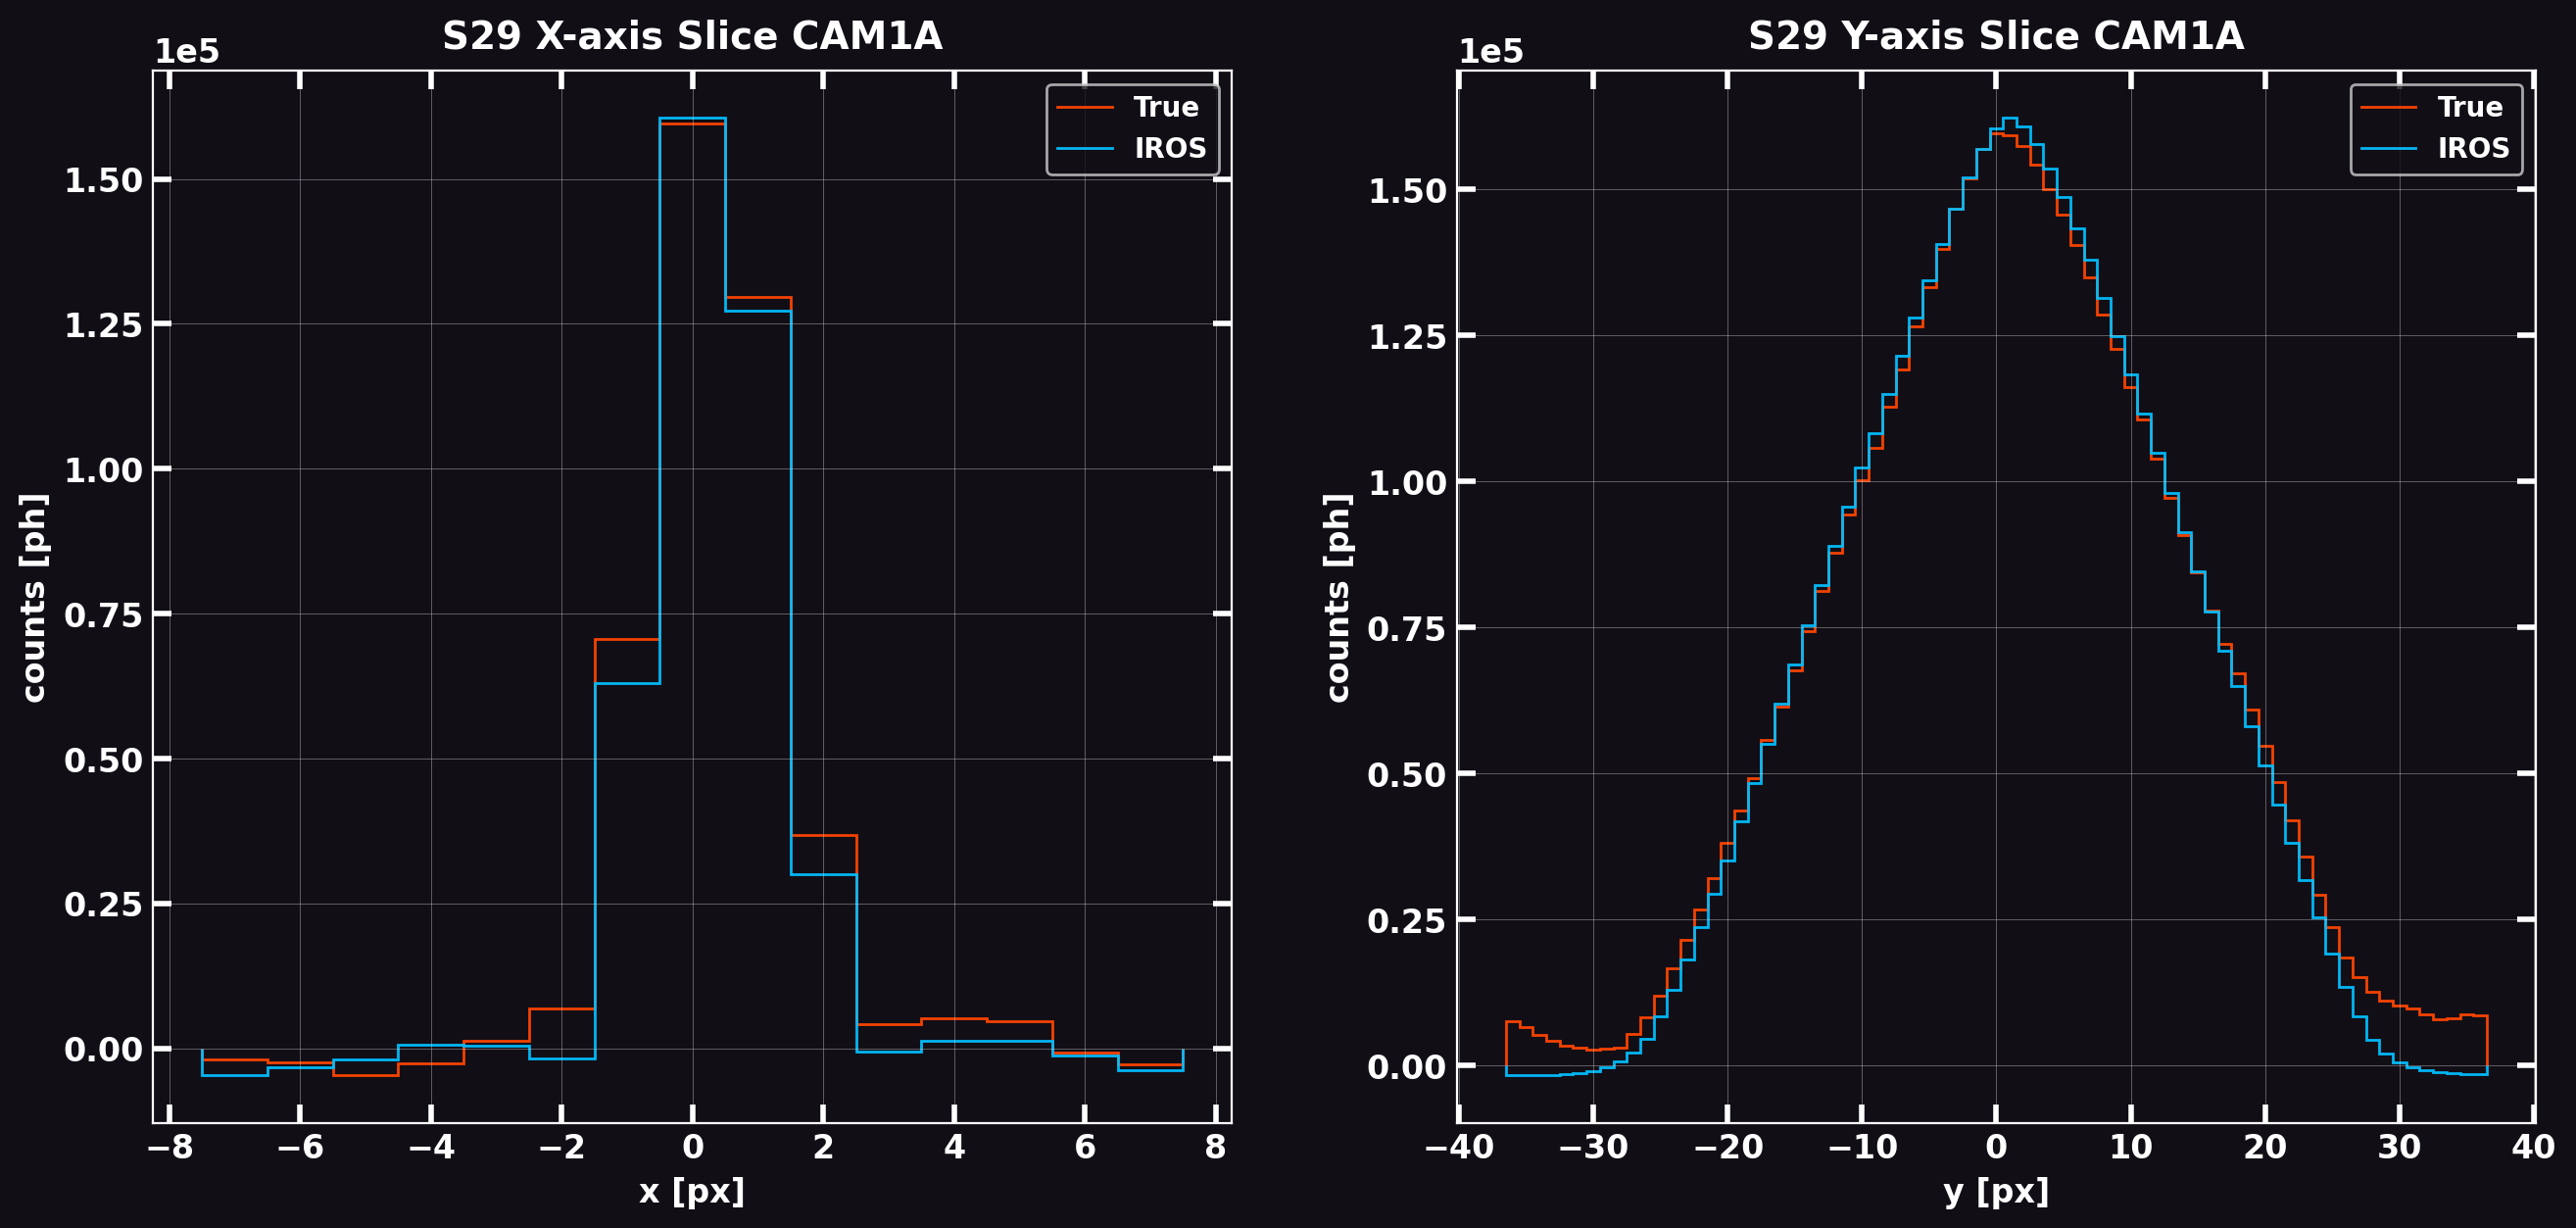

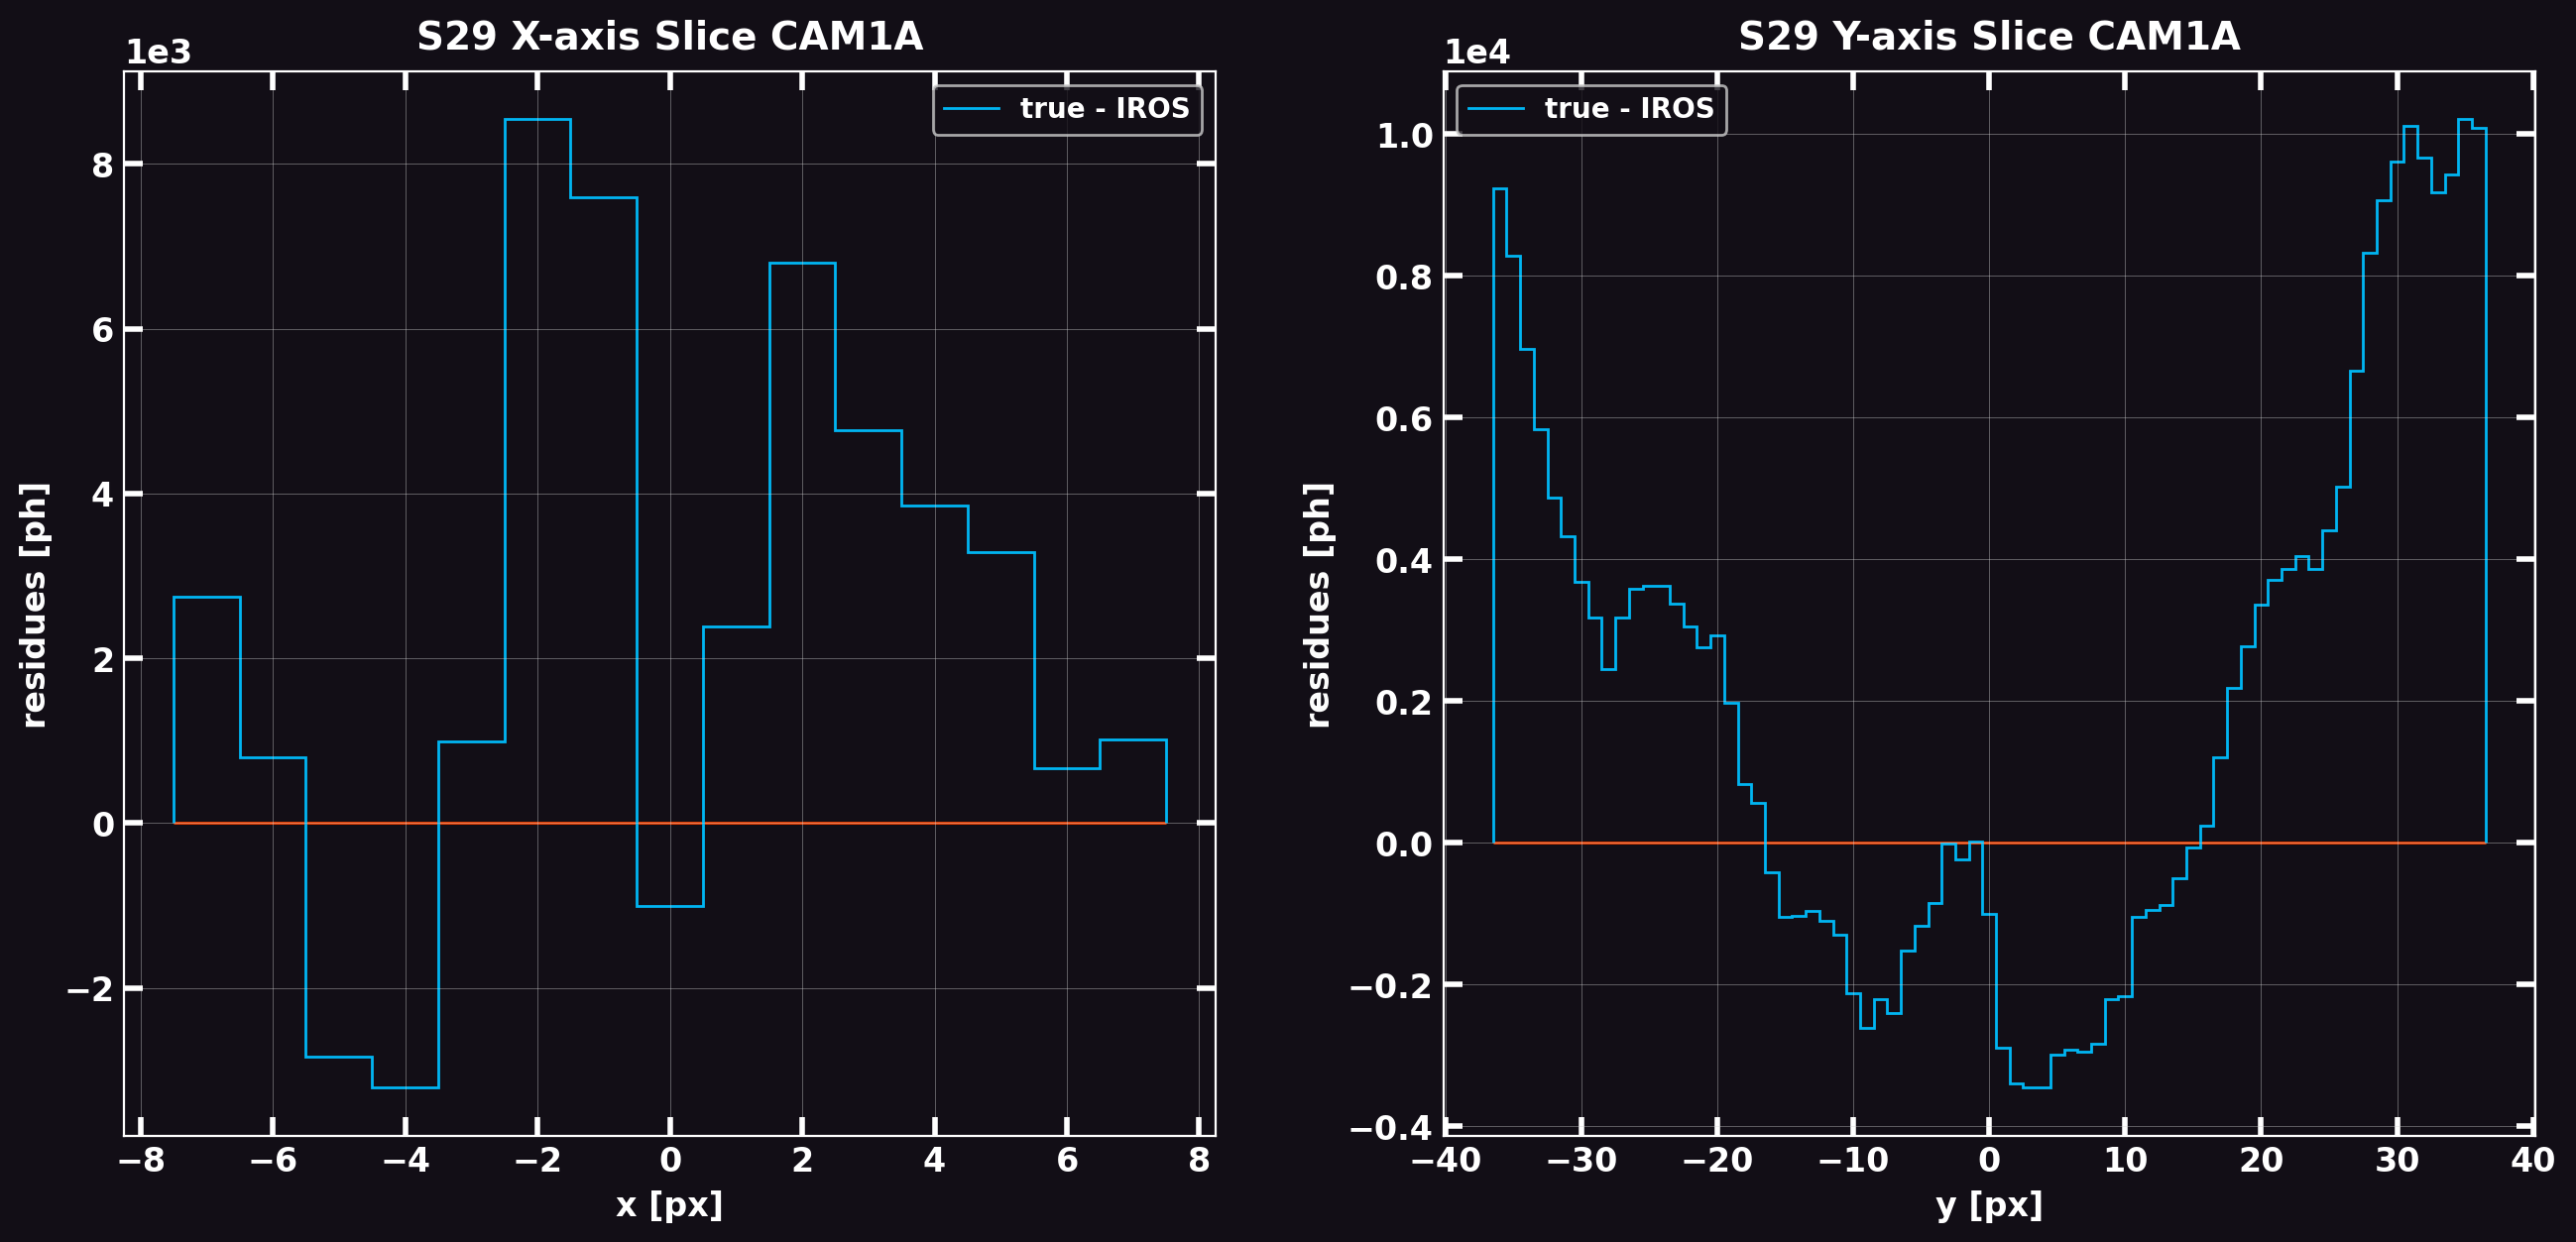

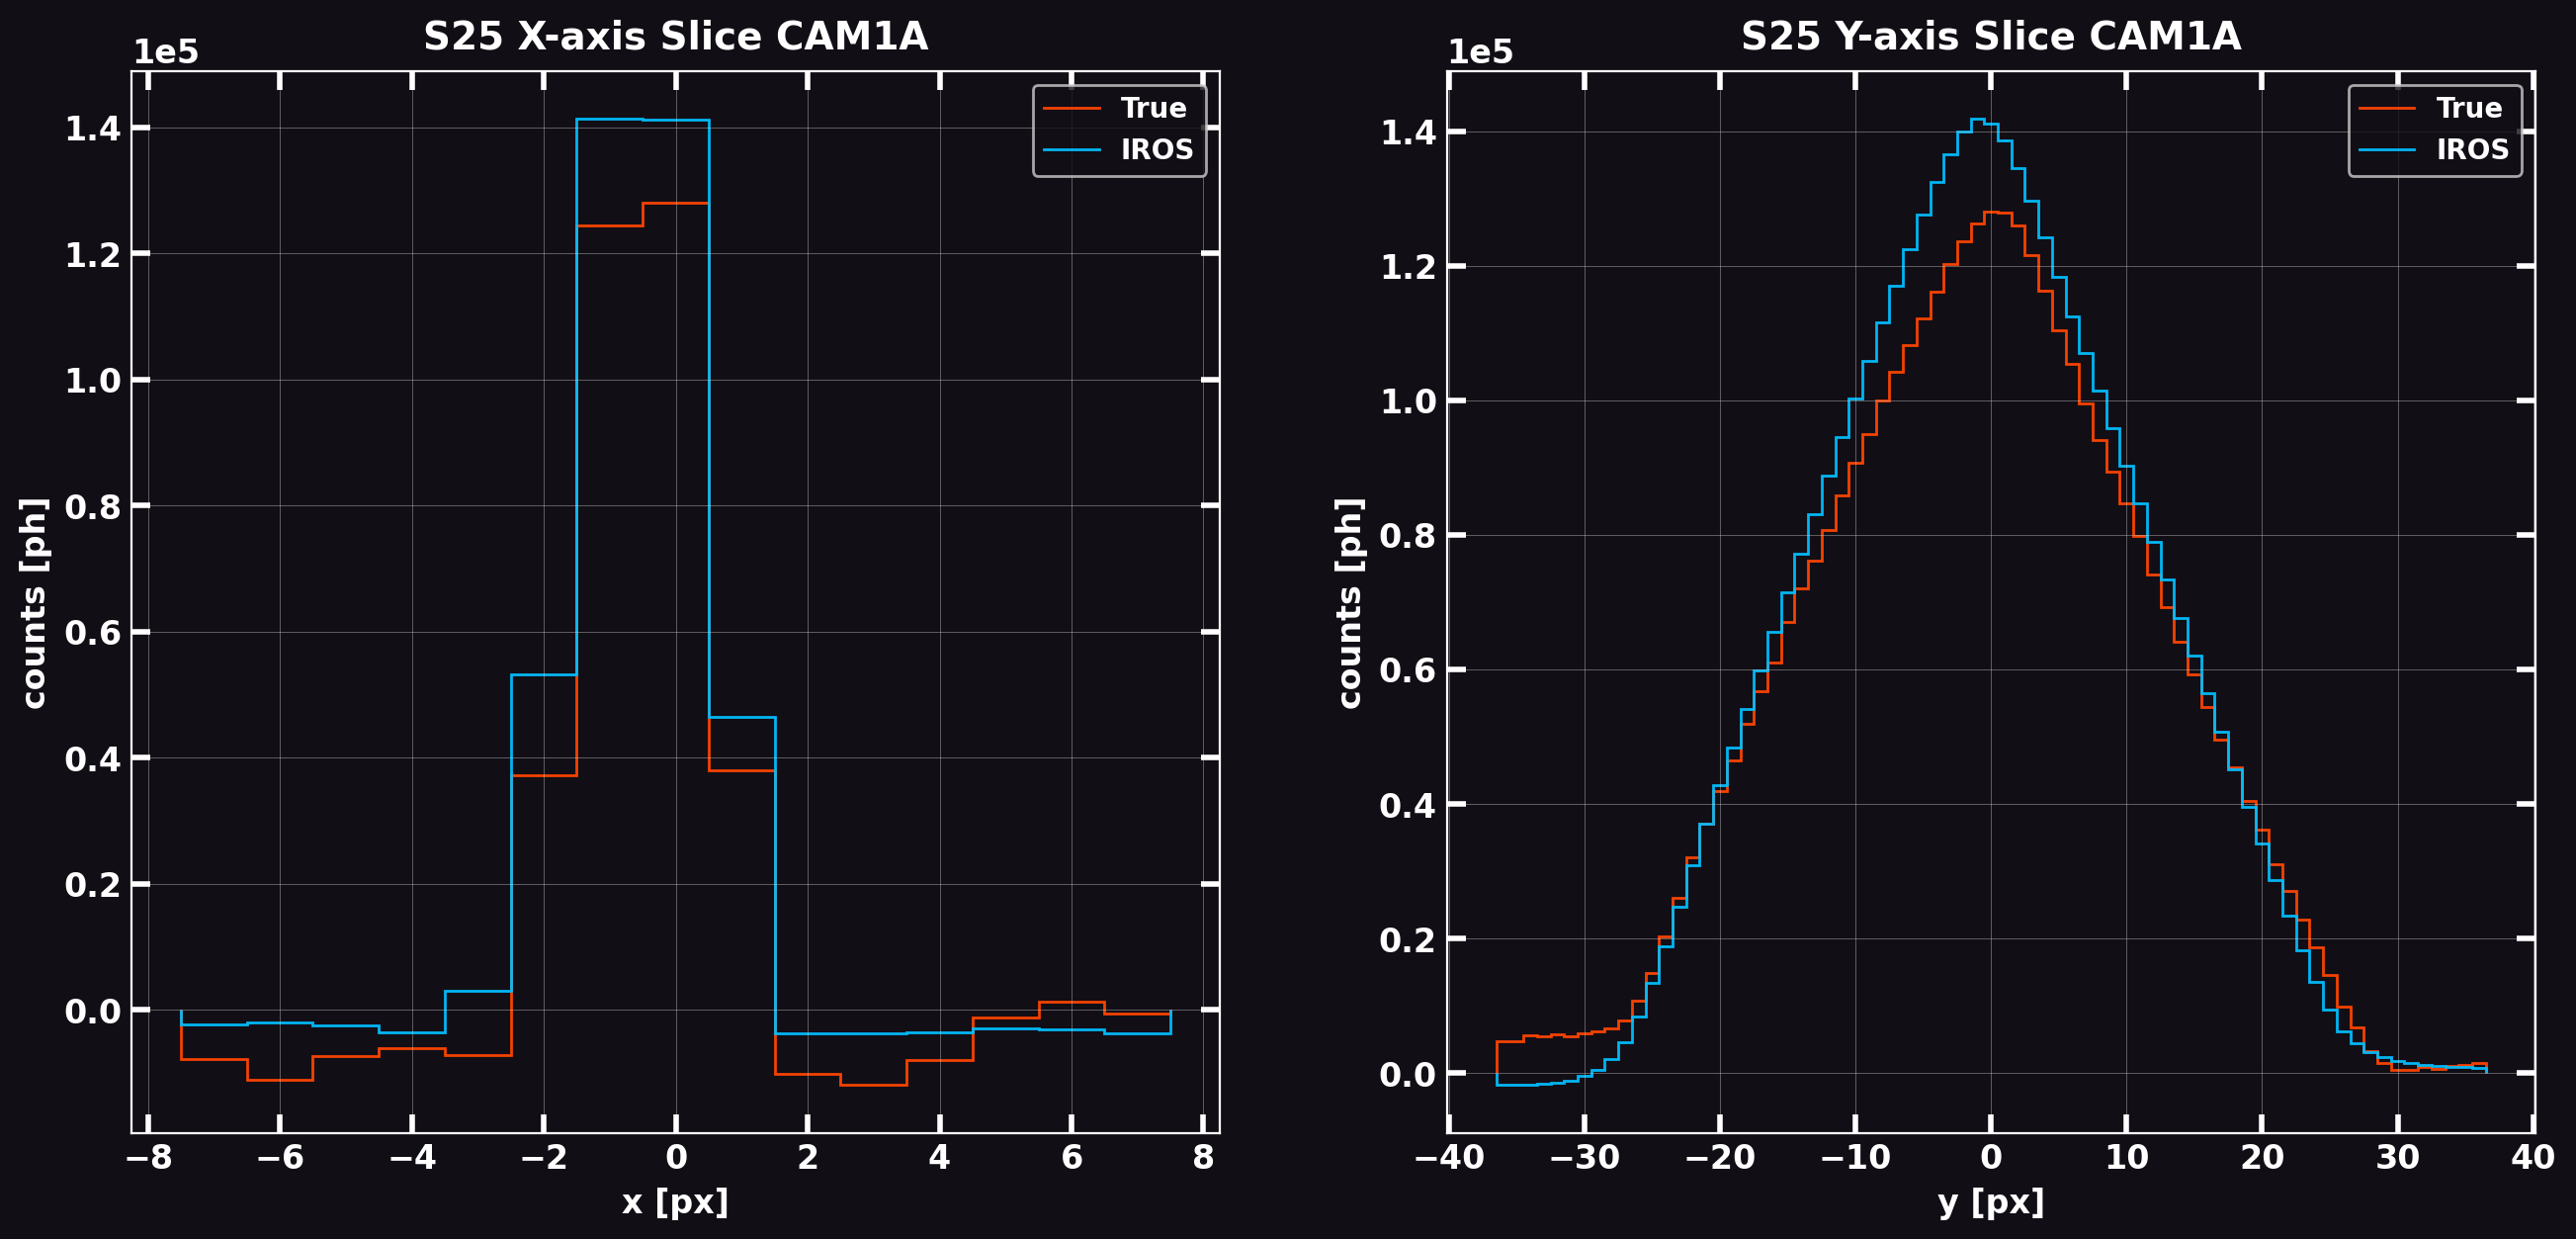

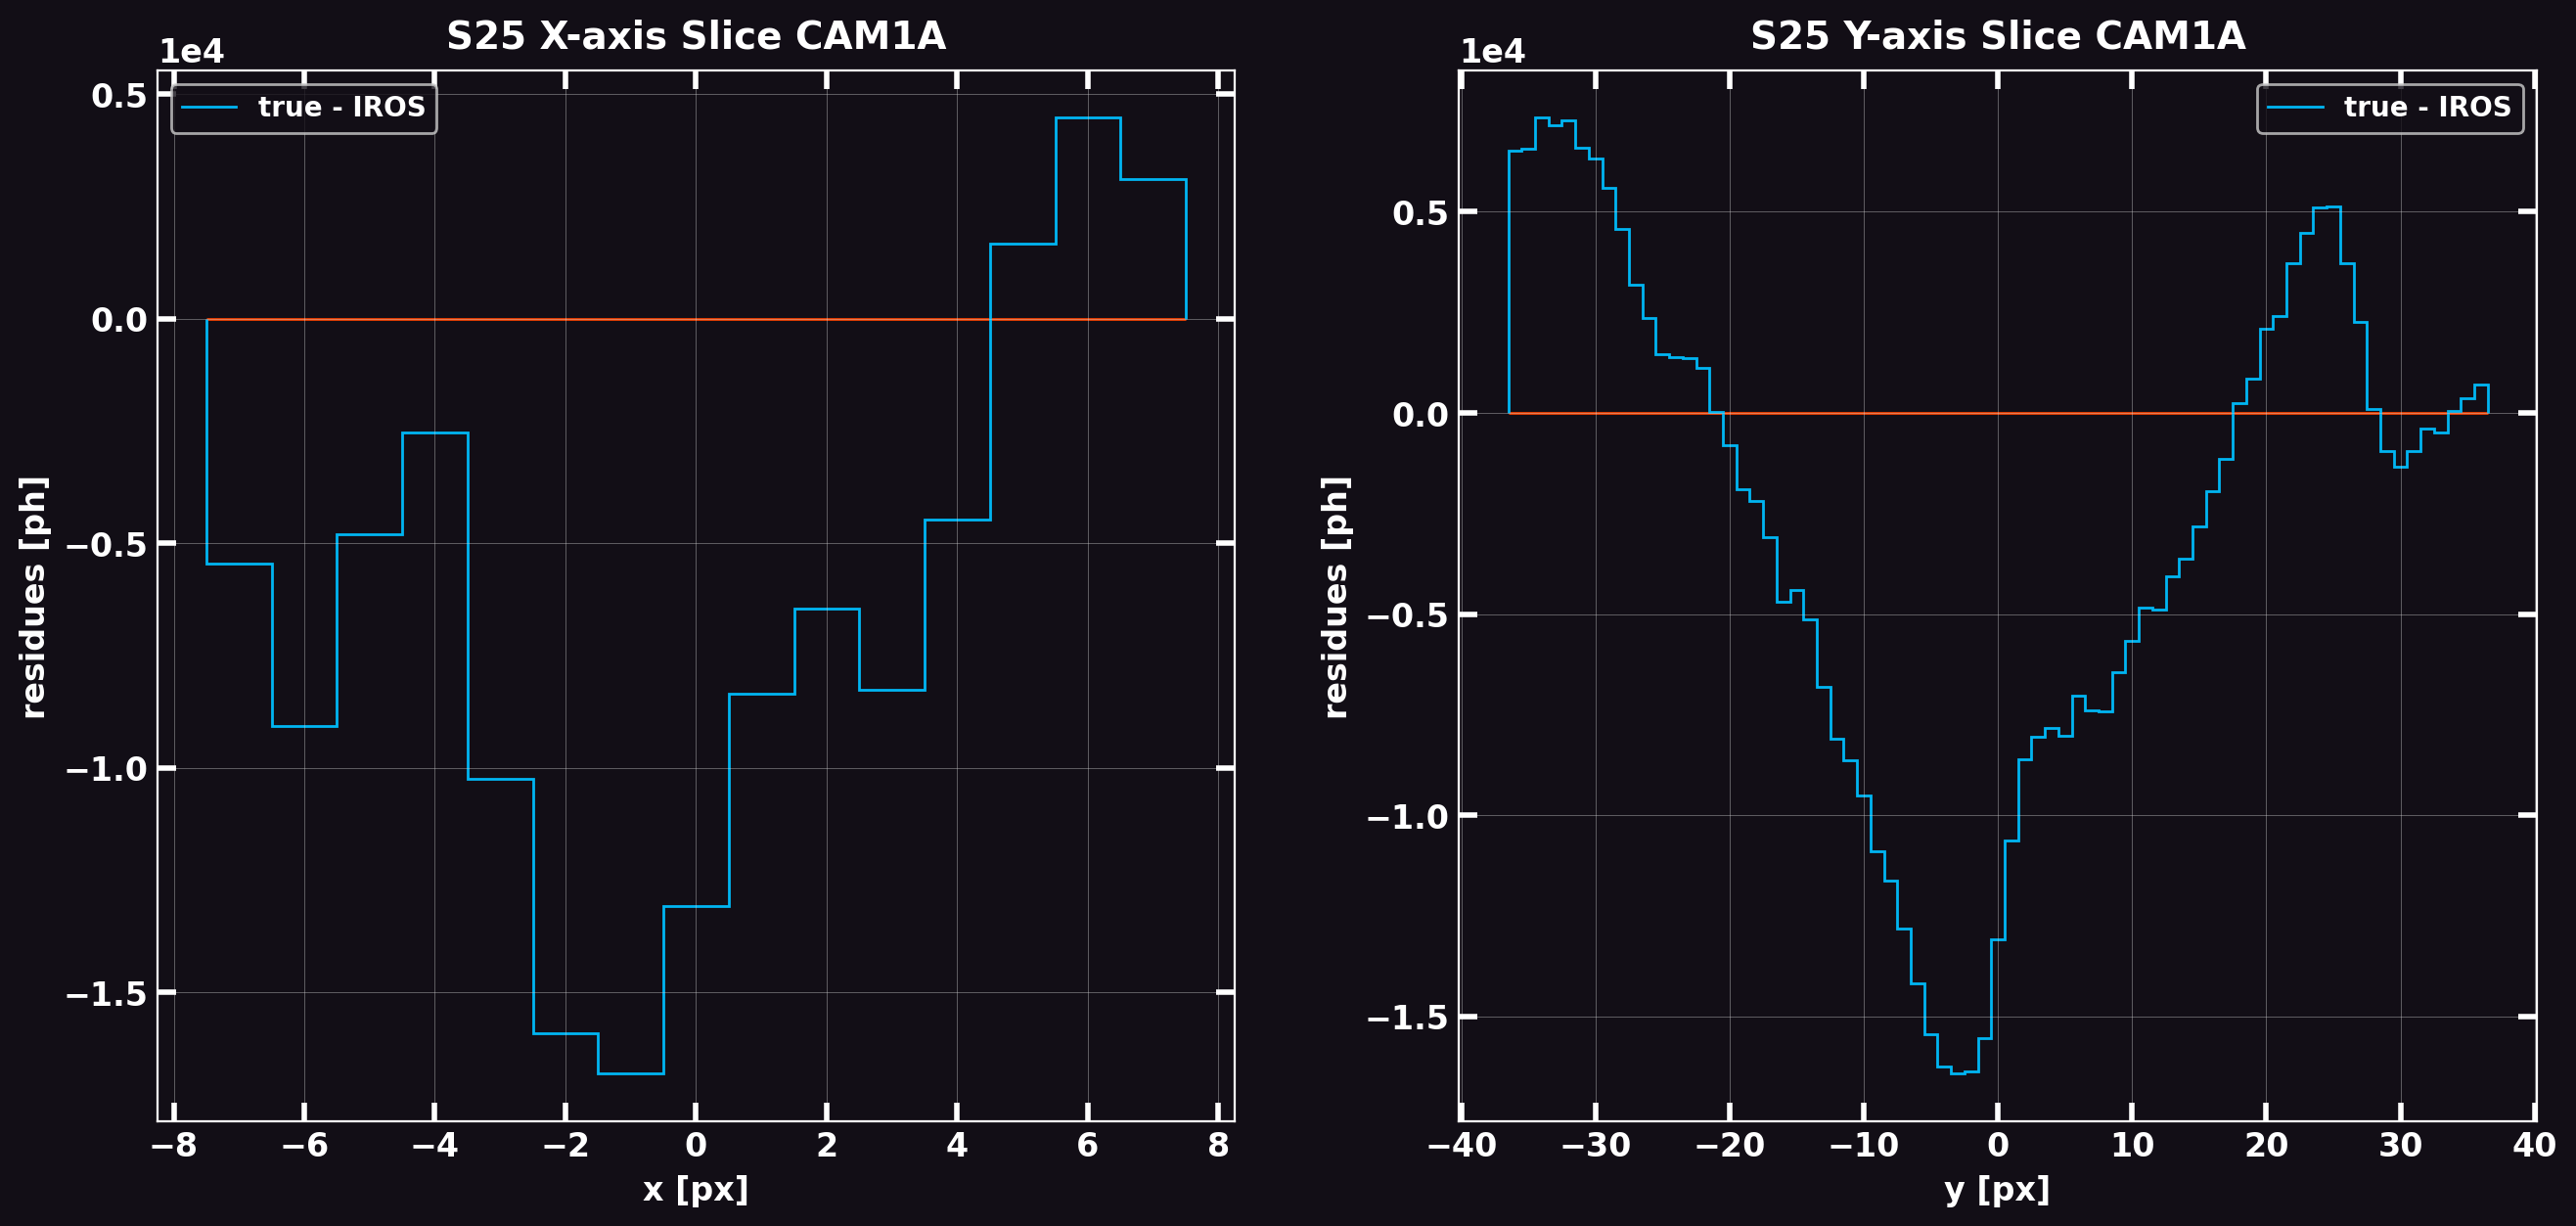

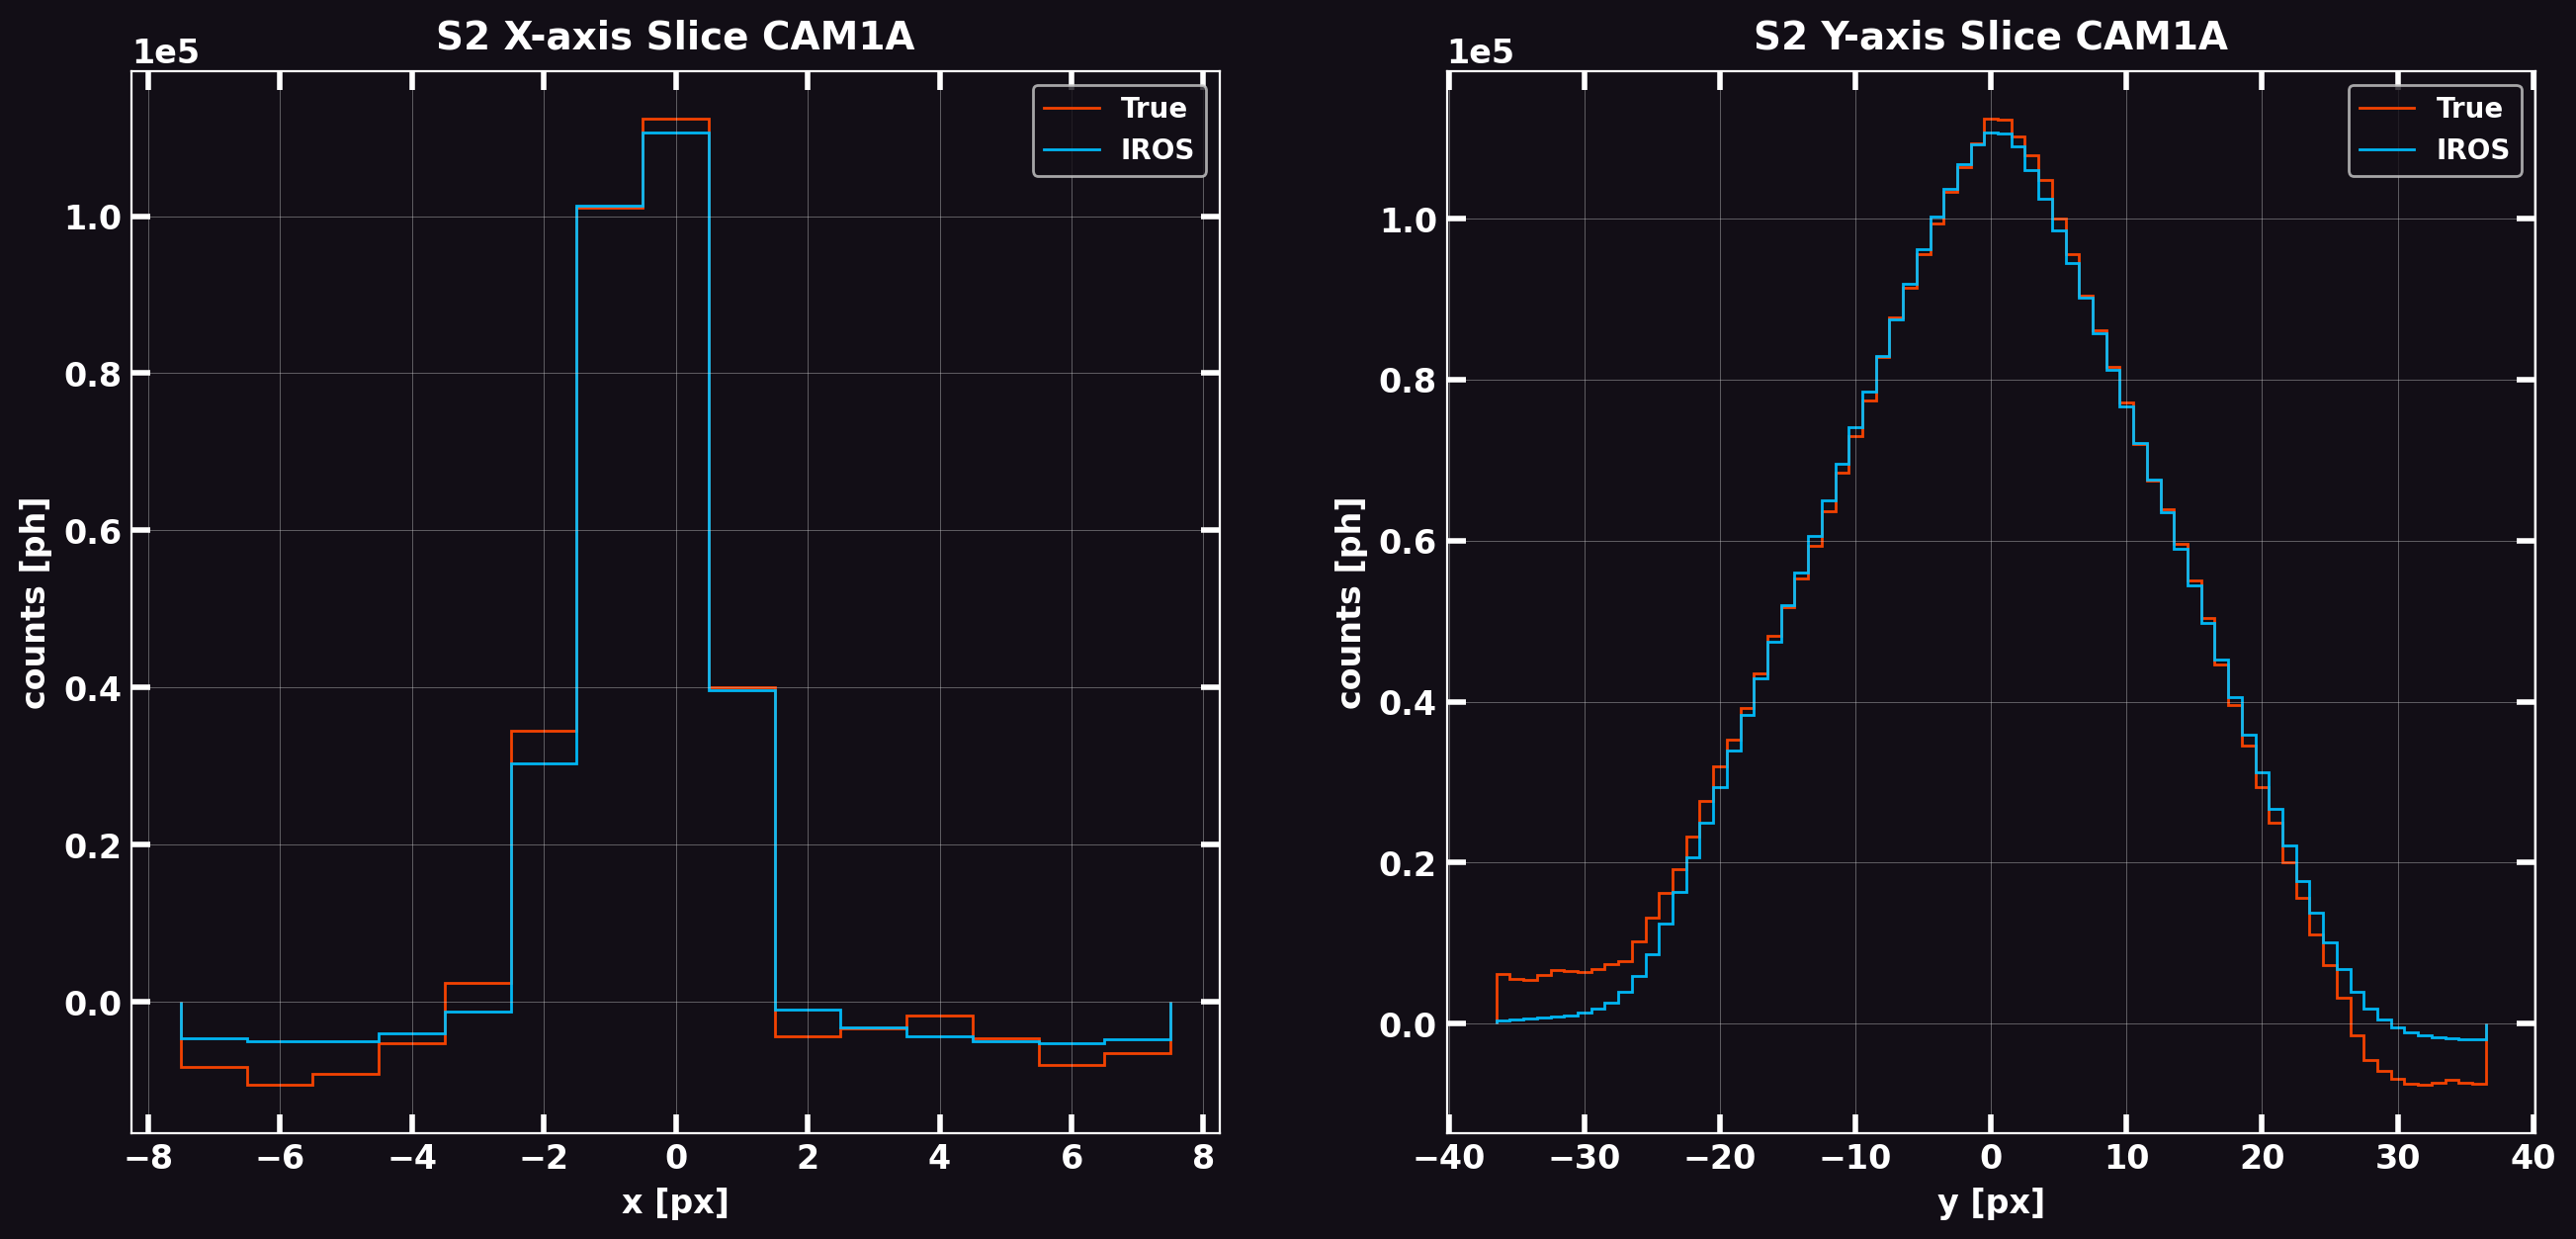

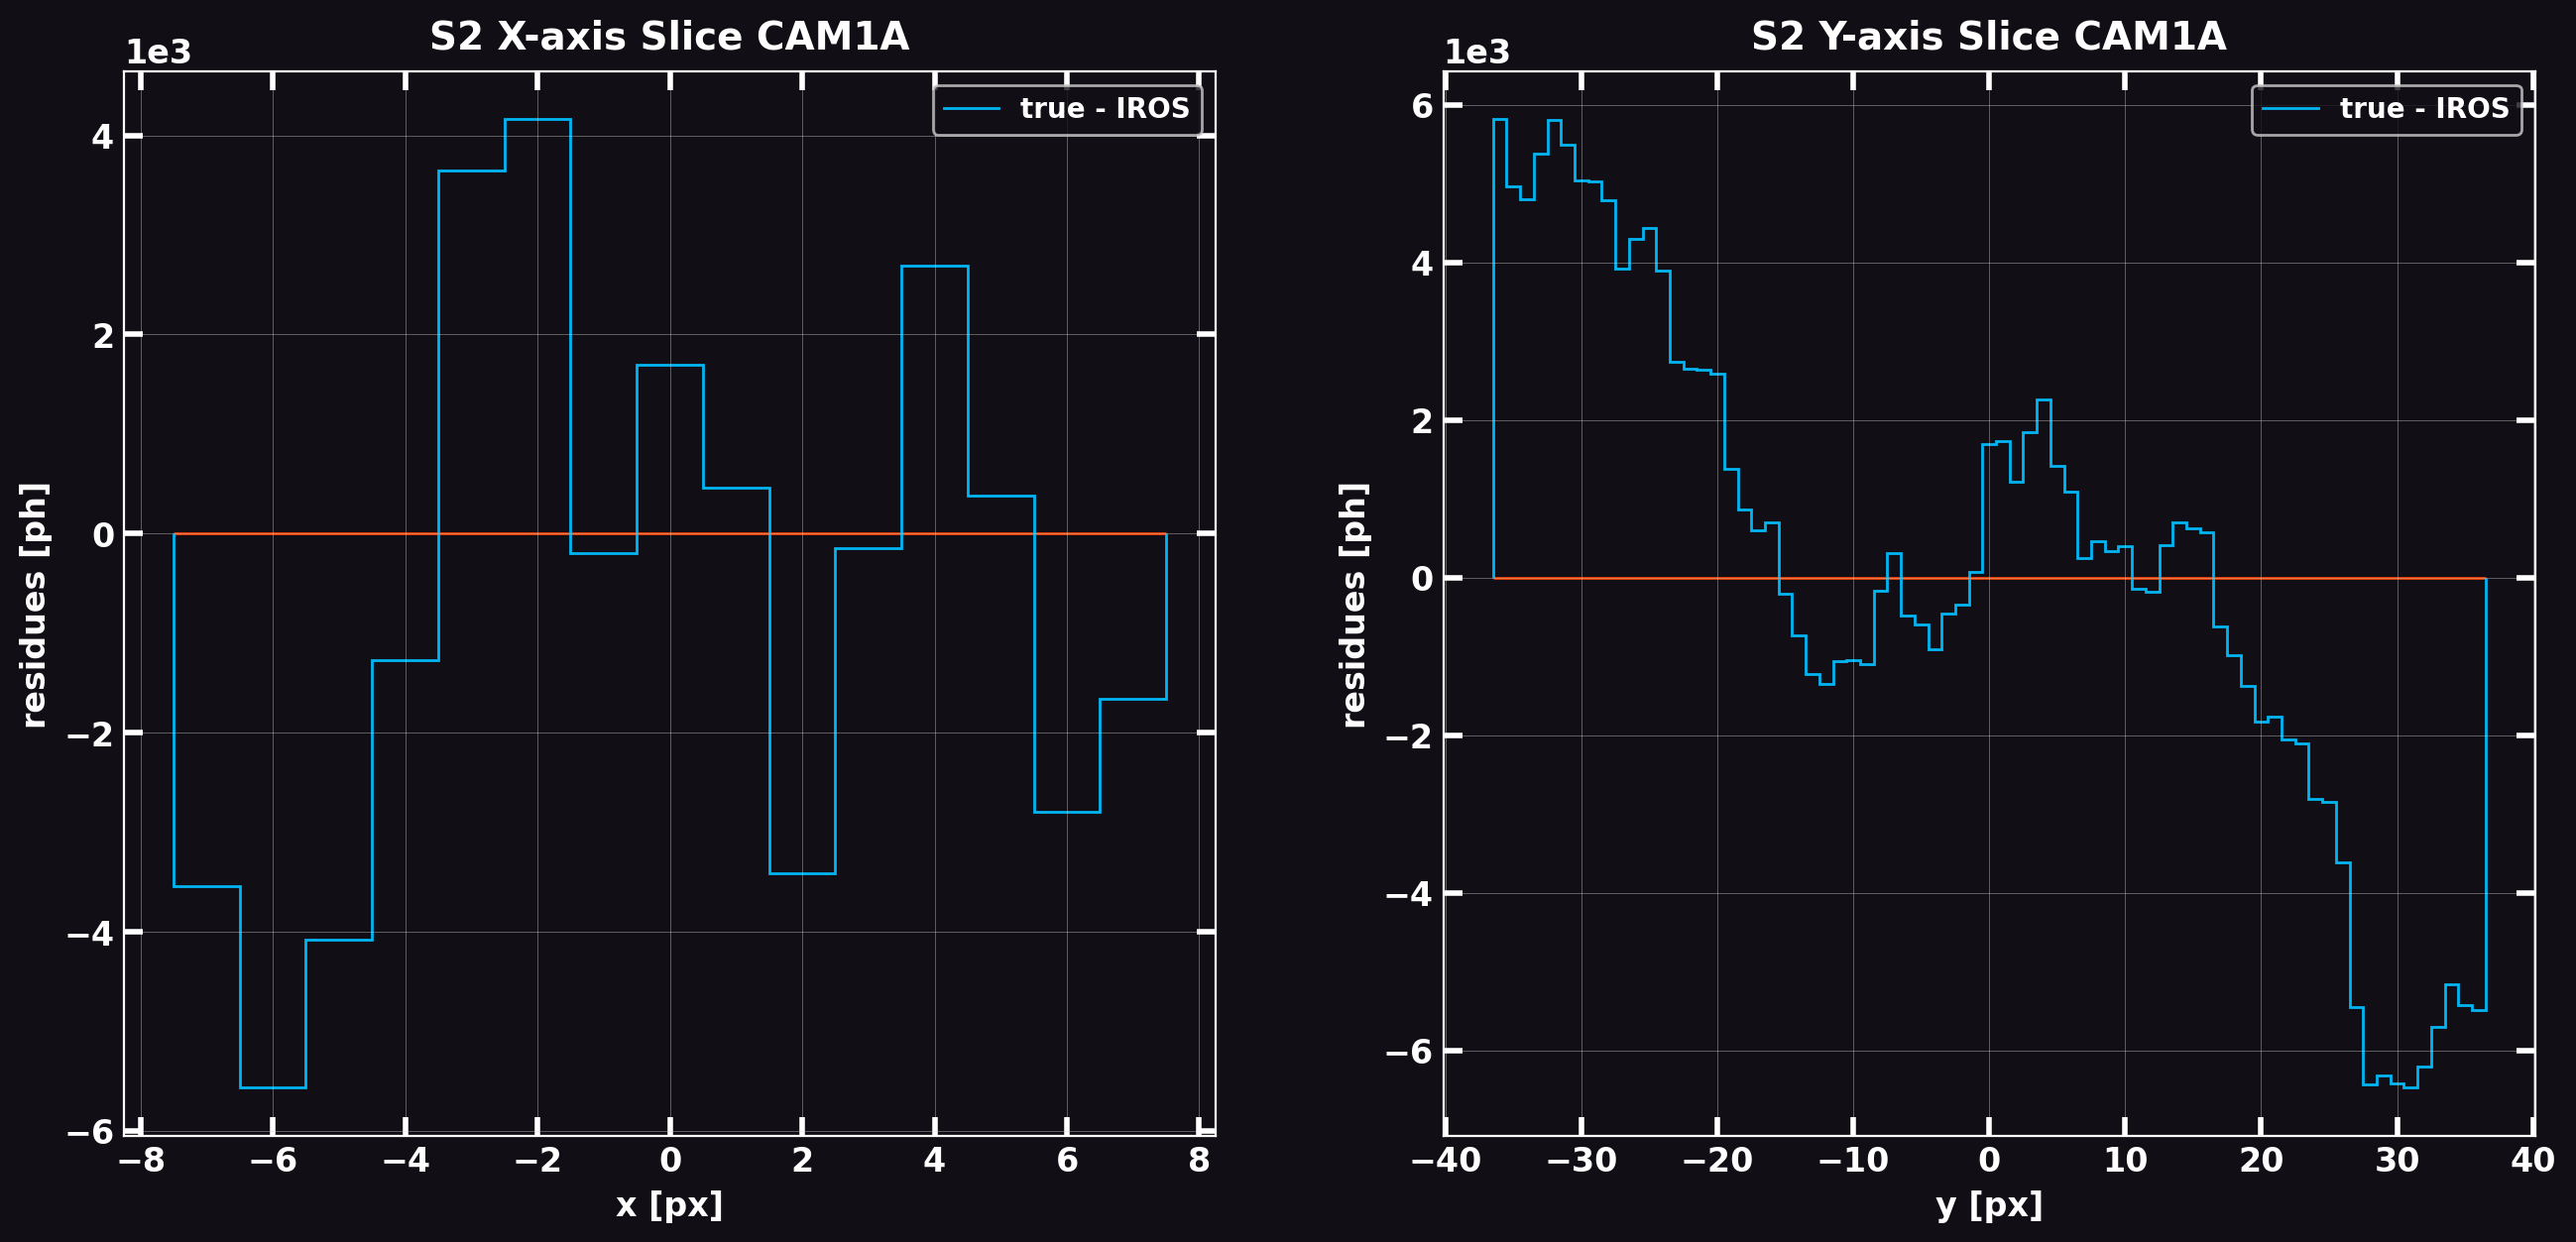

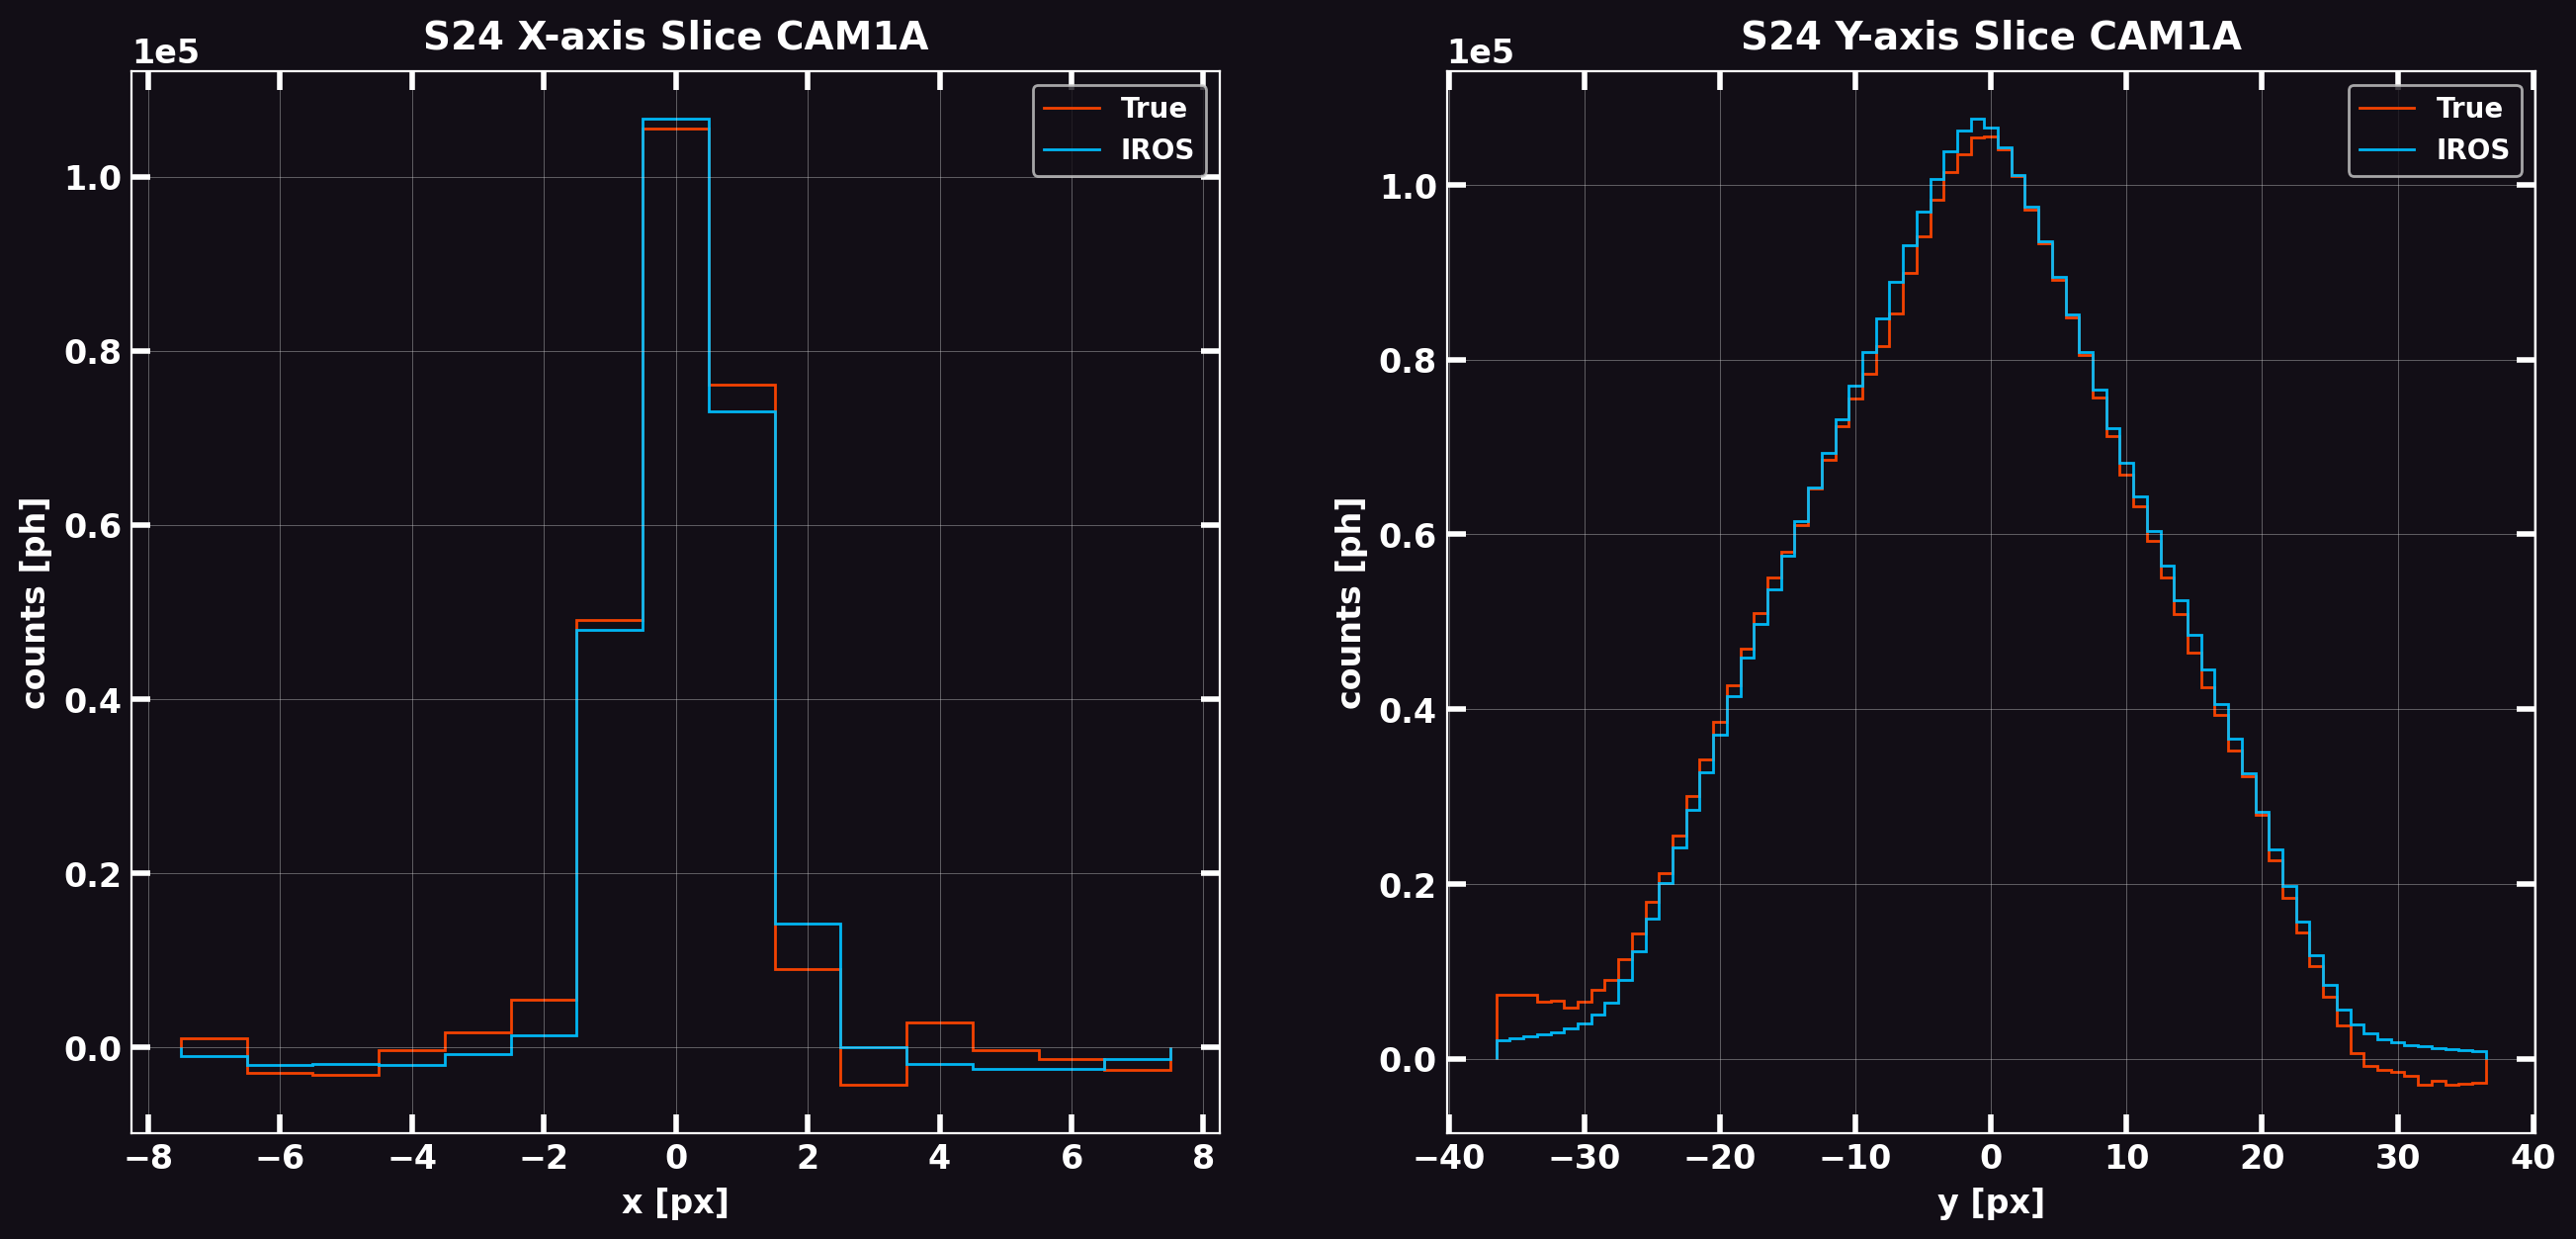

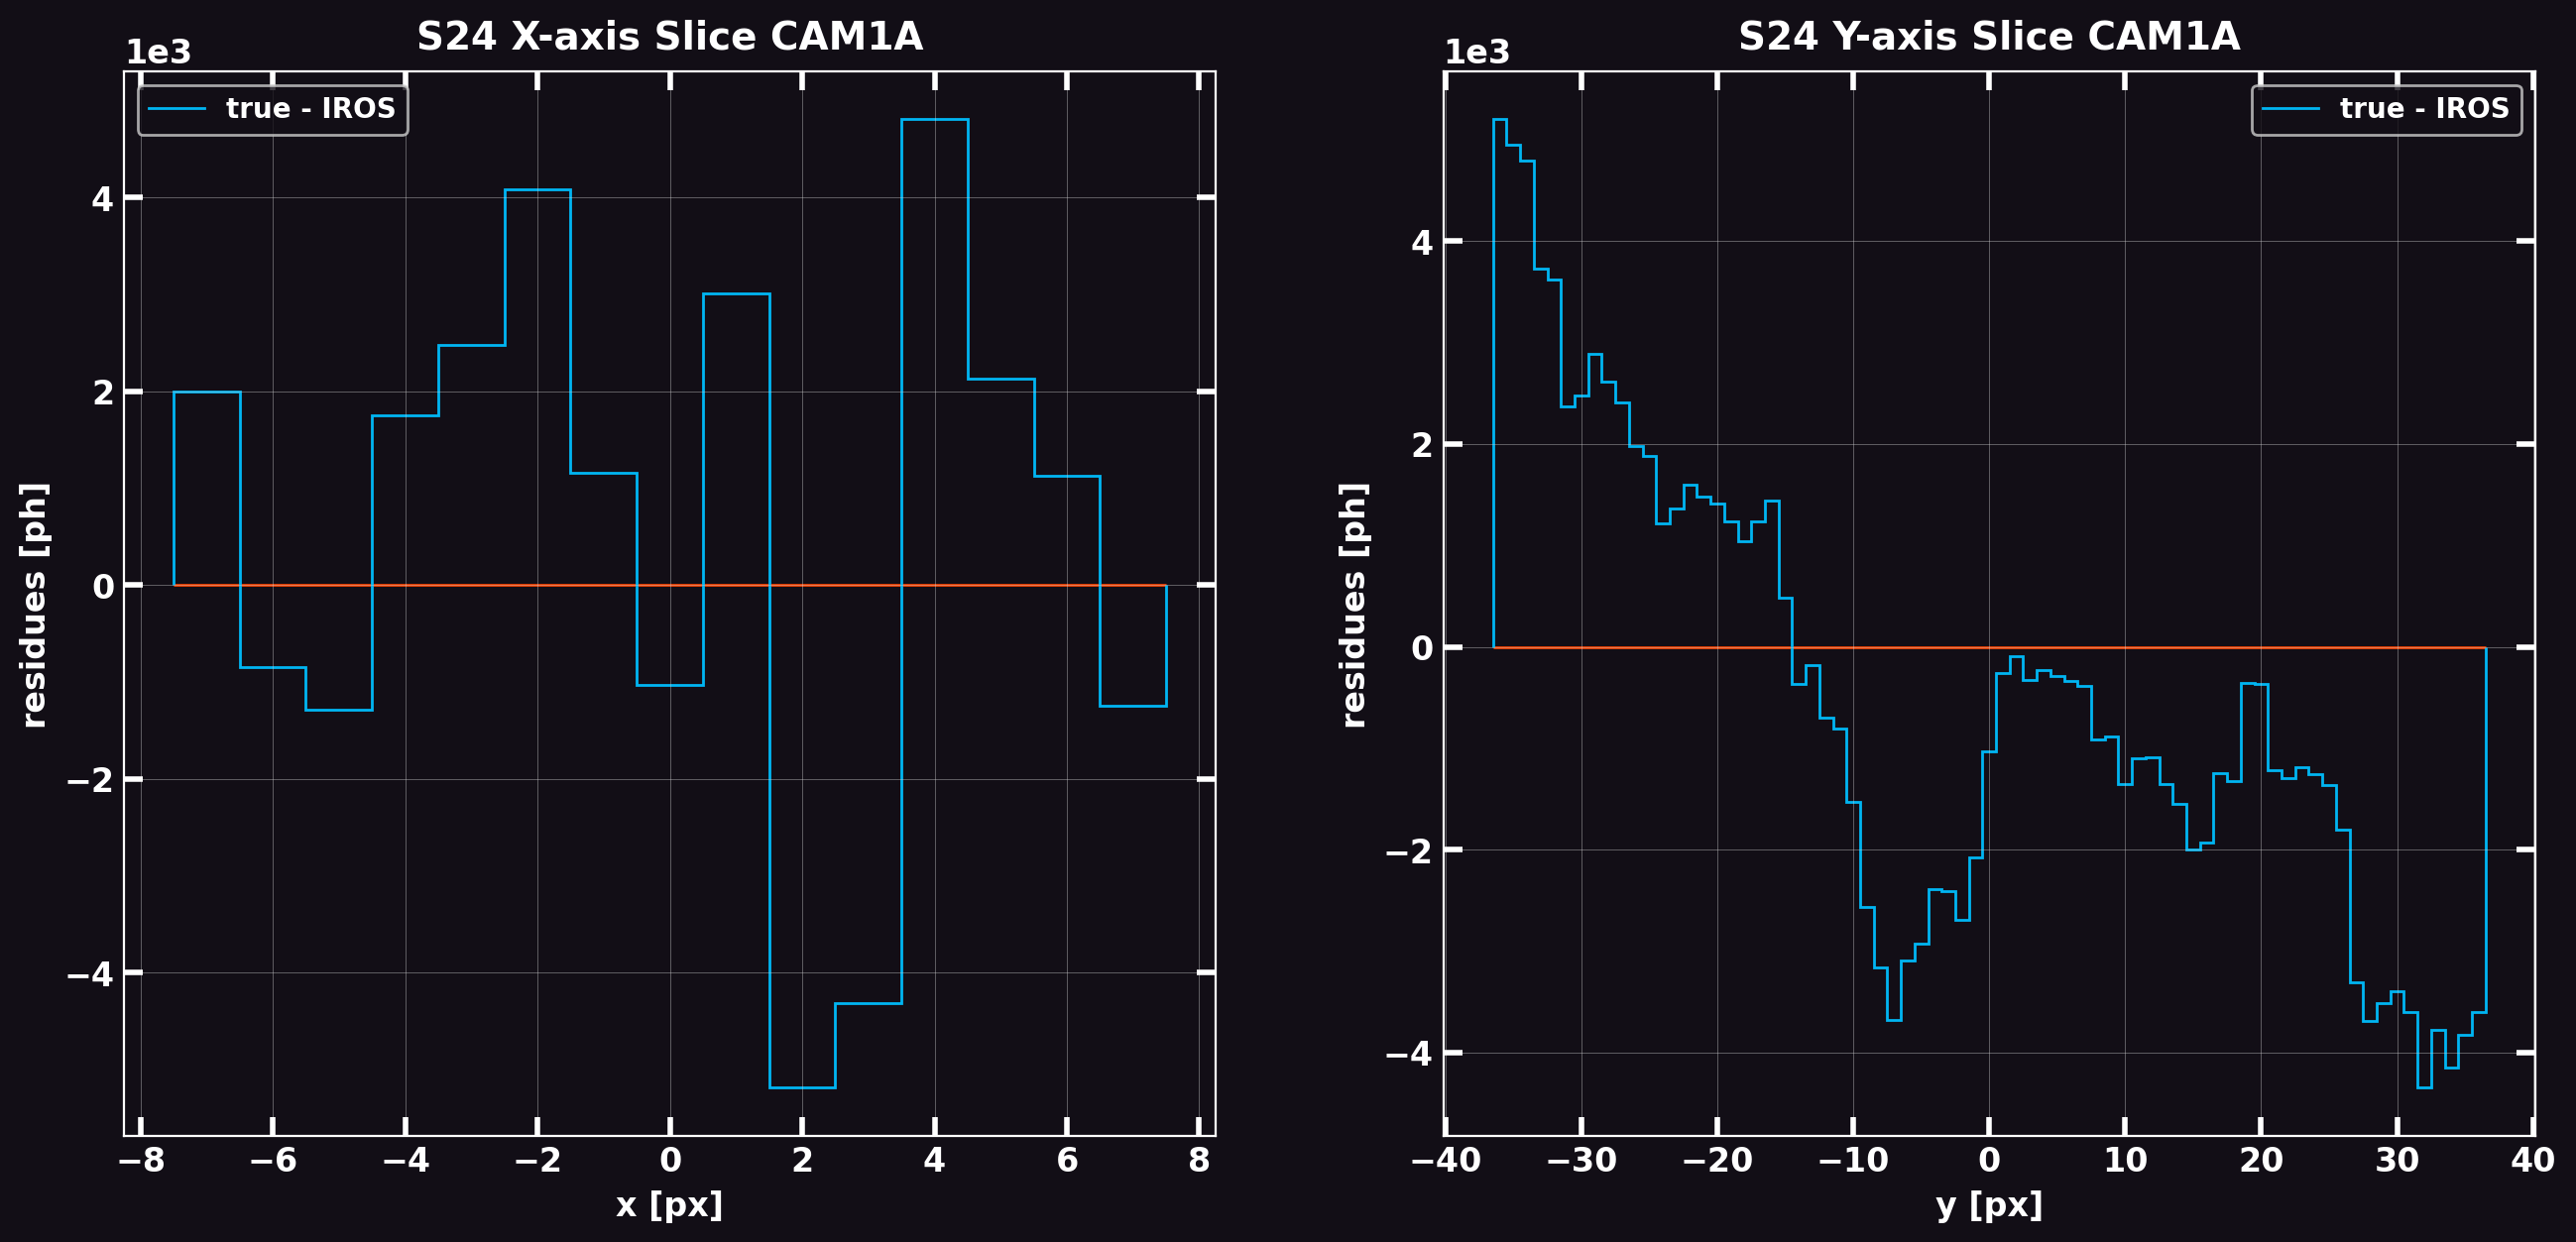

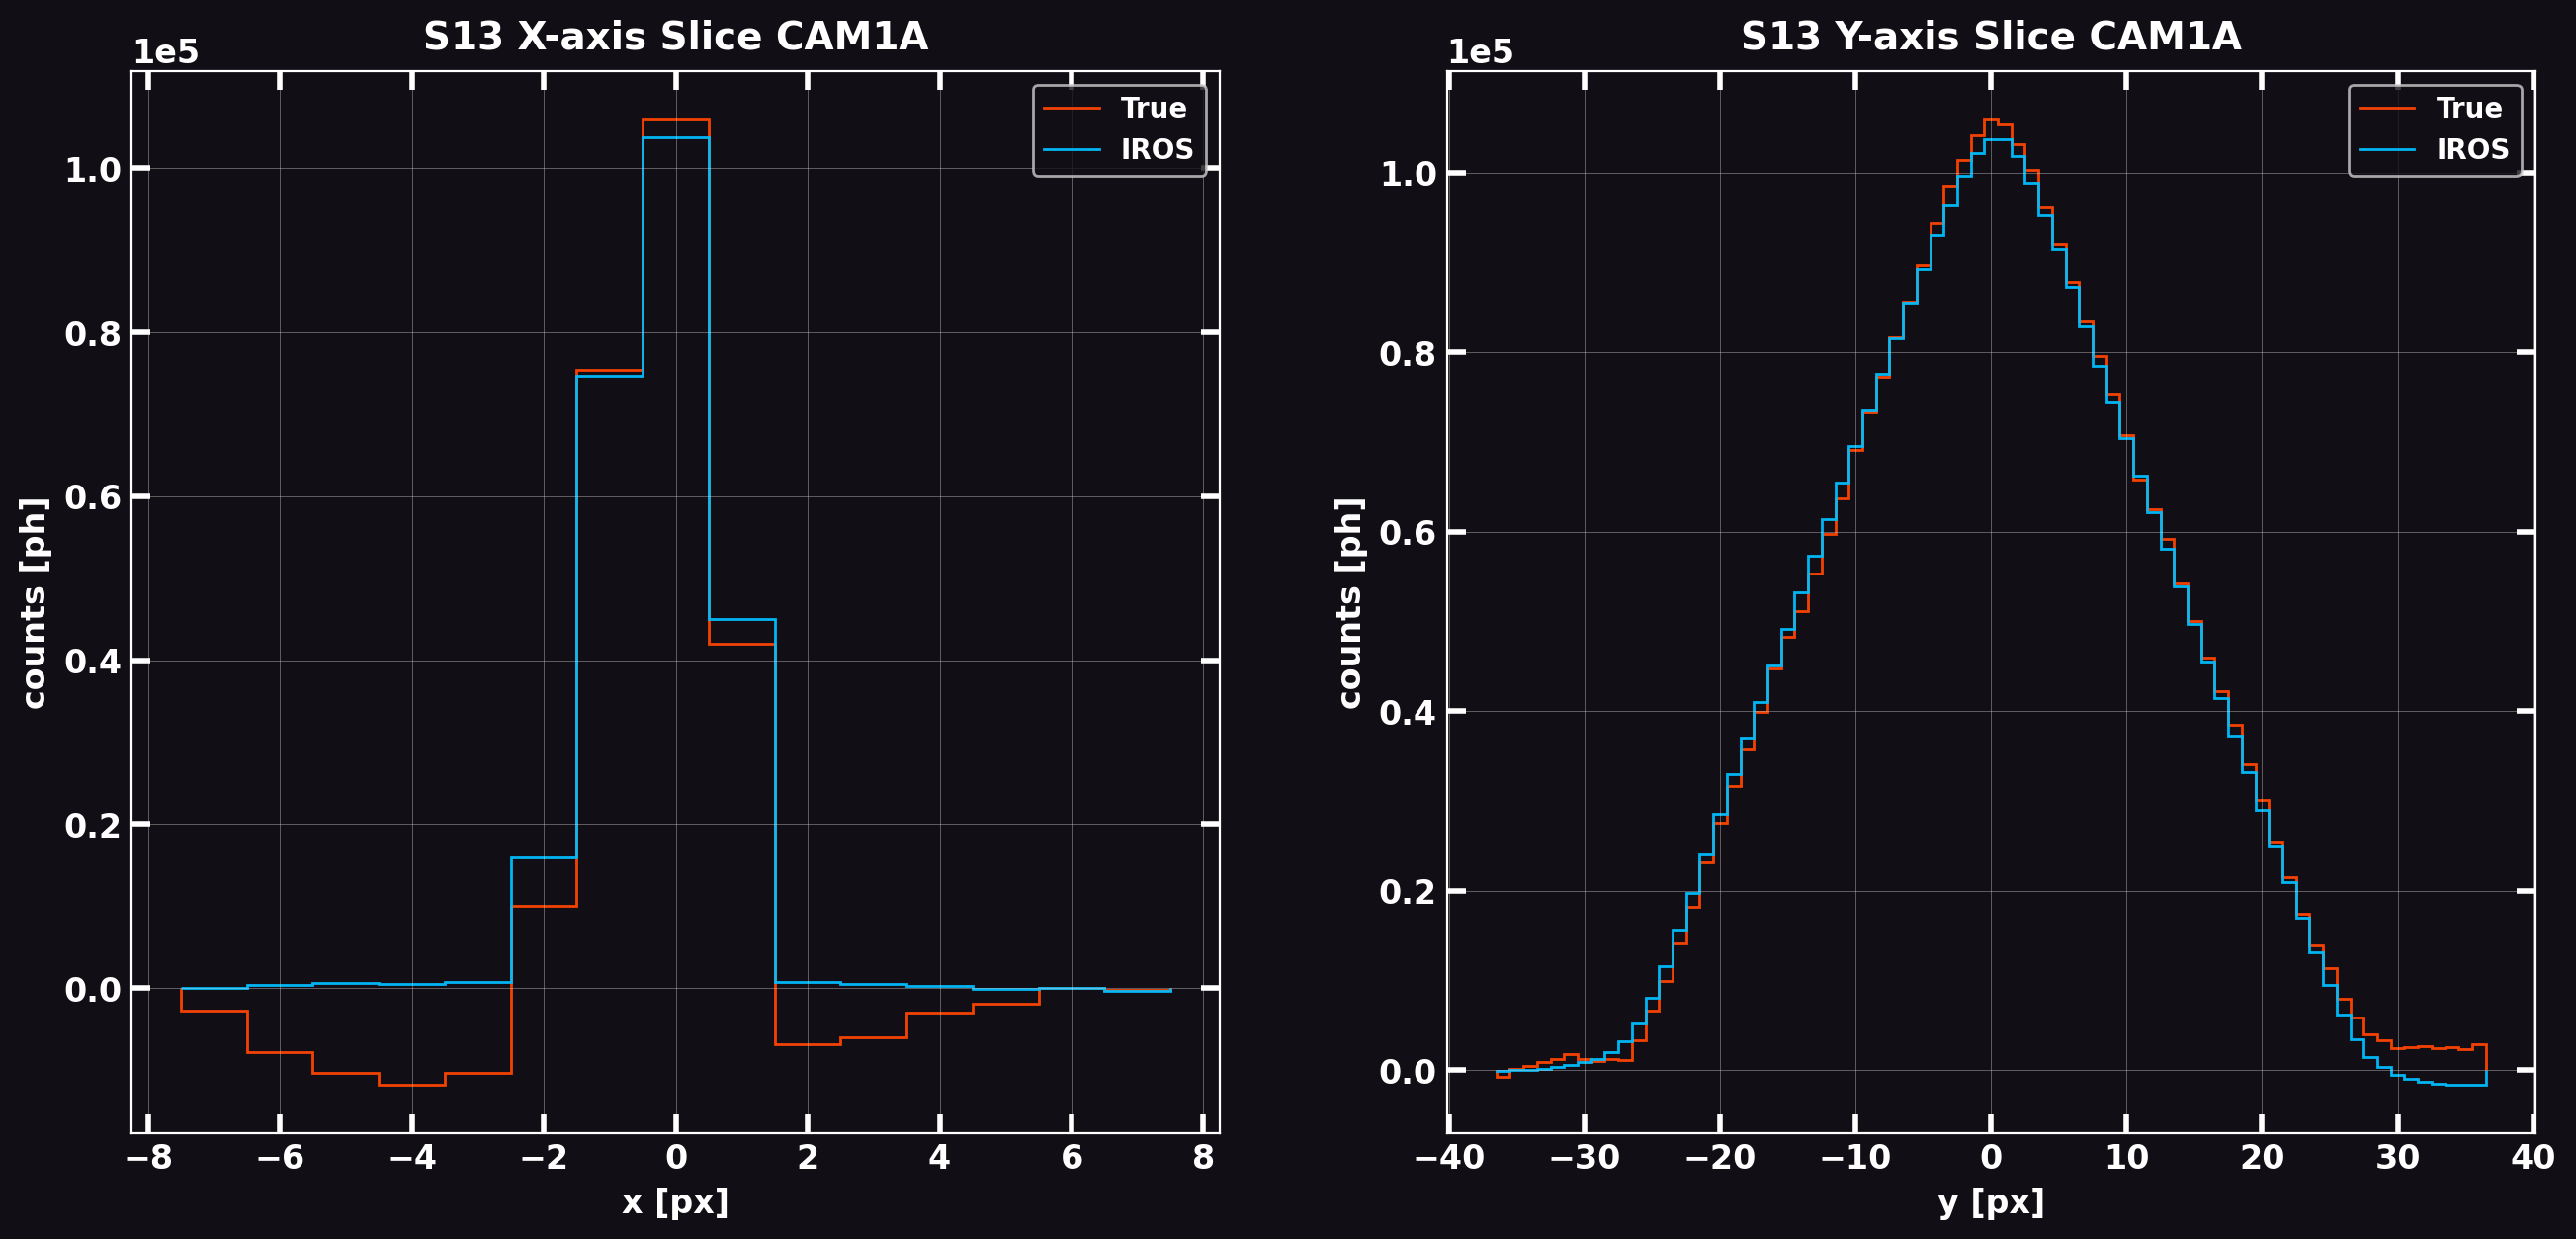

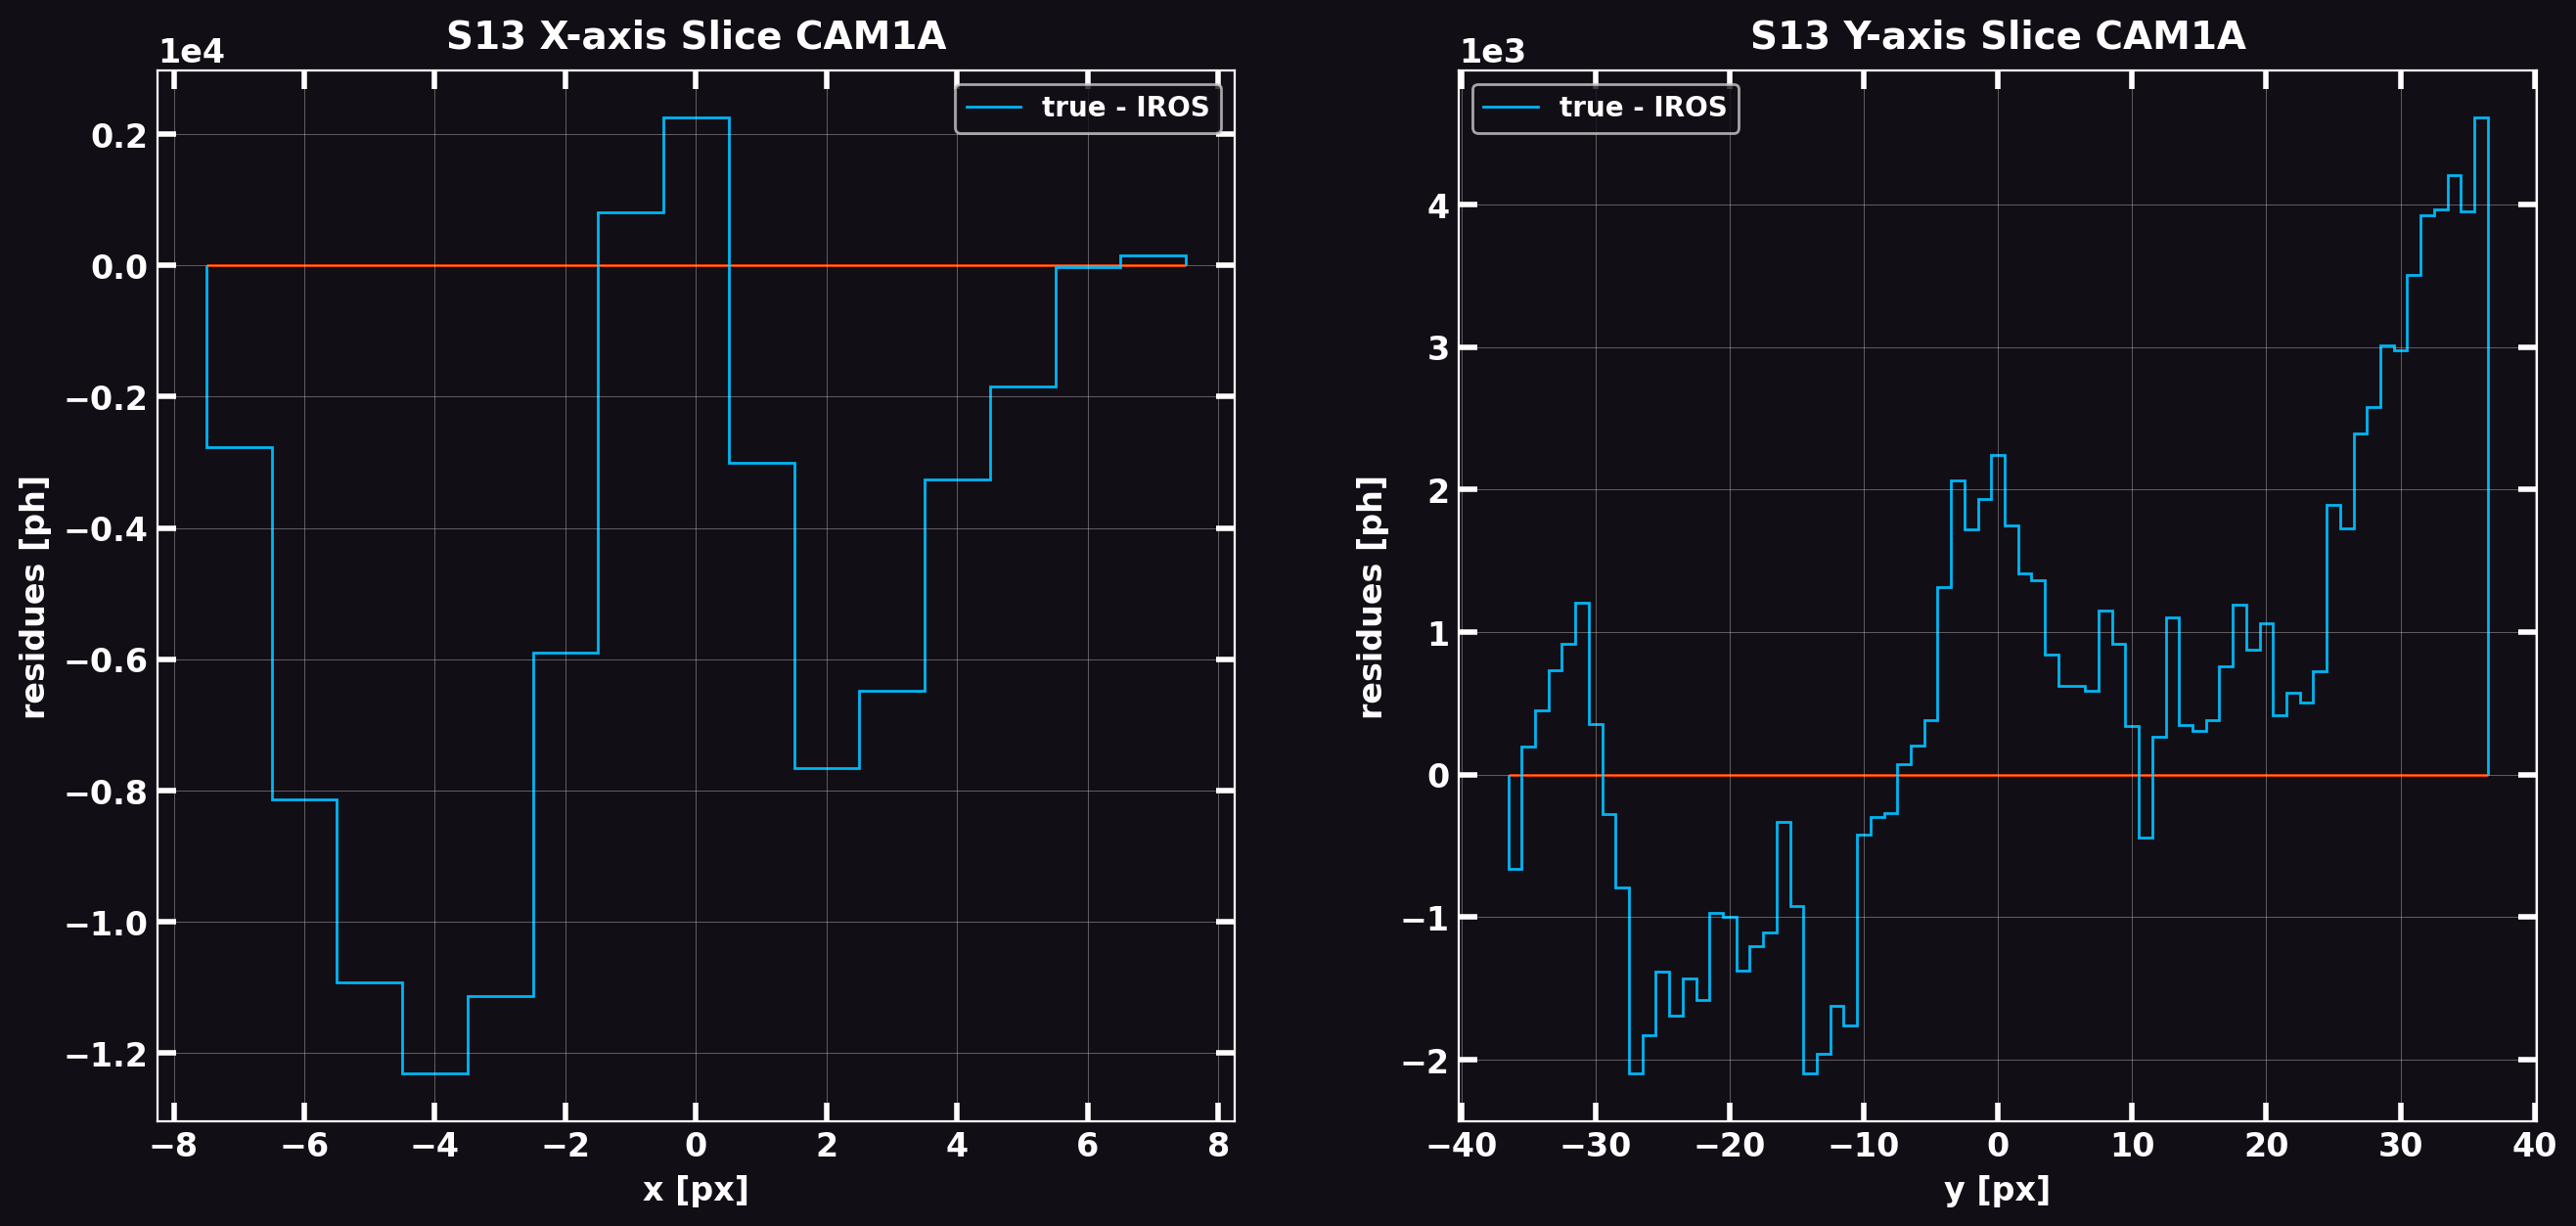

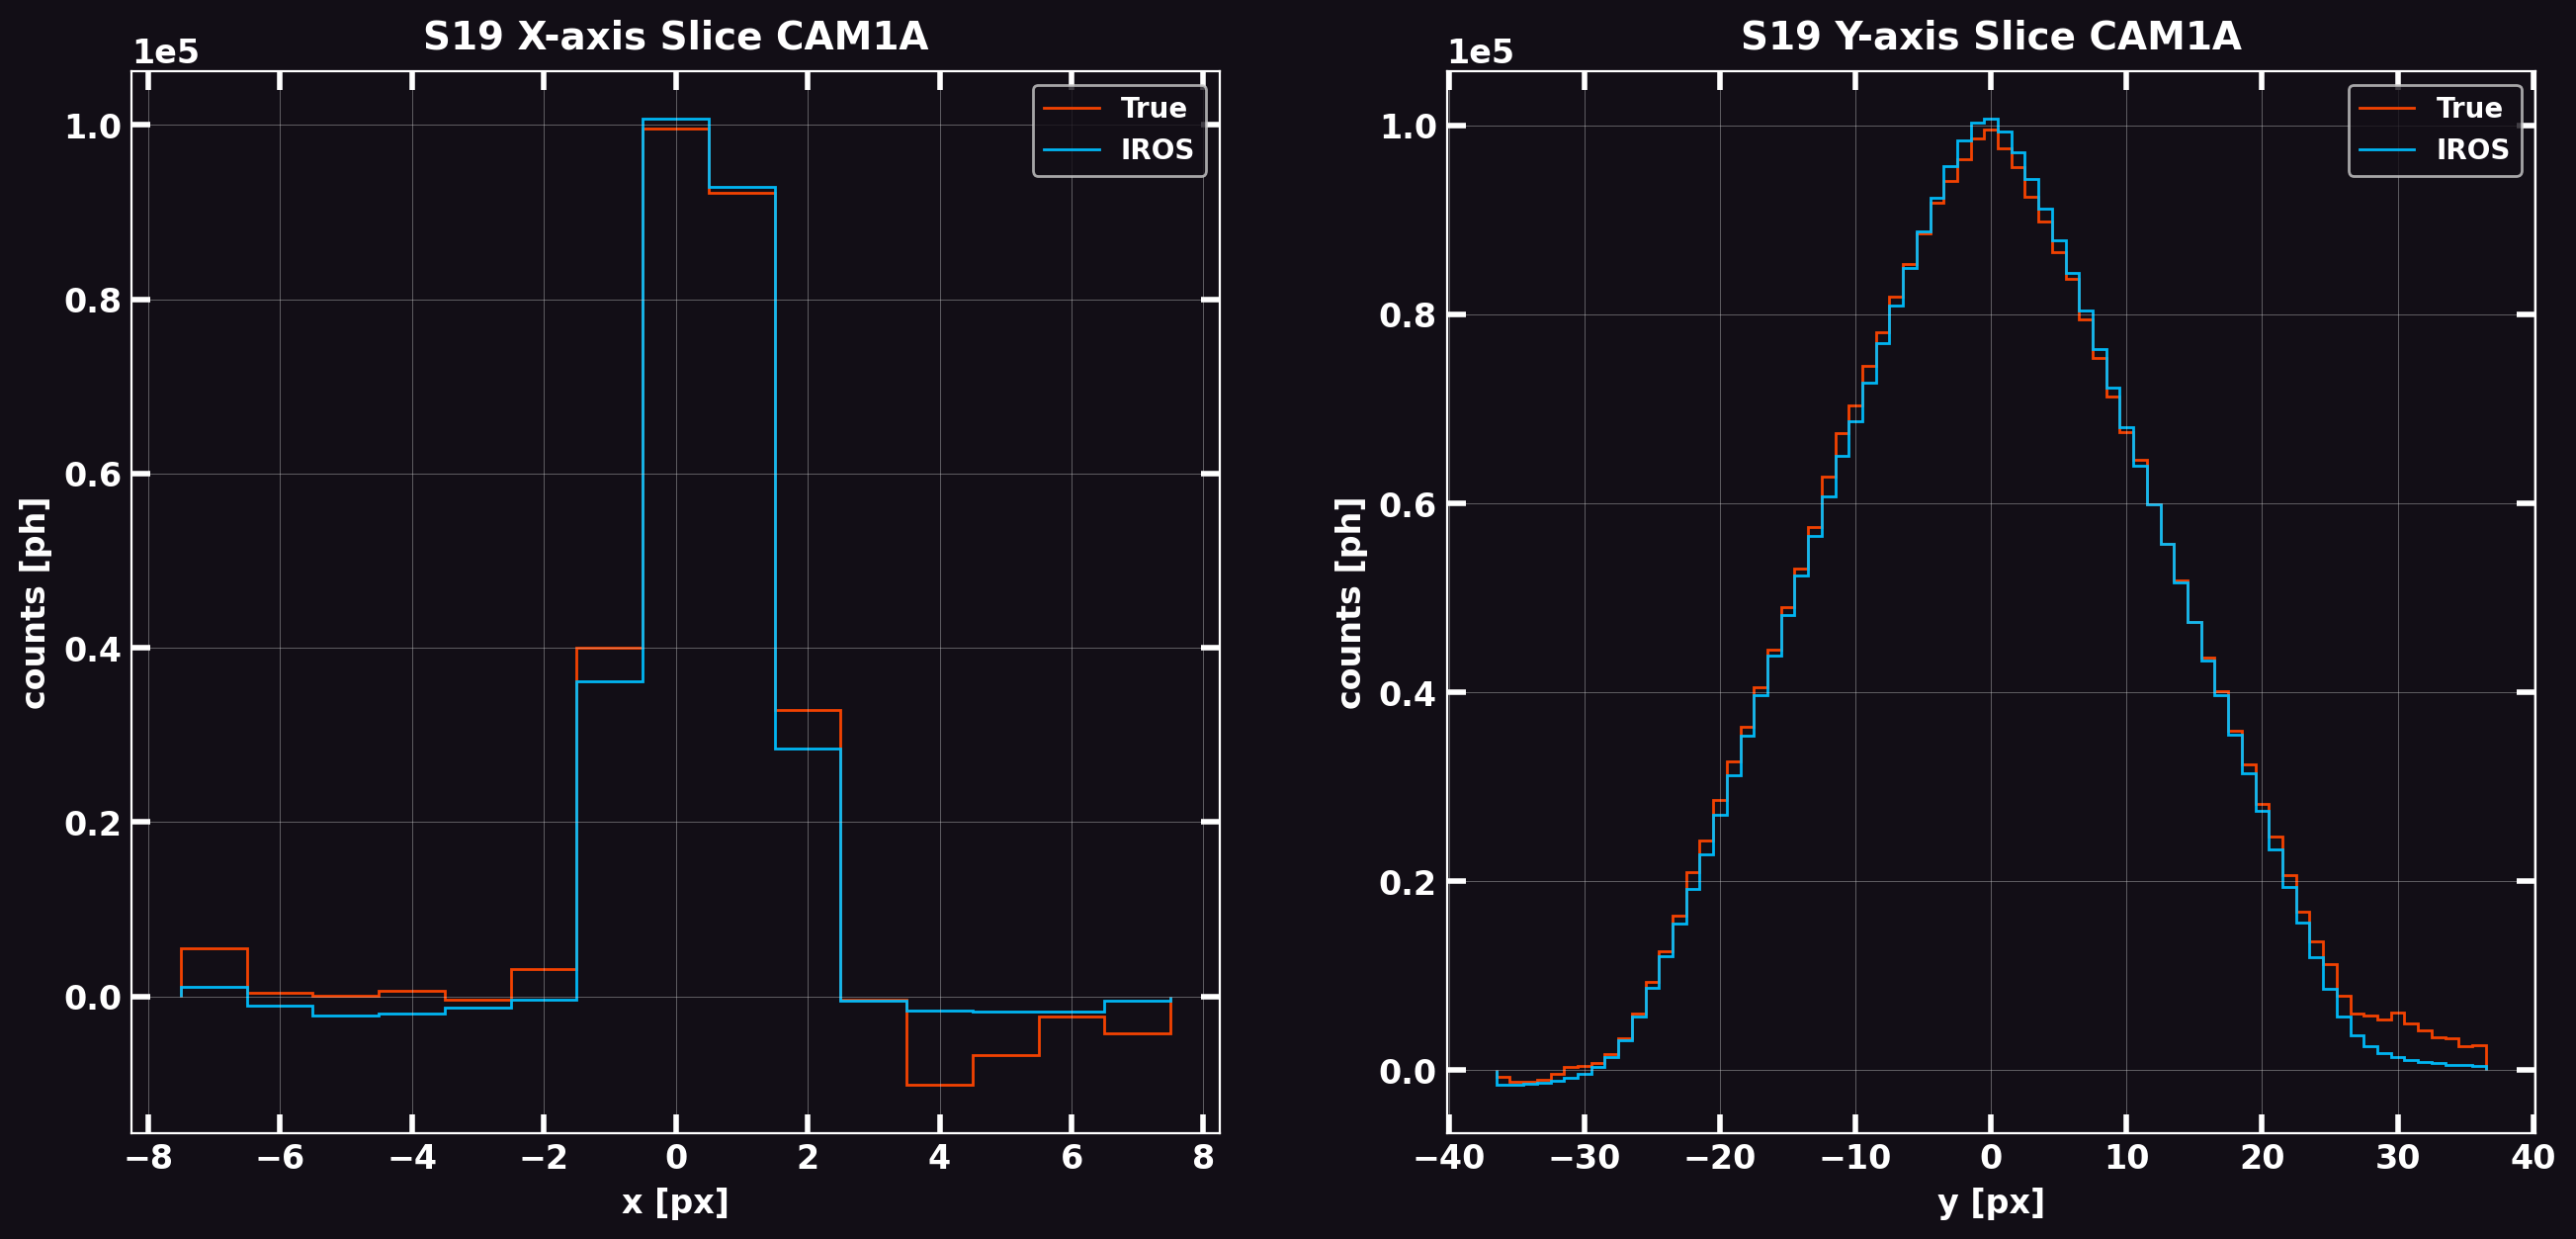

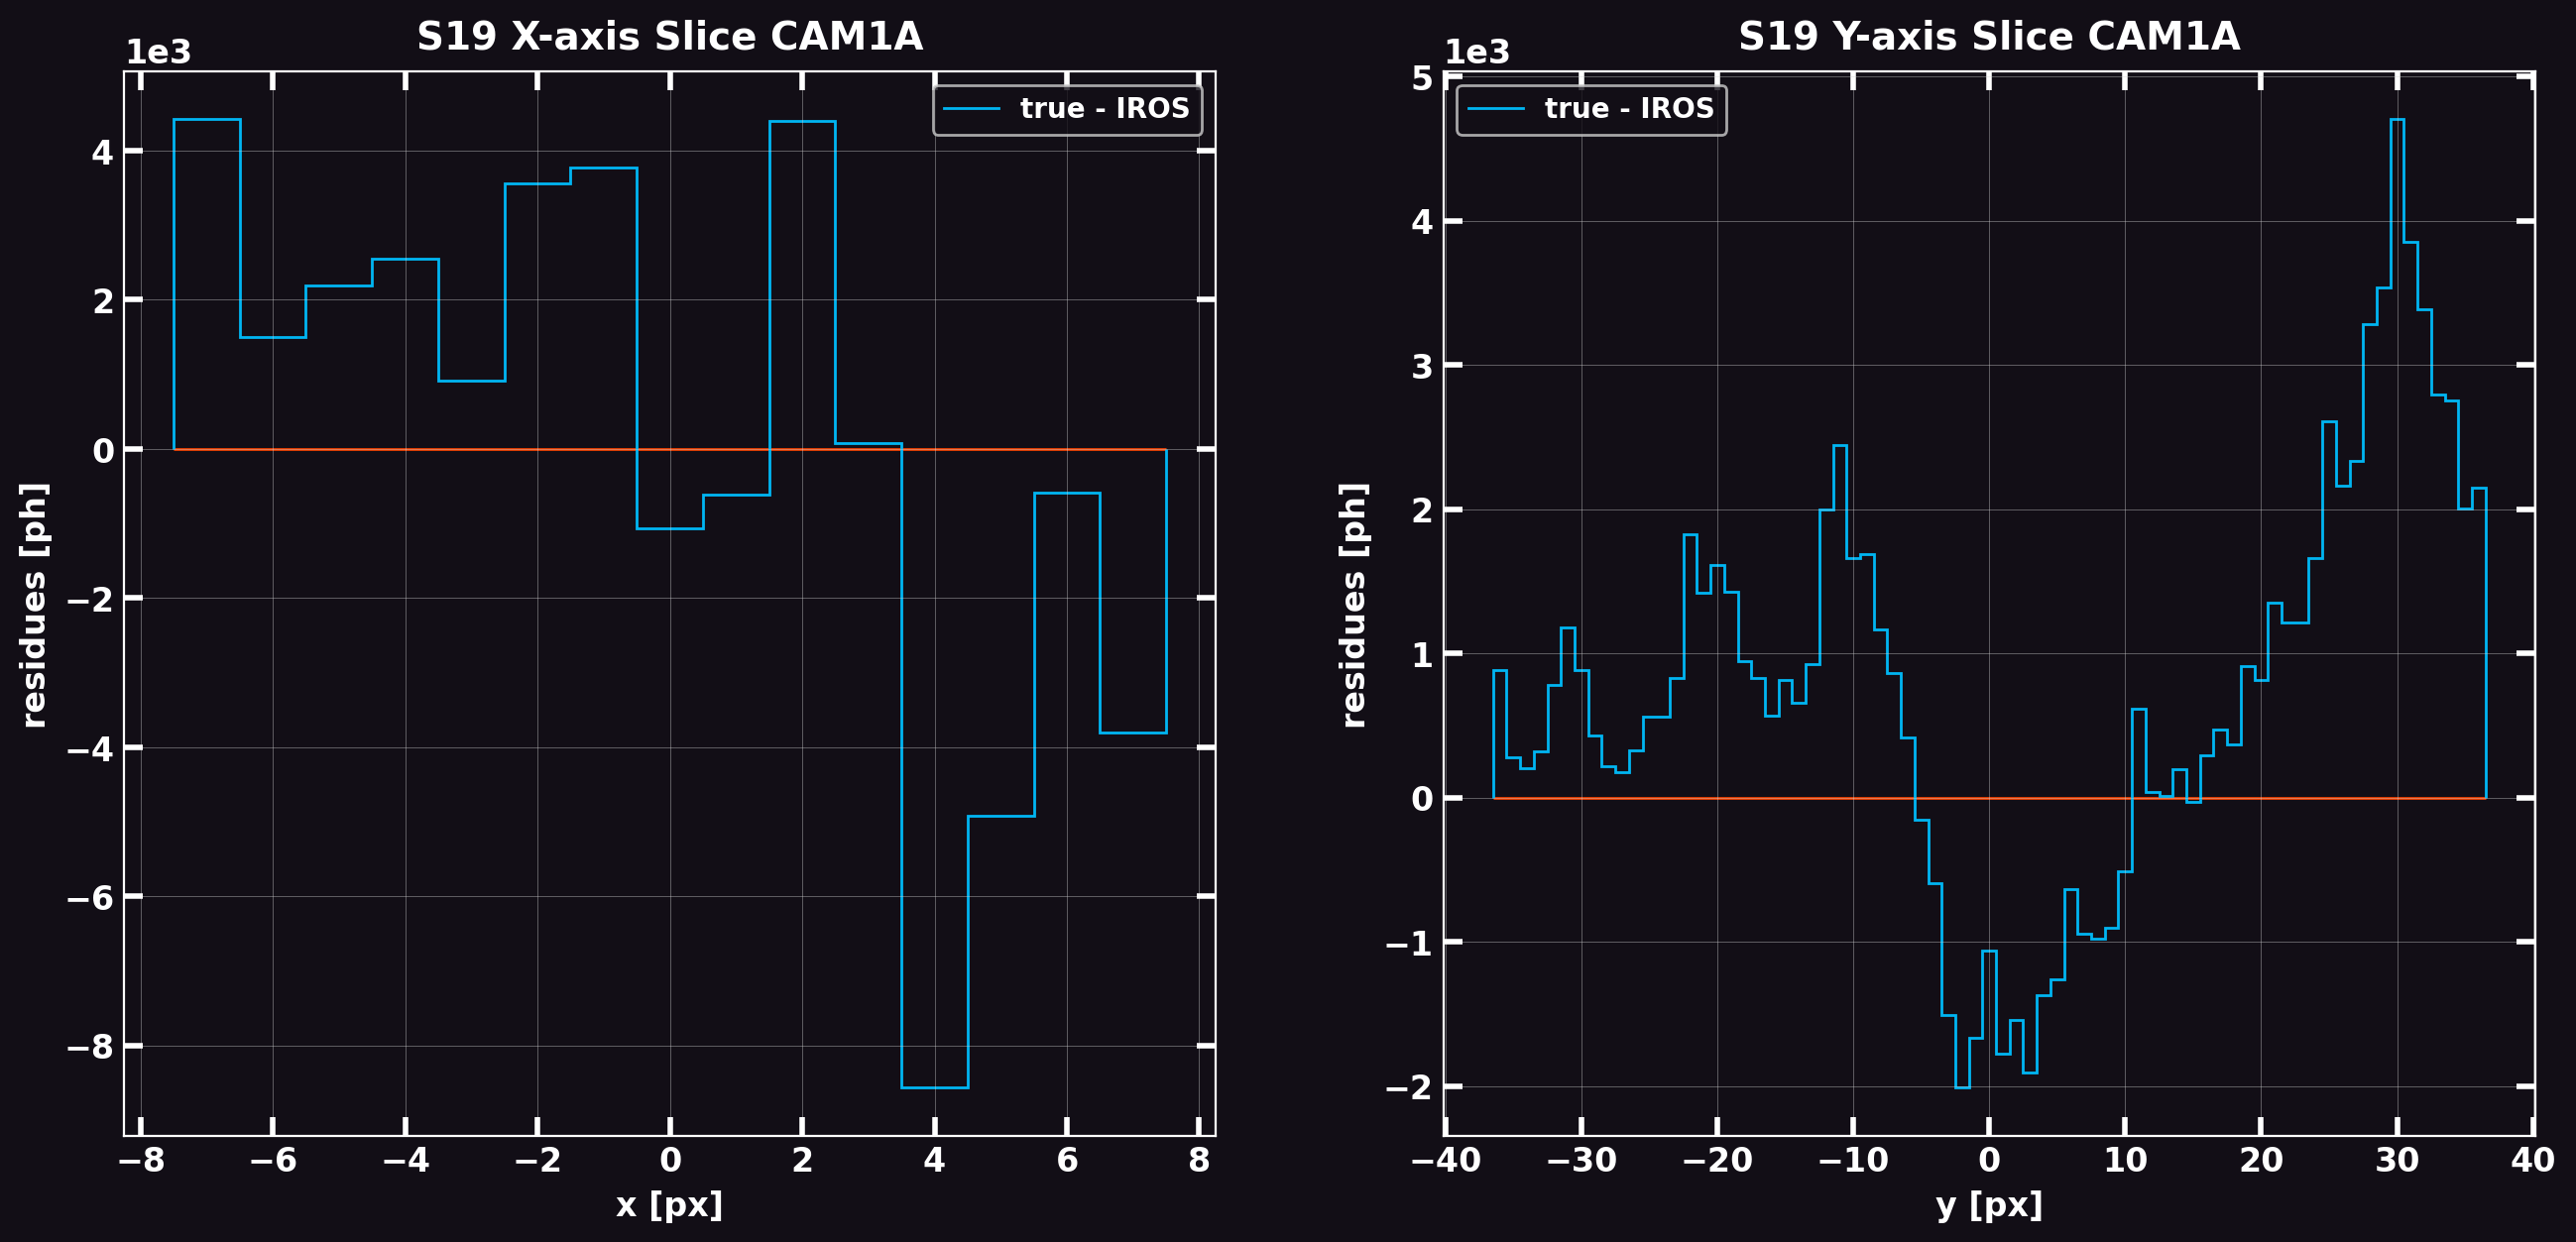

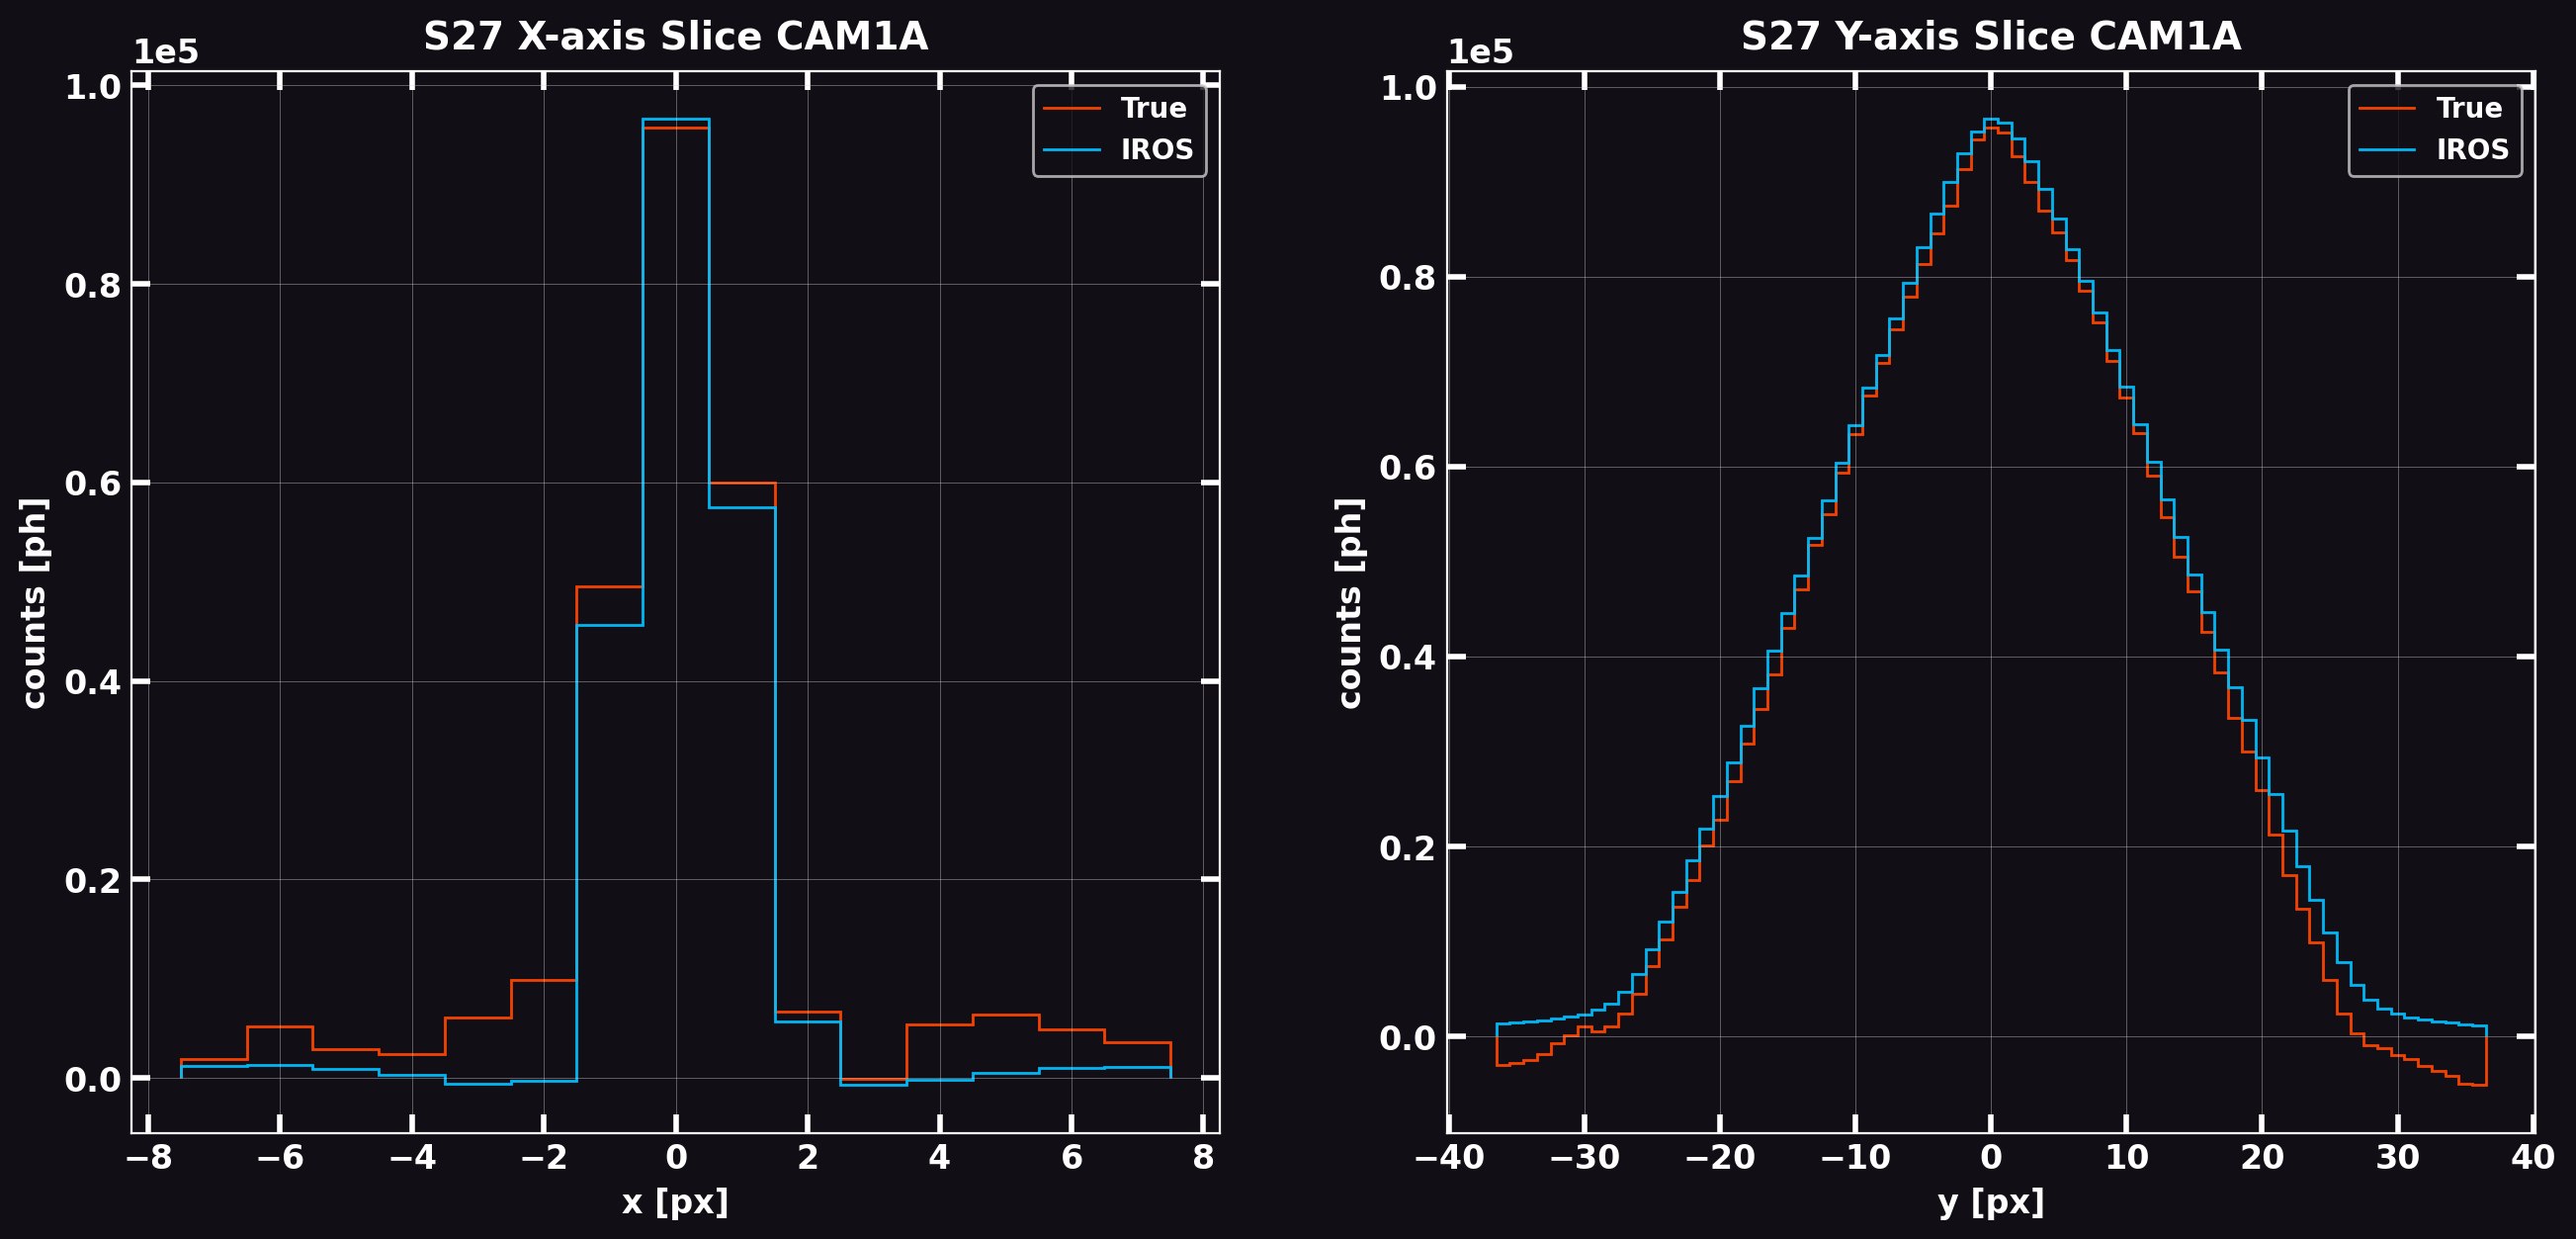

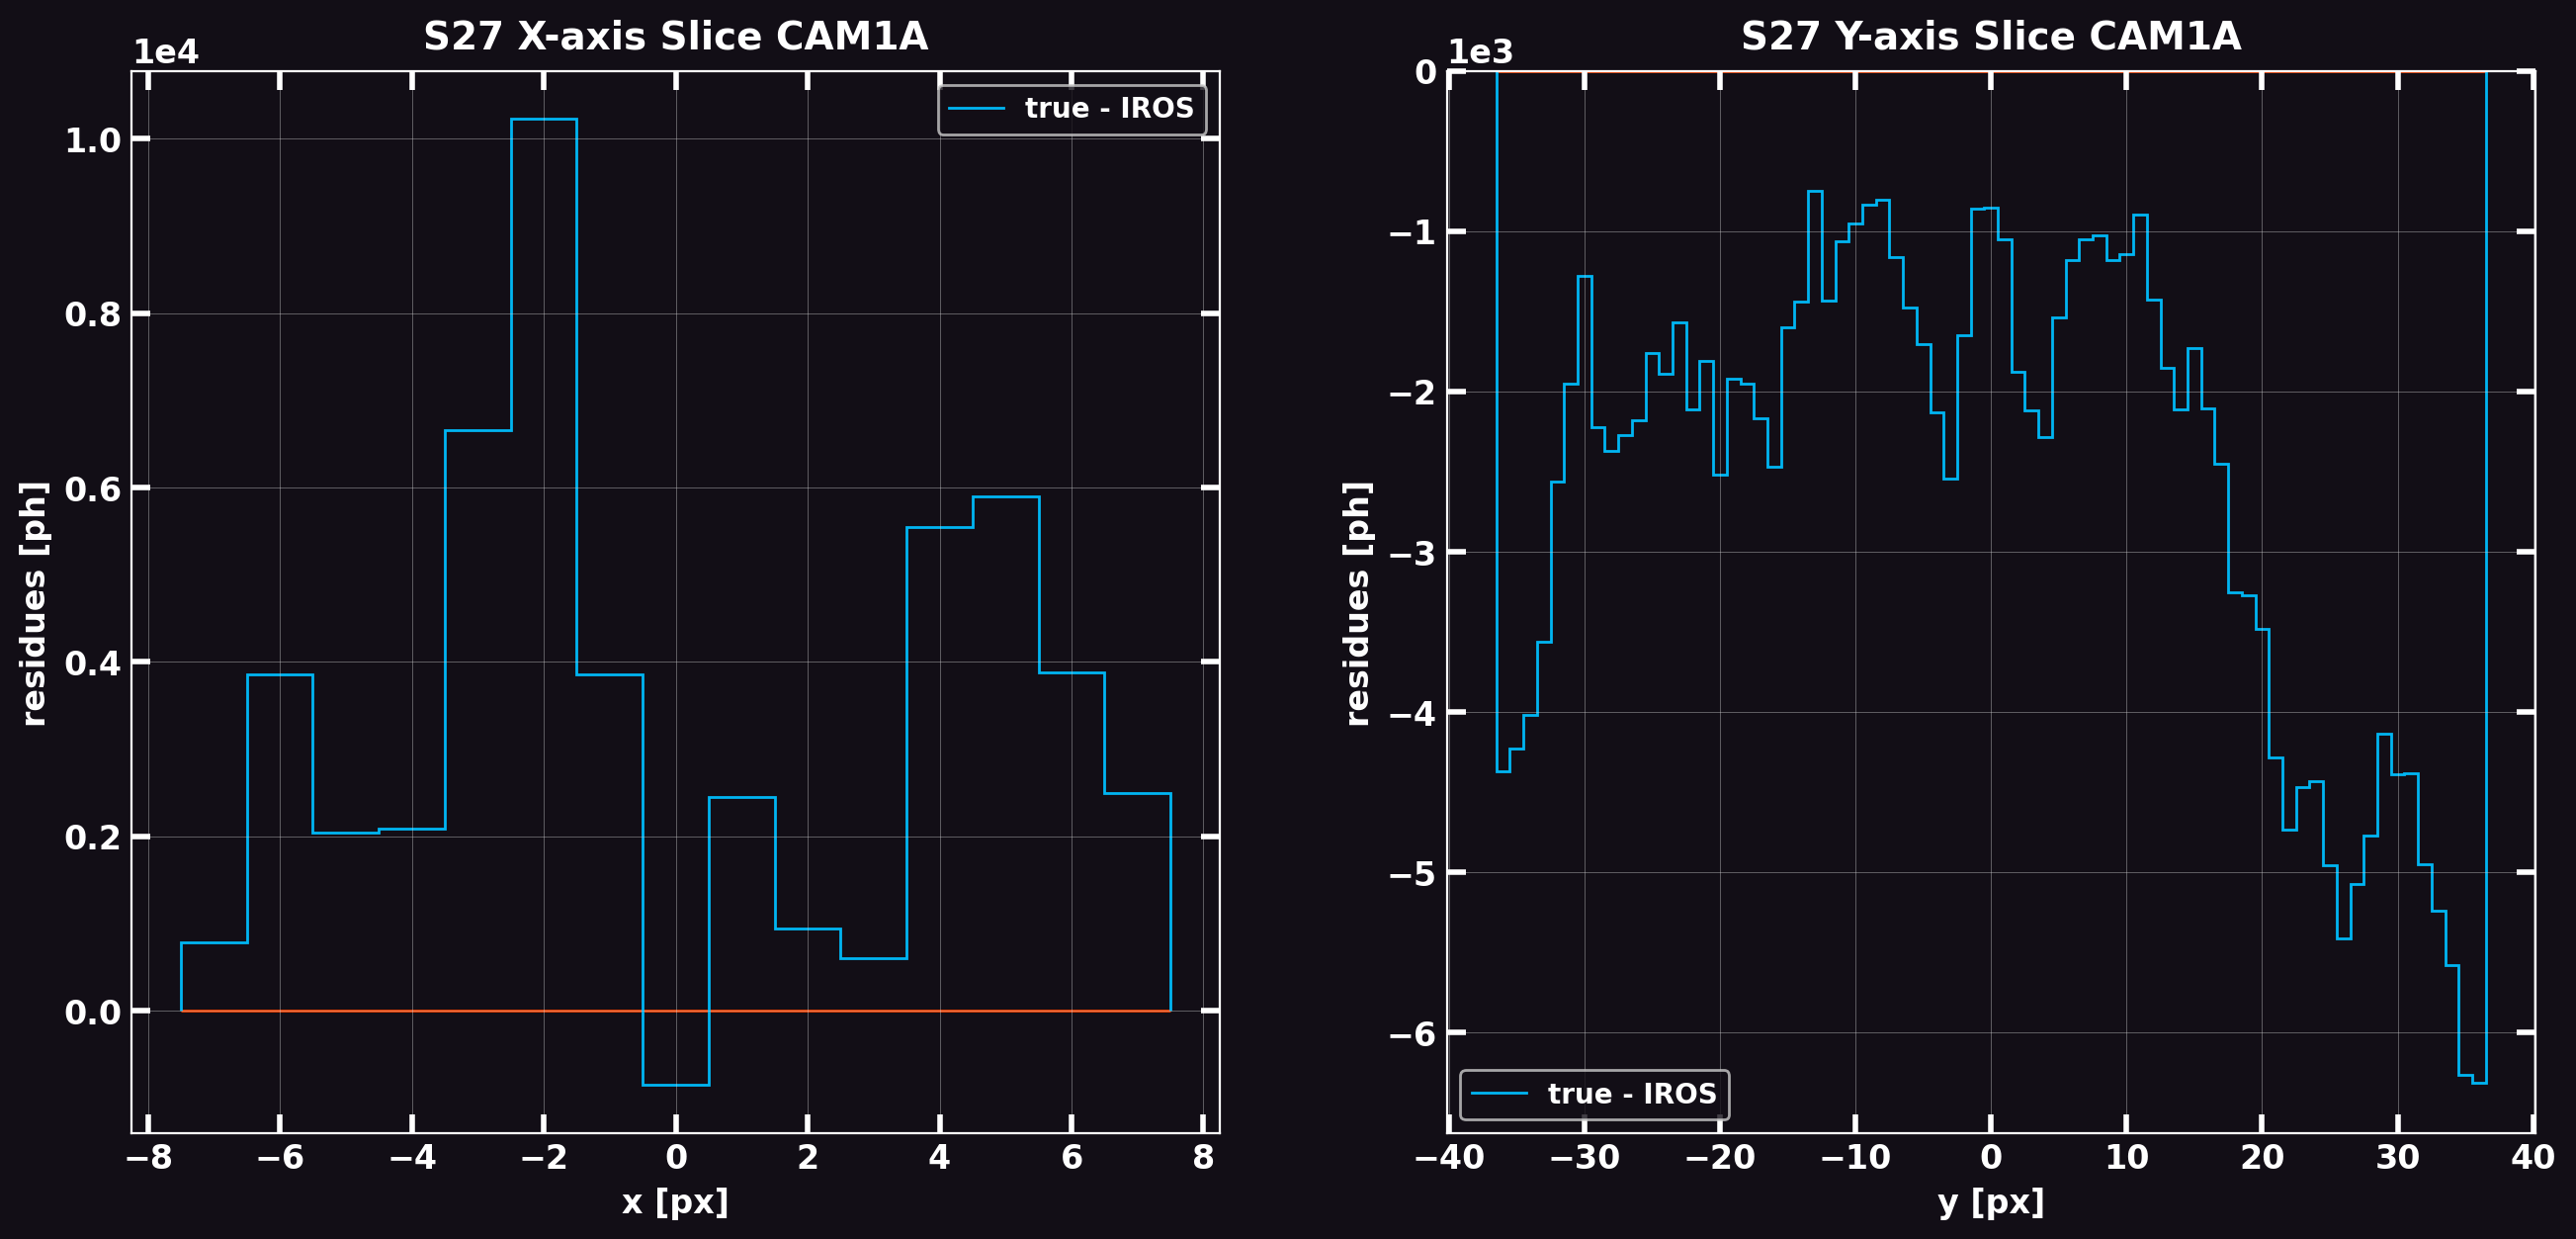

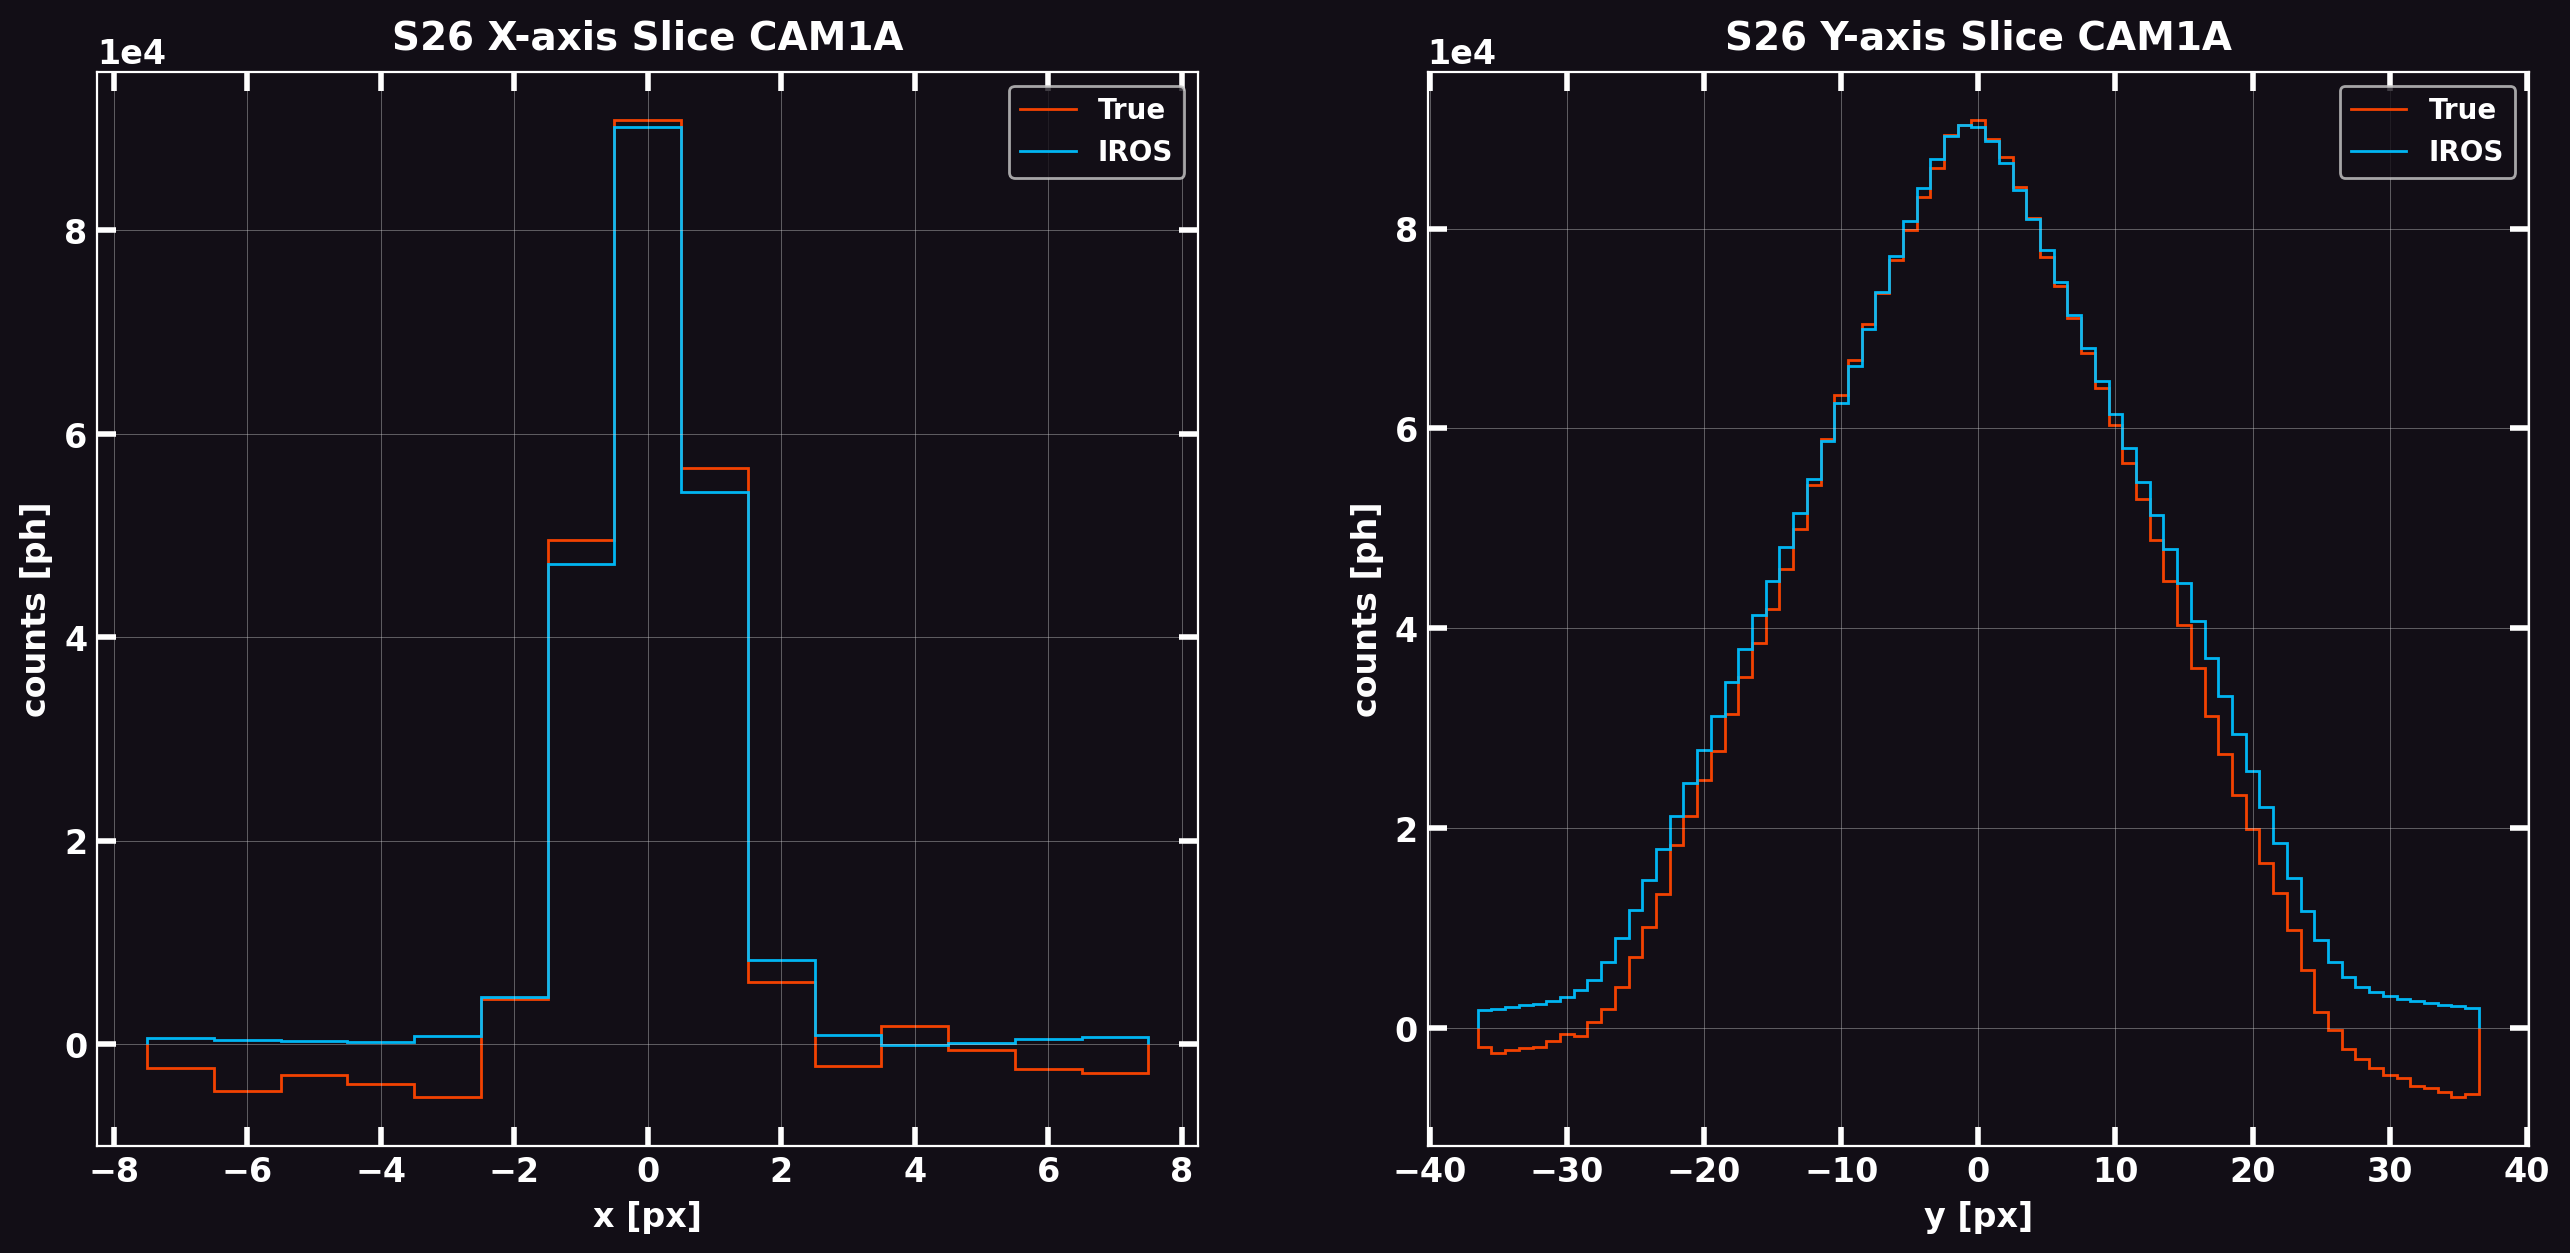

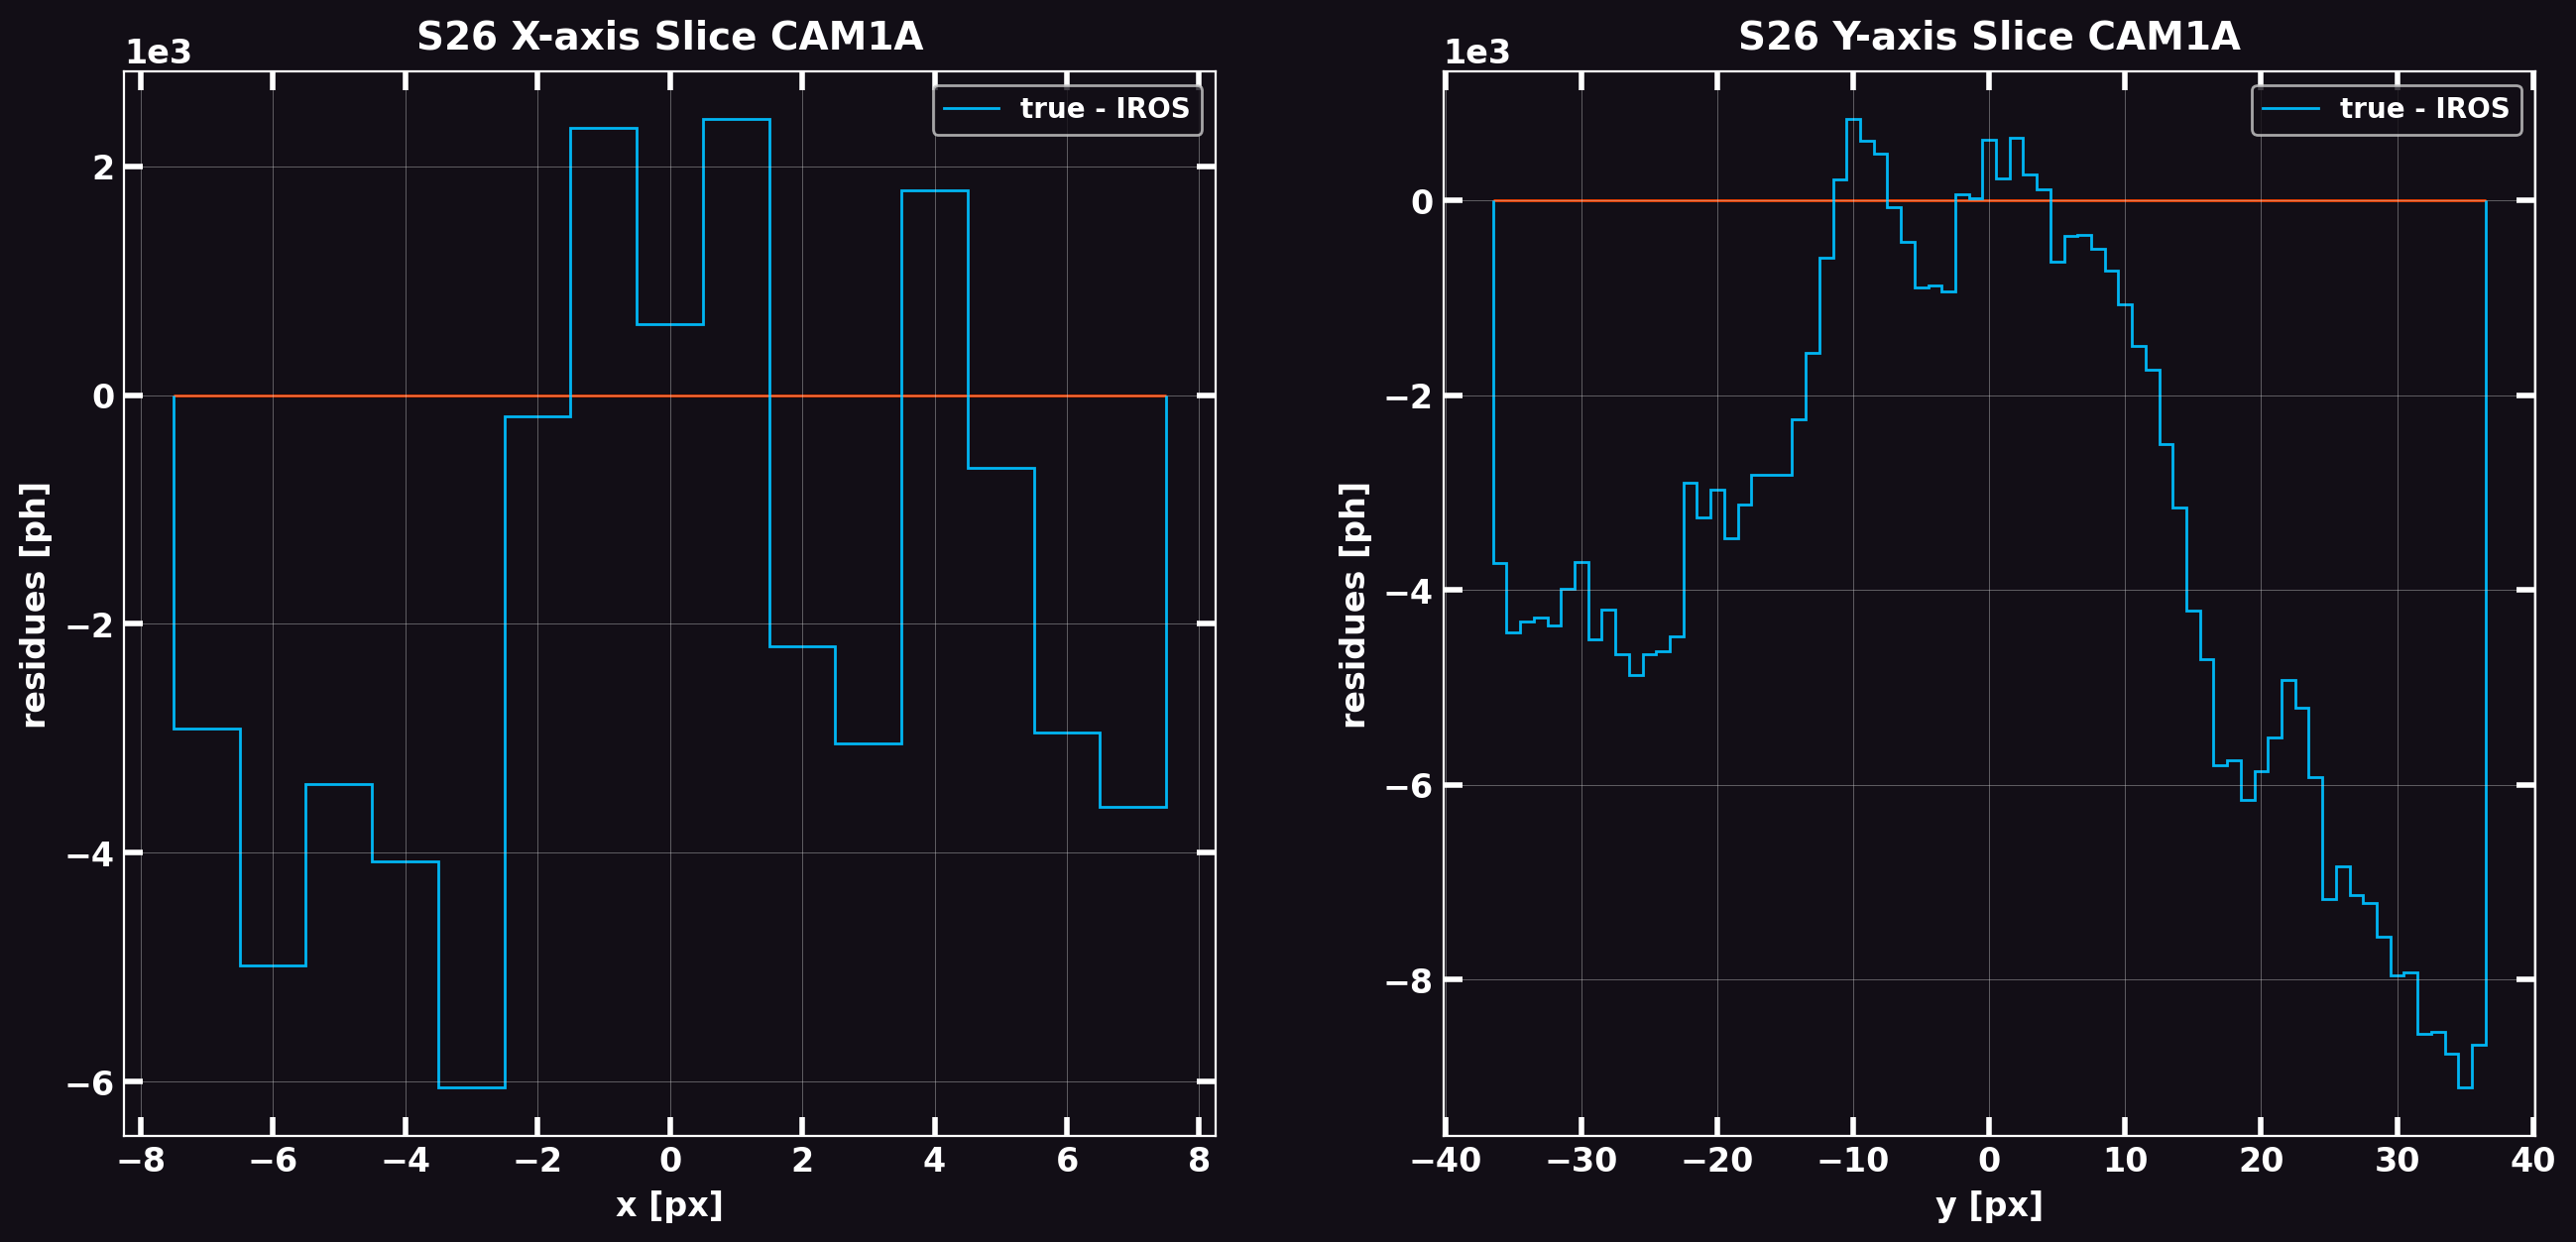

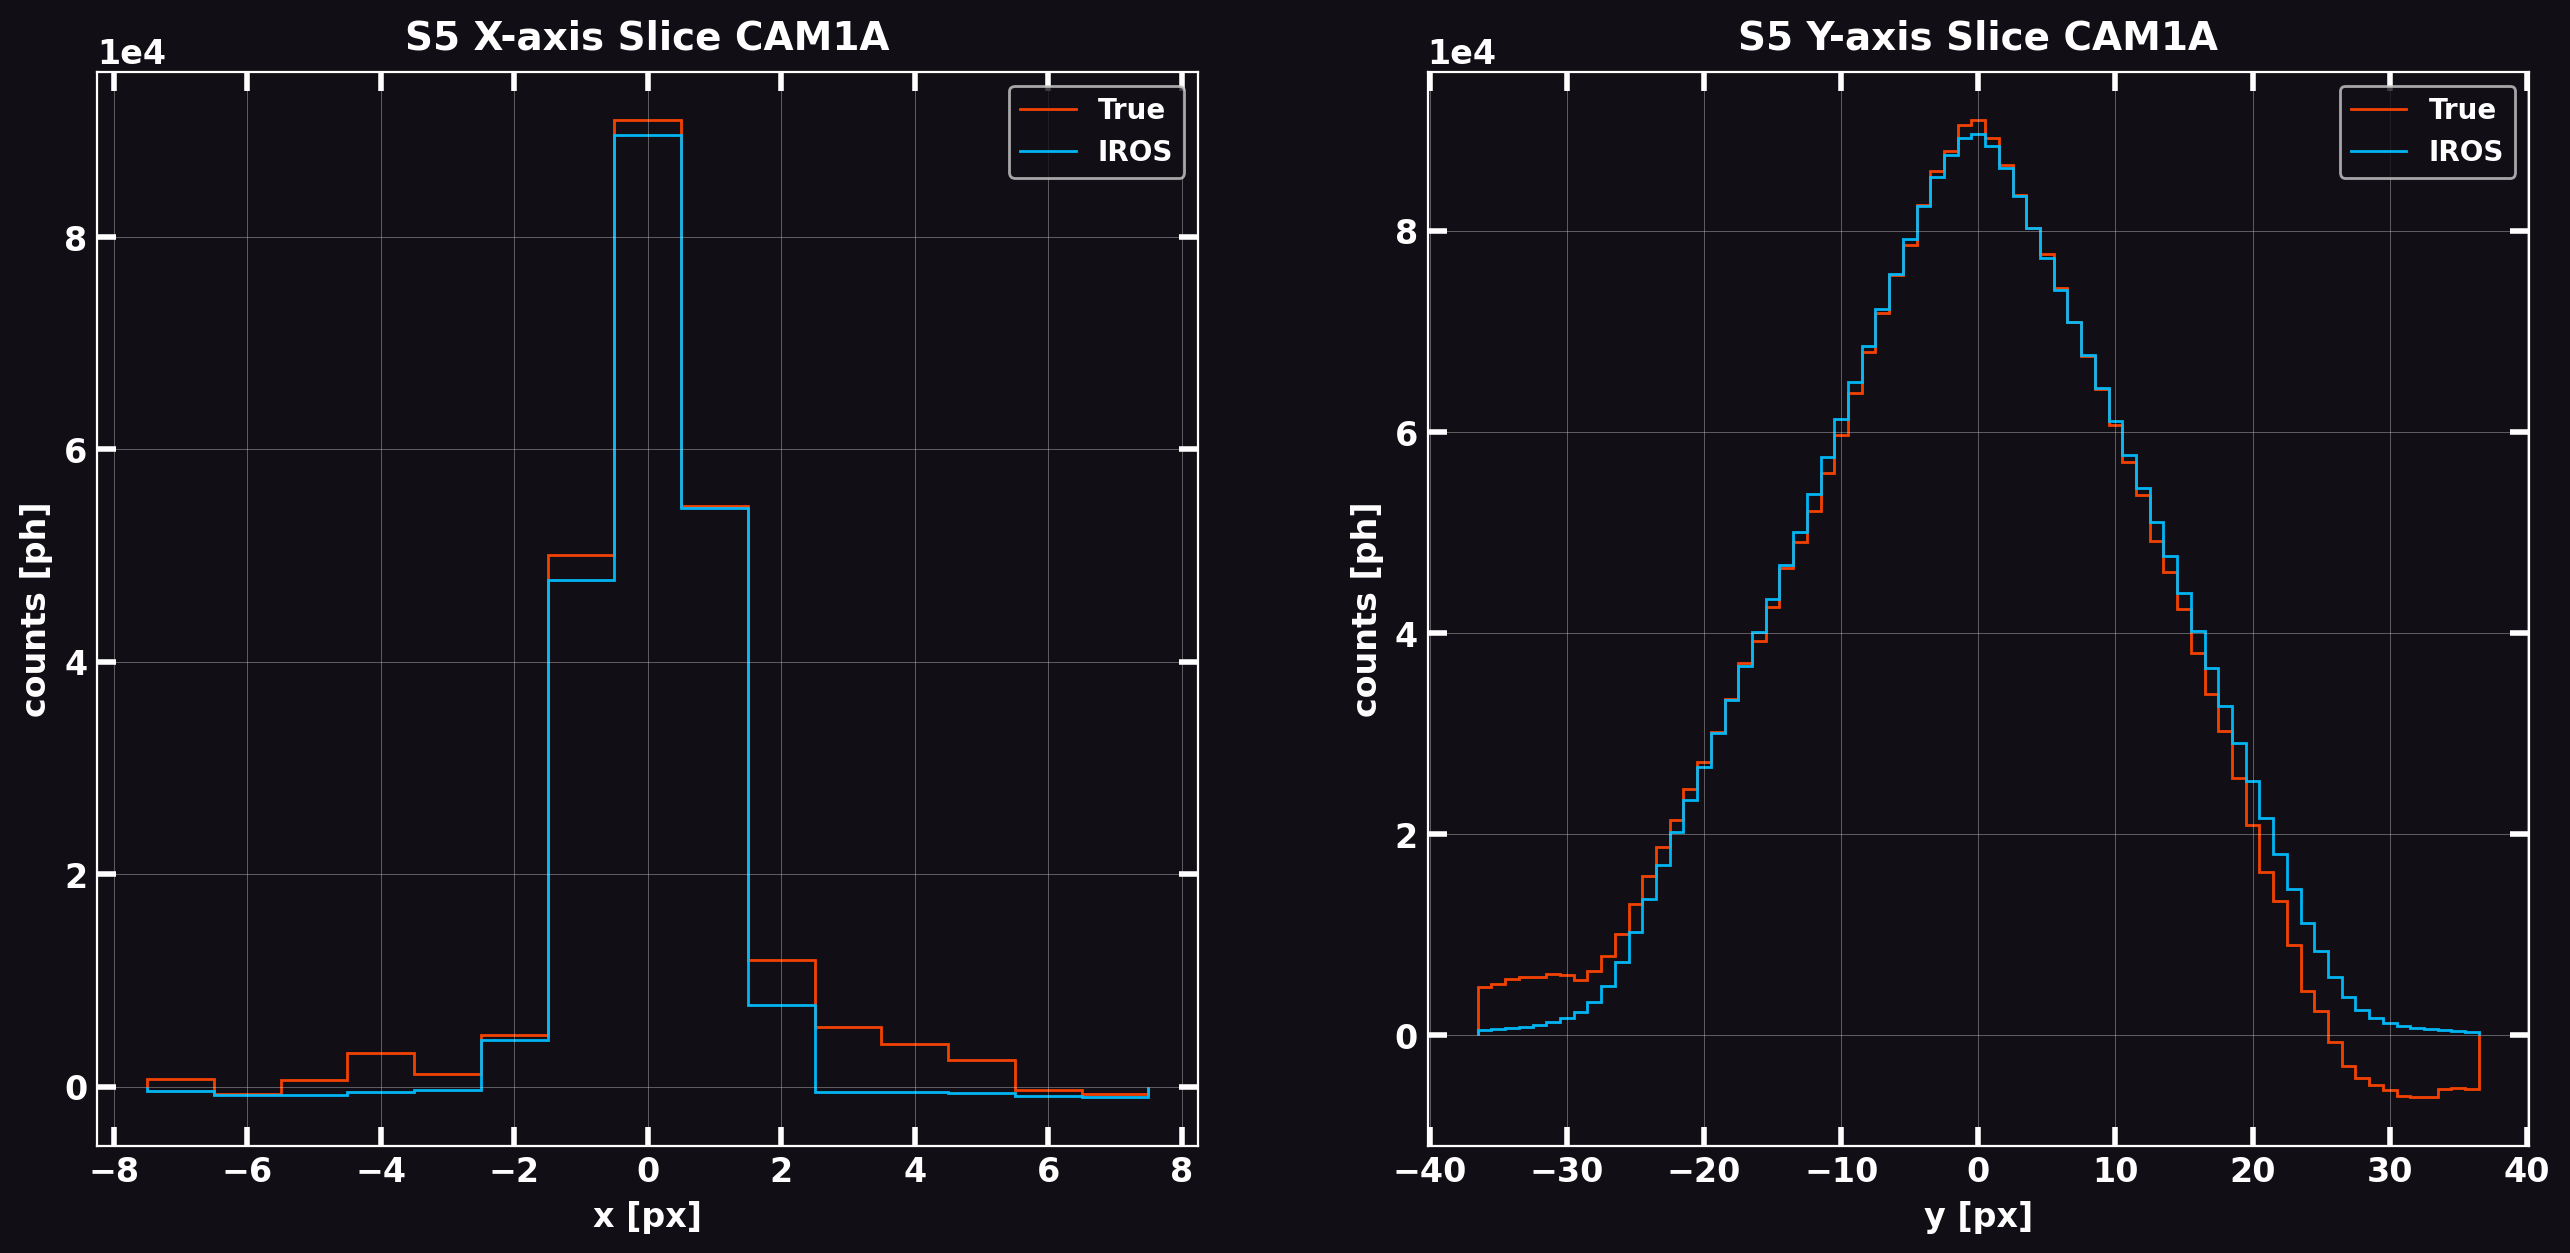

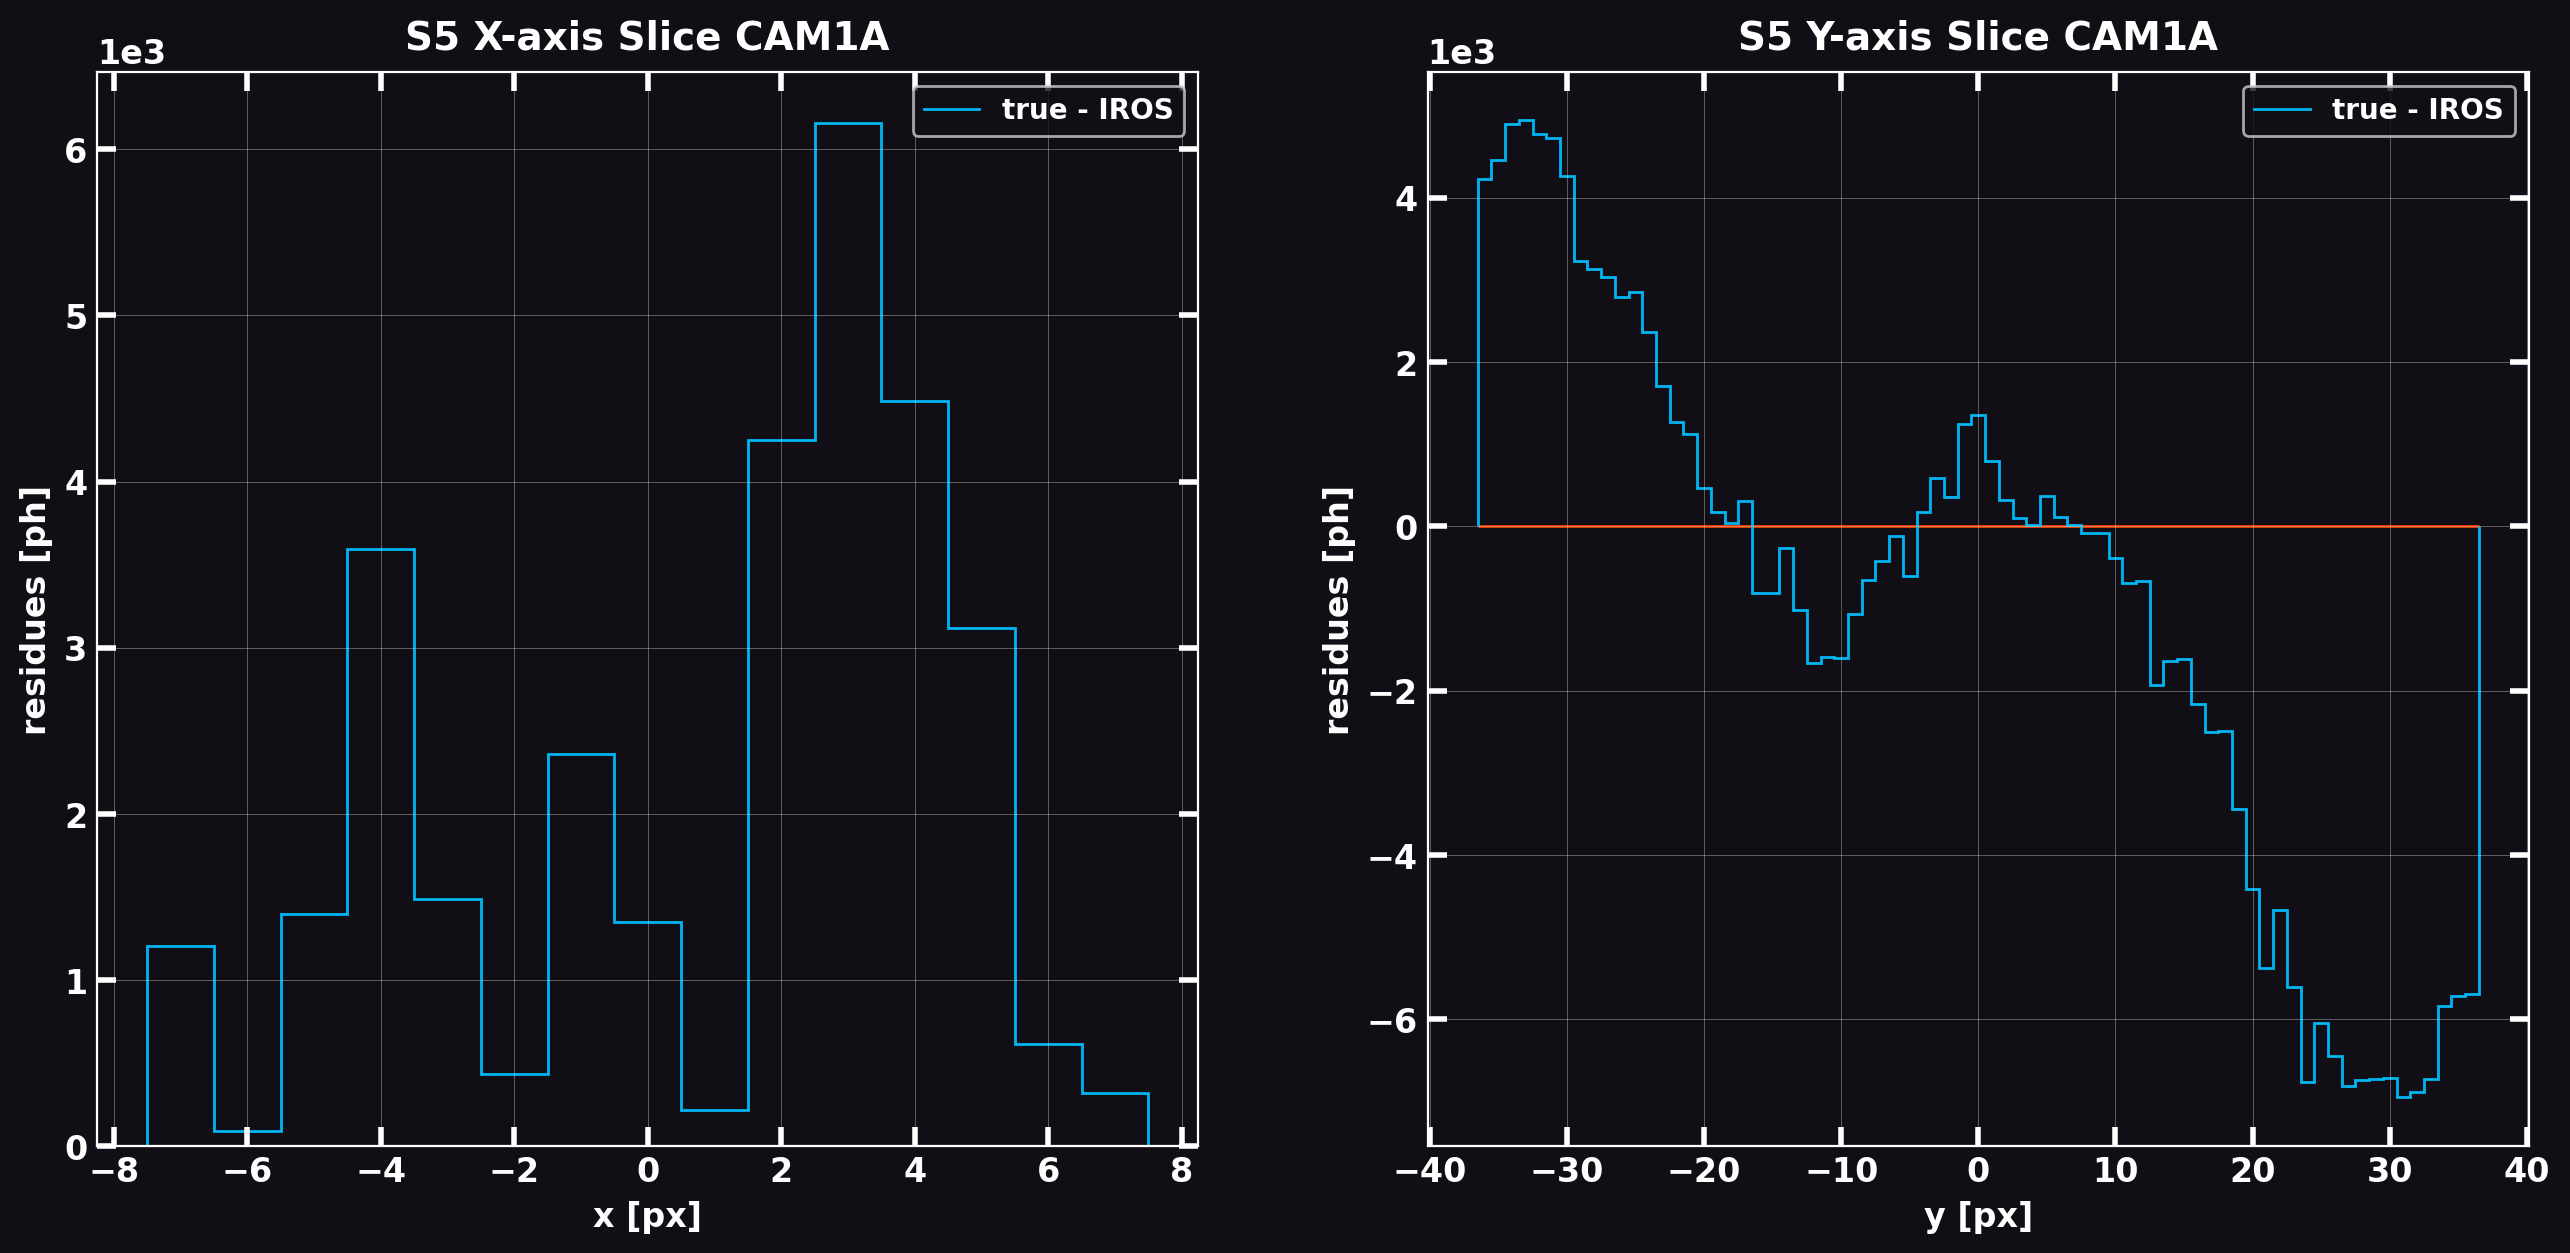

In [15]:
# sources profiles during IROS + residues heatmaps
slit_fine, slit_coarse = ds.psf_extension(wfm)

ds.reconstructed_sources_profiles(
    true_sky=true_sky_camA,
    log=log_camA,
    crp=(slit_coarse + 5, slit_fine + 5),
    camera=wfm,
    vignetting=VIGNETTING,
    psfy=PSFY,
    save_to=SAVE_TO if SAVE_THINGS else None,
)

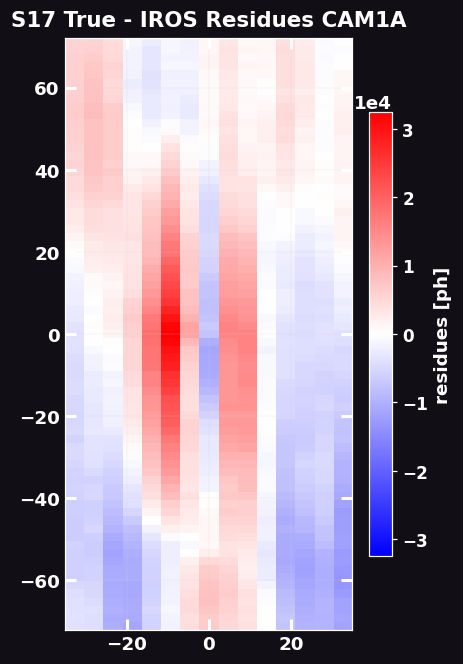

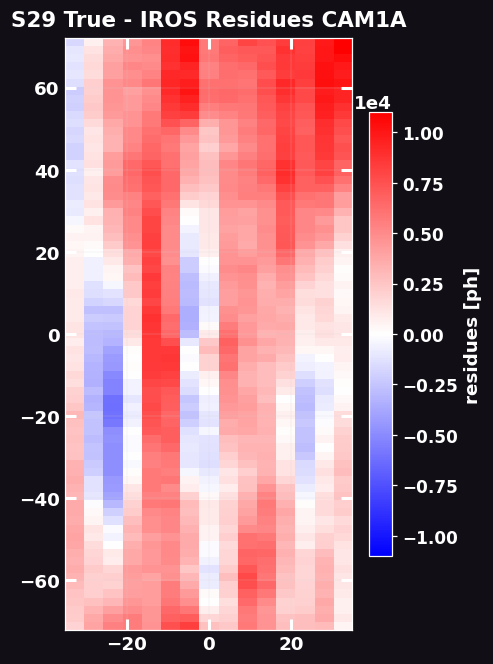

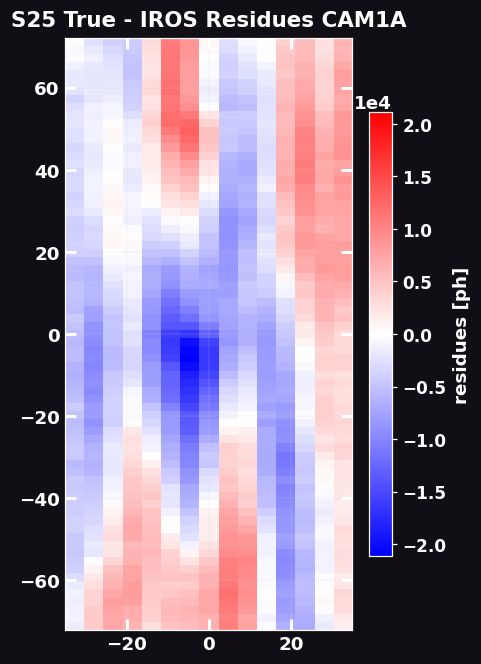

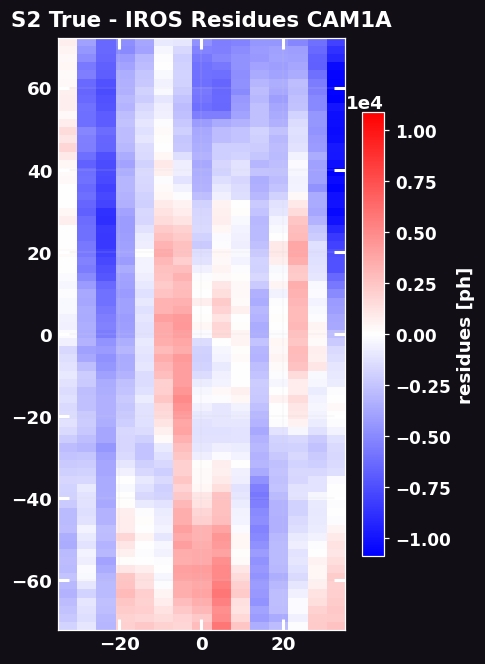

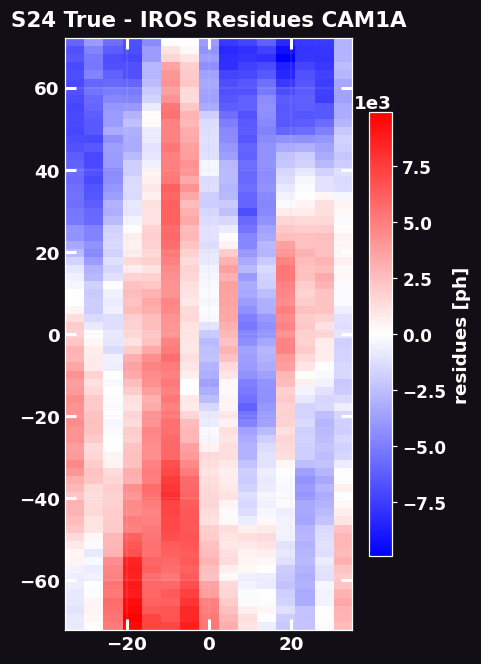

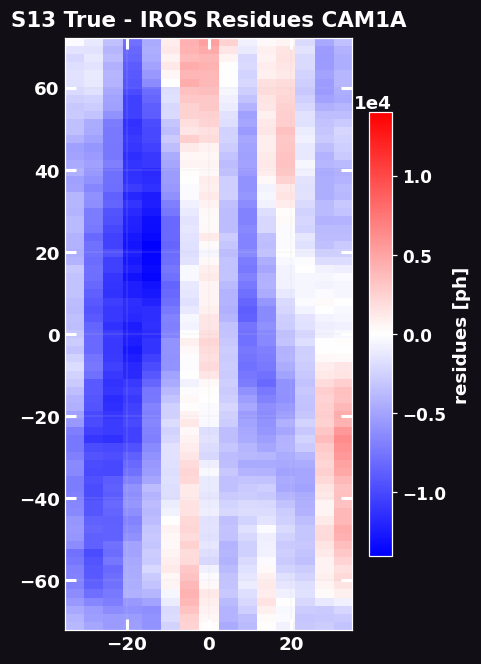

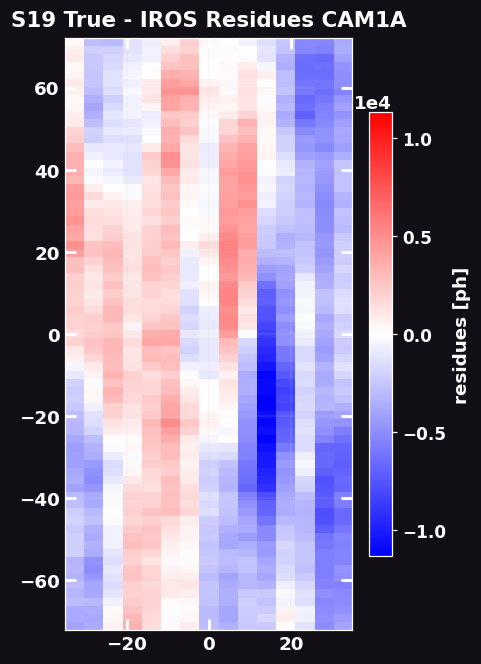

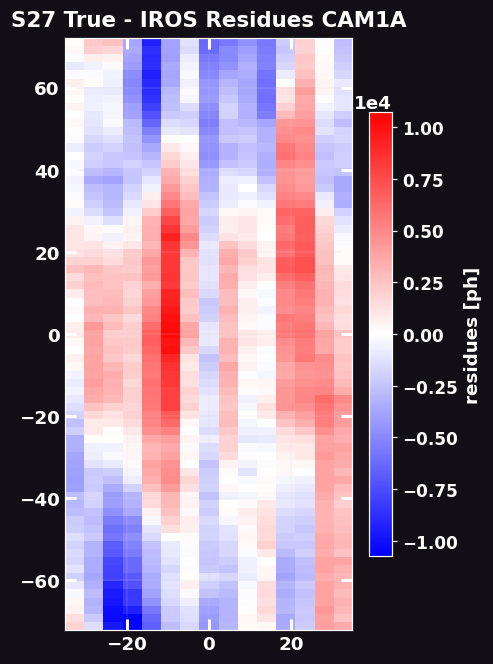

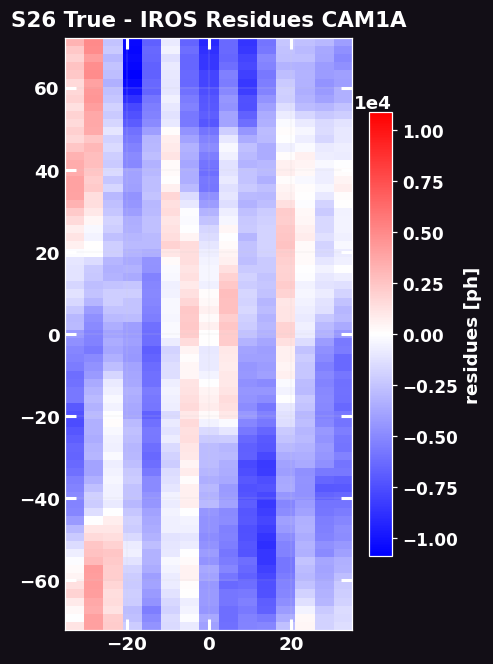

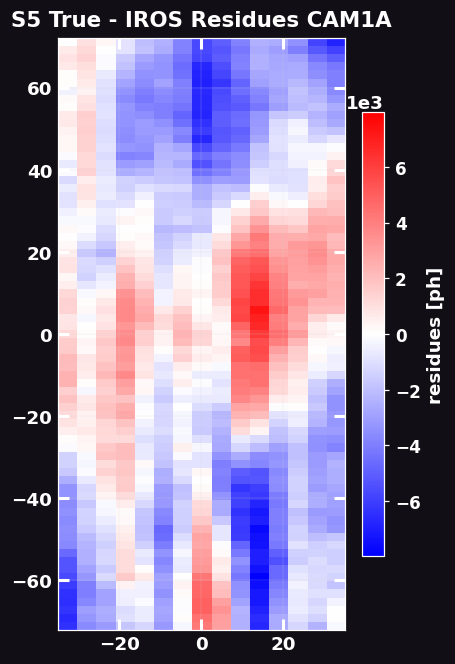

In [16]:
ds.reconstruction_sources_heatmaps(
    true_sky=true_sky_camA,
    log=log_camA,
    crp=(slit_coarse + 5, slit_fine + 5),
    camera=wfm,
    vignetting=VIGNETTING,
    psfy=PSFY,
    save_to=SAVE_TO if SAVE_THINGS else None,
)

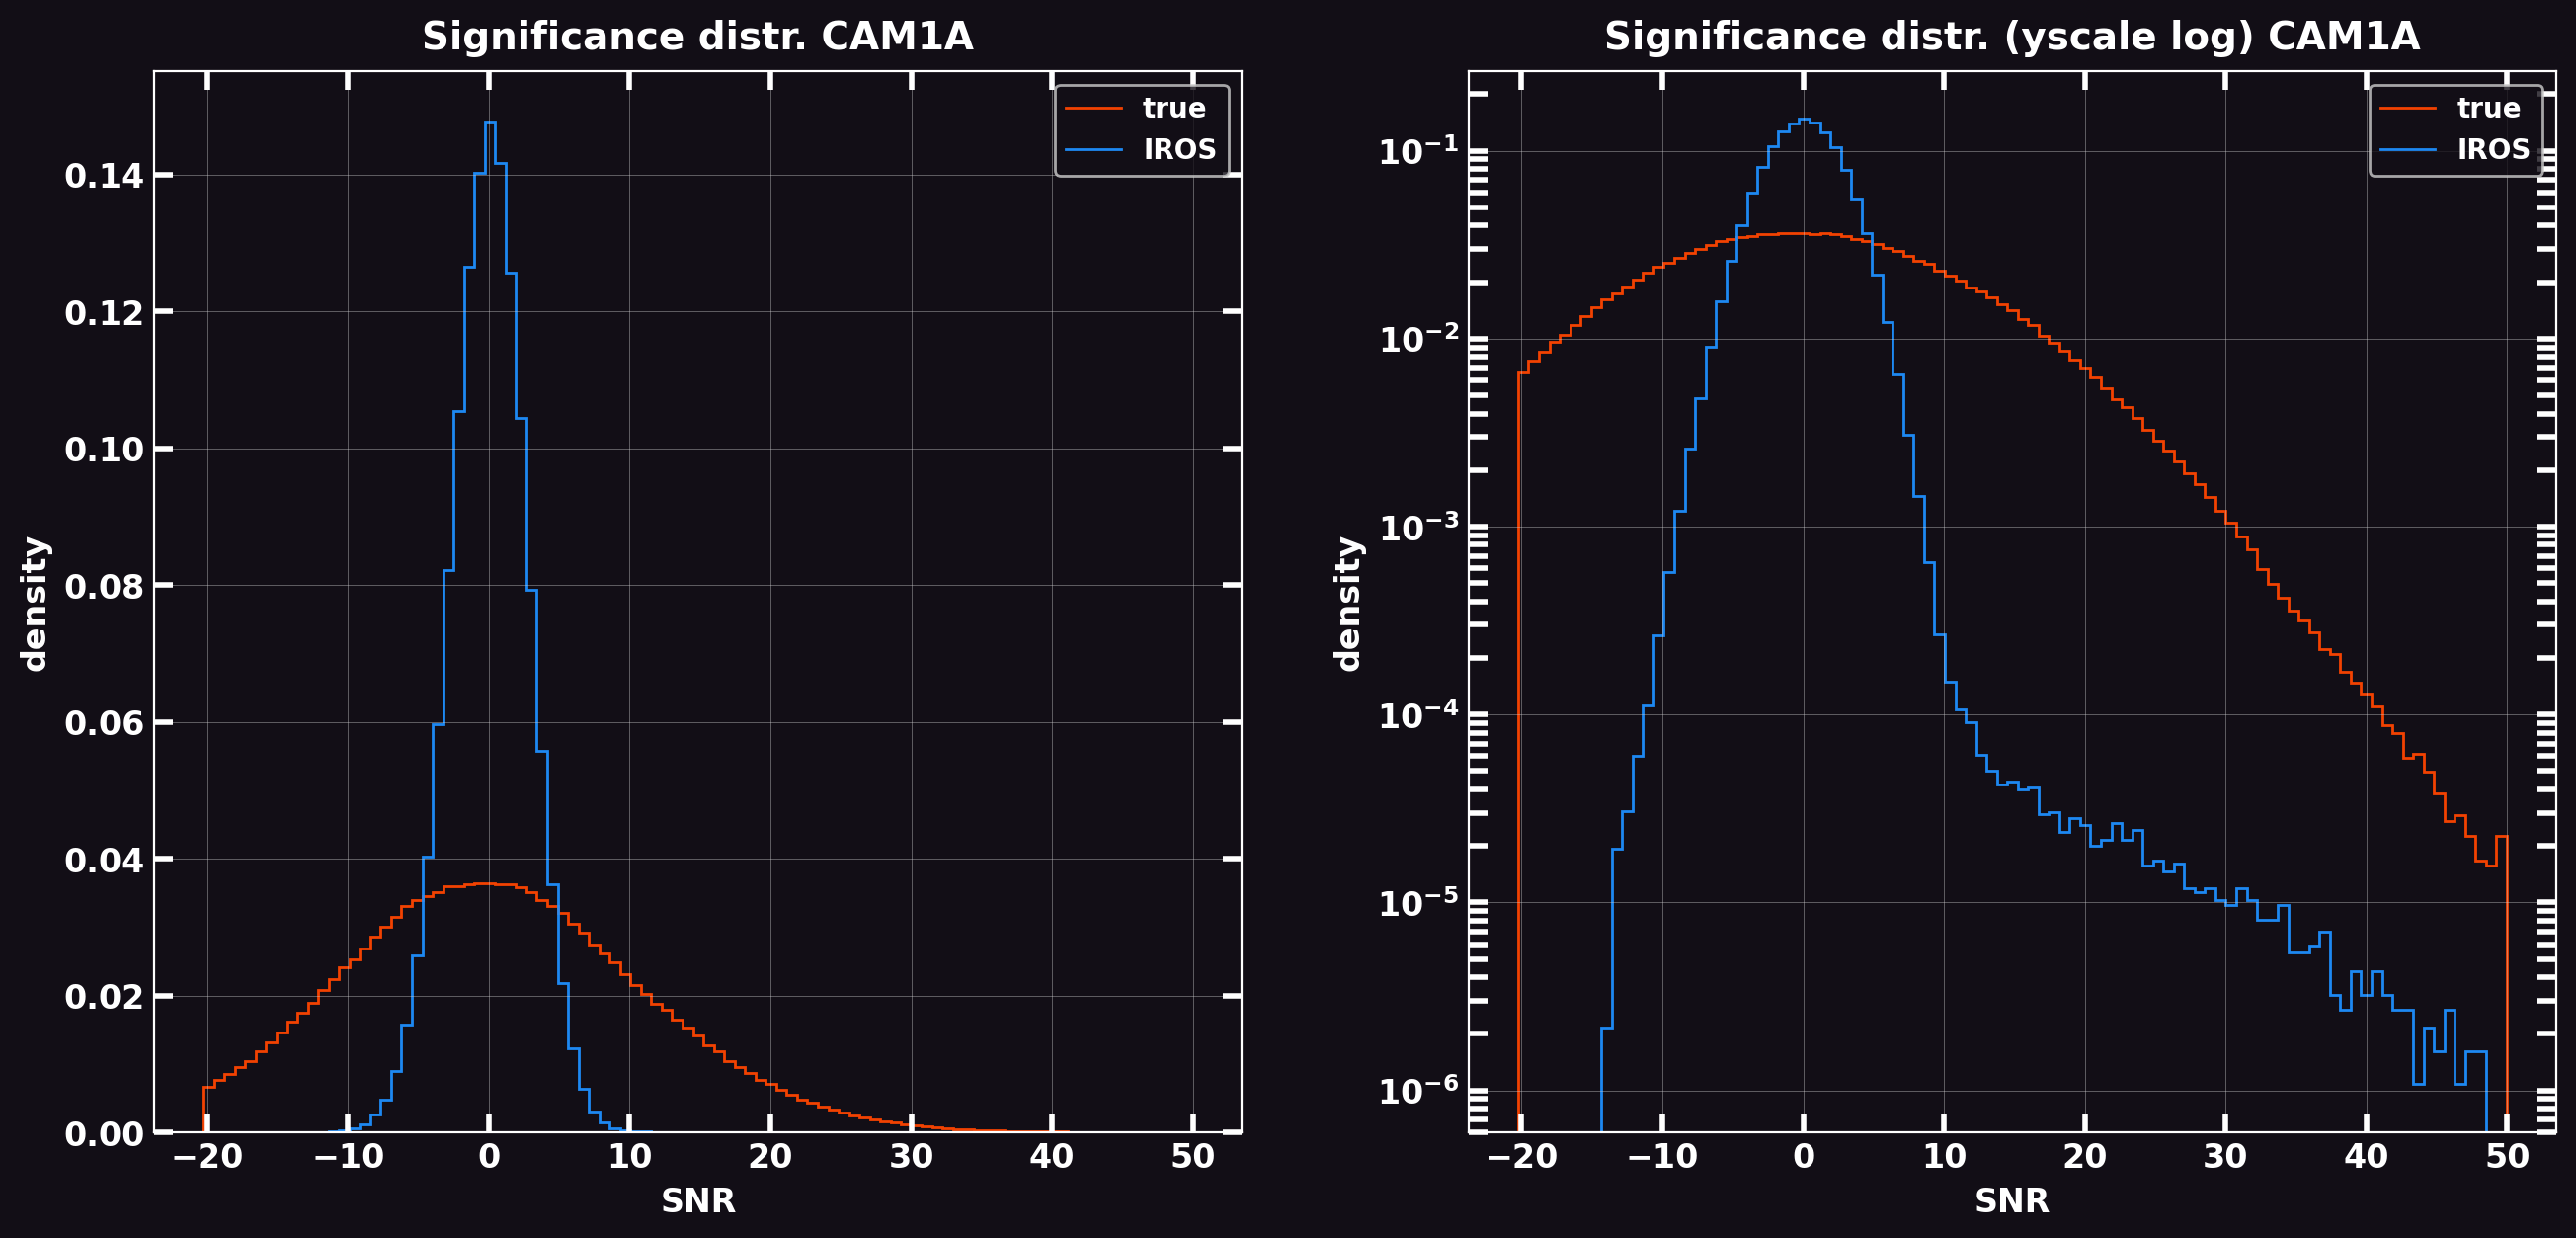

In [17]:
# sky significance distr. for true sky and at the last IROS iteration
detector_camA = count(wfm, sdlA.DLdata)[0]
varmap = variance(wfm, detector_camA)

ycut, xcut = UPS_Y * 30, UPS_X * 20
true_skysnr_camA = ds.unframe(snratio(true_sky_camA, varmap), ycut, xcut)
res_skysnr_camA = ds.unframe(snratio(res_sky_camA, varmap), ycut, xcut)

num_bins = 1000
density = True
hist_true_skysnr, bins = np.histogram(true_skysnr_camA, bins=num_bins, density=density)
hist_res_skysnr, _ = np.histogram(res_skysnr_camA, bins=bins, density=density)


x0, xN = -20, 50
bins_slice, hist_slice = ds.config_distr_limits(bins, x0, xN)

dmap1_snr = ds.map4plot(
    arrs=(hist_true_skysnr[hist_slice], hist_res_skysnr[hist_slice]),
    title=f'Significance distr. {ID_CAMERA_A.upper()}',
    xlabel='SNR',
    ylabel='density',
    labels=('true', 'IROS'),
    x=bins[bins_slice],
    style='stairs',
    color=('OrangeRed', 'Dodgerblue'),
)
dmap2_snr = ds.map4plot(
    arrs=(hist_true_skysnr[hist_slice], hist_res_skysnr[hist_slice]),
    title=f'Significance distr. (yscale log) {ID_CAMERA_A.upper()}',
    xlabel='SNR',
    ylabel='density',
    labels=('true', 'IROS'),
    x=bins[bins_slice],
    style='stairs',
    color=('OrangeRed', 'Dodgerblue'),
    yscale='log',
)
ds.plot(
    dmaps=(dmap1_snr, dmap2_snr),
    ncols=2,
    save_to=(
        savefile_to(SAVE_TO, f'snr_distr_{ID_CAMERA_A.upper()}')
        if SAVE_THINGS else None
    ),
)

**Analysis for LEM-X Camera B**

In [18]:
assert ANALYSIS_CAM1B

AssertionError: 

In [ ]:
angular_coords = extract_catalogue_angular_coords(log_camB, catalogueB, sdlB, wfm)
cat_theta_x, cat_theta_y = map(
    np.array, (angular_coords['angle_x'], angular_coords['angle_y']),
)

theta_res_x, theta_res_y = get_angularcoords_residues(
    log=log_camB,
    catalogue=catalogueB,
    sdl=sdlB,
    camera=wfm,
)

tags_x = tuple(
    Tag(name, res, theta) for name, res, theta in zip(
        log_camB.log['ID'], theta_res_x, cat_theta_x,
    )
)
tags_y = tuple(
    Tag(name, res, theta) for name, res, theta in zip(
        log_camB.log['ID'], theta_res_y, cat_theta_y,
    )
)
dmapx = ds.map4plot(
    arrs=theta_res_x,
    title=f'{log_camB.name} X-Axis Angular Residues (abs values)',
    xlabel='$\\theta_{{x}}$ off-axis angle [deg]',
    ylabel='$\\Delta\\theta_{{x}}$ residues [arcmin]',
    x=cat_theta_x,
    style='scatter',
    color='OrangeRed',
    xlim=(-45, 45),
    yscale='log',
    tags=tags_x,
)
dmapy = ds.map4plot(
    arrs=theta_res_y,
    title=f'{log_camB.name} Y-Axis Angular Residues (abs values)',
    xlabel='$\\theta_{{y}}$ off-axis angle [deg]',
    ylabel='$\\Delta\\theta_{{y}}$ residues [arcmin]',
    x=cat_theta_y,
    style='scatter',
    color='OrangeRed',
    xlim=(-45, 45),
    yscale='log',
    tags=tags_y,
)

ds.plot(
    (dmapx, dmapy),
    ncols=2,
    save_to=(
        savefile_to(SAVE_TO, f'angularRes_{ID_CAMERA_B.upper()}')
        if SAVE_THINGS else None
    ),
)

In [ ]:
# sources profiles during IROS + residues heatmaps
slit_fine, slit_coarse = ds.psf_extension(wfm)

ds.reconstructed_sources_profiles(
    true_sky=true_sky_camB,
    log=log_camB,
    crp=(slit_coarse + 5, slit_fine + 5),
    camera=wfm,
    vignetting=VIGNETTING,
    psfy=PSFY,
    save_to=SAVE_TO if SAVE_THINGS else None,
)

In [ ]:
ds.reconstruction_sources_heatmaps(
    true_sky=true_sky_camB,
    log=log_camB,
    crp=(slit_coarse + 5, slit_fine + 5),
    camera=wfm,
    vignetting=VIGNETTING,
    psfy=PSFY,
    save_to=SAVE_TO if SAVE_THINGS else None,
)

In [ ]:
# sky significance distr. for true sky and at the last IROS iteration
detector_camB = count(wfm, sdlB.DLdata)[0]
varmap = variance(wfm, detector_camB)

ycut, xcut = UPS_Y * 30, UPS_X * 20
true_skysnr_camB = ds.unframe(snratio(true_sky_camA, varmap), ycut, xcut)
res_skysnr_camB = ds.unframe(snratio(res_sky_camA, varmap), ycut, xcut)

num_bins = 1000
density = True
hist_true_skysnr, bins = np.histogram(true_skysnr_camB, bins=num_bins, density=density)
hist_res_skysnr, _ = np.histogram(res_skysnr_camB, bins=bins, density=density)


x0, xN = -20, 50
bins_slice, hist_slice = ds.config_distr_limits(bins, x0, xN)

dmap1_snr = ds.map4plot(
    arrs=(hist_true_skysnr[hist_slice], hist_res_skysnr[hist_slice]),
    title=f'Significance distr. {ID_CAMERA_B.upper()}',
    xlabel='SNR',
    ylabel='density',
    labels=('true', 'IROS'),
    x=bins[bins_slice],
    style='stairs',
    color=('OrangeRed', 'Dodgerblue'),
)
dmap2_snr = ds.map4plot(
    arrs=(hist_true_skysnr[hist_slice], hist_res_skysnr[hist_slice]),
    title=f'Significance distr. (yscale log) {ID_CAMERA_B.upper()}',
    xlabel='SNR',
    ylabel='density',
    labels=('true', 'IROS'),
    x=bins[bins_slice],
    style='stairs',
    color=('OrangeRed', 'Dodgerblue'),
    yscale='log',
)
ds.plot(
    dmaps=(dmap1_snr, dmap2_snr),
    ncols=2,
    save_to=(
        savefile_to(SAVE_TO, f'snr_distr_{ID_CAMERA_B.upper()}')
        if SAVE_THINGS else None
    ),
)